# SIPTA -- Ingesta y EDA: Movilidad y Transporte Masivo (SITP / TransMilenio)
**Proyecto**: Sistema de Indicadores y Priorización Territorial y Alertas Tempranas (DataJam Bogotá)  
**Fase PDCO**: DEVELOPMENT | **Fase CRISP-DM**: Data Understanding / Data Preparation  
**Autoría**: **Persona A (Adan Sánchez -- Lead Data Engineer & Autor de EDA)**  
**Objetivo**: Ingesta de flota SITP, rutas, estaciones troncales, paraderos zonales, GTFS y análisis exploratorio espacial (EDA).  
**Datos de Entrada**: `data/raw/MOVILIDAD/*`  
**Datos de Salida**: `data/processed/MOVILIDAD/*`


## 1. Ingesta y Estructuración de Flota y Redes de Transporte



In [ ]:
import sys
from pathlib import Path
import pandas as pd

for p in [Path('.').resolve(), Path('.').resolve().parent, Path('.').resolve().parent.parent]:
    if (p / 'src').exists():
        ROOT = p
        if str(ROOT) not in sys.path:
            sys.path.insert(0, str(ROOT))
        break
RAW_DIR = ROOT / 'data' / 'raw' / 'MOVILIDAD'
PROCESSED_DIR = ROOT / 'data' / 'processed' / 'MOVILIDAD'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Carga de Flota SITP
try:
    df_flota = pd.read_csv(RAW_DIR / 'flota_vinculada_sitp_2024-12.csv', sep=',', encoding='utf-8')
except UnicodeDecodeError:
    df_flota = pd.read_csv(RAW_DIR / 'flota_vinculada_sitp_2024-12.csv', sep=',', encoding='latin1')
print('Flota SITP:', df_flota.shape)
display(df_flota.head())

# Carga de Rutas SITP
try:
    df_rutas = pd.read_csv(RAW_DIR / 'servicios_rutas_troncales_zonales.csv', sep=',', encoding='utf-8')
except UnicodeDecodeError:
    df_rutas = pd.read_csv(RAW_DIR / 'servicios_rutas_troncales_zonales.csv', sep=',', encoding='latin1')
print('Rutas y Servicios:', df_rutas.shape)

# Exportación
df_flota.to_csv(PROCESSED_DIR / 'flota_vinculada_sitp_2024-12.csv', index=False)
df_rutas.to_csv(PROCESSED_DIR / 'servicios_rutas_troncales_zonales.csv', index=False)
print('Datos de movilidad persistidos en data/processed/MOVILIDAD/')




## 2. Análisis Exploratorio de Movilidad y Accesibilidad Espacial



# 04 · EDA Movilidad

Sector más rico de SIPTA: 12 fuentes en `data/raw/MOVILIDAD/`:
- **Red SITP**: `paraderos_zonales_sitp.gpkg` (7.653 paraderos, EPSG:4686, con `localidad_`),
  `estaciones_troncales.geojson` (153), `estaciones_linea1.geojson`, `estaciones_linea2.gpkg`,
  `trazados_troncales.geojson`, `trazado_linea2.gpkg`, `conexion_operacional.geojson`,
  `retorno_operacional.geojson`, `zonas_zat.geojson`.
- **Operación**: `servicios_rutas_troncales_zonales.csv` (682 rutas), `flota_vinculada_sitp_2024-12.csv`
  (10.518 buses), `gtfs_sitp_2026-04-29.zip` (11 tablas GTFS).
- **Demanda**: `Validaciones/` -- 62 XLSX mensuales (2024-01 a 2026-07) de validaciones troncales
  y zonales, con filas de título que el lector robusto omite.

**Indicadores objetivo**: MOV-01 a MOV-04 (cobertura de paraderos y estaciones por localidad,
rutas, flota y demanda).

## 0. Configuración

In [1]:
import sys, os, re, json, warnings, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
warnings.filterwarnings("ignore")

if (Path("../..") / "src" / "eda").exists():
    ROOT = Path("../..").resolve()
elif (Path("..") / "src" / "eda").exists():
    ROOT = Path("..").resolve()
elif (Path(".") / "src" / "eda").exists():
    ROOT = Path(".").resolve()
else:
    ROOT = Path("../..").resolve()
sys.path.insert(0, str(ROOT))

RAW_DIR = ROOT / "data" / "raw"
MR_PATH = RAW_DIR / "INFRAESTRUCTURA_ESPACIO_PUBLICO" / "gpkg_mr_v03.26" / "gpkg_mr_v03.26.gpkg"
REPORTS = ROOT / "reports" / "eda"
PERFILES = REPORTS / "perfiles"
CACHE = REPORTS / "cache"
TIEMPOS = REPORTS / "tiempos"
for _d in (REPORTS, PERFILES, CACHE, TIEMPOS):
    _d.mkdir(parents=True, exist_ok=True)

SMOKE = os.environ.get("EDA_SMOKE") == "1"
print("ROOT:", ROOT, "| SMOKE:", SMOKE)

import src.eda as eda
from src.eda.explore import explorar_dataset

_SECTION_T = {}

def t0(nombre):
    _SECTION_T[nombre] = time.time()

def t1(nombre):
    _SECTION_T[nombre] = time.time() - _SECTION_T[nombre]

def guardar_tiempos(archivo):
    df = pd.DataFrame([{"seccion": k, "segundos": round(v, 1)} for k, v in _SECTION_T.items()])
    df.to_csv(TIEMPOS / archivo, index=False)
    print(f"tiempos guardados: {archivo} ({len(df)} secciones)")


ROOT: C:\Users\ADAN\DataJam_DataOlinguitos_Gen | SMOKE: False


## 0.1 Fuentes del sector en el catálogo

In [2]:
cat = eda.load_catalog()
sec = cat[cat["indicadores"].astype(str).str.contains("MOV", case=False, na=False)]
display(sec[["id", "nombre", "archivo", "temporalidad", "indicadores", "valor_publico"]])


,id,nombre,archivo,temporalidad,indicadores,valor_publico
0,POB-LOC,Poblacion por localidad (SDP-DANE 2005-2035),Poblacion/osb_demografia-poblacion-localidad.csv,2005-2035 (proyeccion anual),"MOV-01, 03, 05, 06, 07, 08, 09, 15; EDU-01; FI...",Denominador per capita de toda la politica de ...
1,POB-UPL,Poblacion por UPL (SDP-DANE 2005-2035),Poblacion/osb_demografia-poblacion-upl.csv,2005-2035 (proyeccion anual),"MOV-01, 03, 05-09 (desagregacion UPL)",Analisis fino de cobertura intra-localidad
5,METRO-L1,Estaciones Linea 1 del Metro (proyectadas),Metro/estaciones_linea1.geojson,Escenario futuro (proyecto),MOV-15,Cobertura futura del transporte masivo (radio ...
6,METRO-L2,Estaciones Linea 2 del Metro (proyectadas),Metro/estaciones_linea2.gpkg,Escenario futuro (proyecto),MOV-15,Cobertura futura del transporte masivo (radio ...
7,METRO-L2-TRAZADO,Trazado Linea 2 del Metro,Metro/trazado_linea2.gpkg,Escenario futuro (proyecto),MOV-15,Recorrido de la futura linea
8,TM-ESTACIONES,Estaciones troncales TransMilenio,Transmilenio/estaciones_troncales.geojson,Vigente (2025-2026),"MOV-01, 02, 05, 07, 08, 09, 11, 14",Nodos de acceso al sistema troncal; incluye nu...
9,TM-PARADEROS,Paraderos zonales SITP,Transmilenio/paraderos_zonales_sitp.gpkg,Vigente (2025-2026),"MOV-03, 04, 06, 07, 08, 09, 10",Nodos de acceso del componente zonal; campo lo...
10,TM-RUTAS,Servicios de rutas troncales y zonales,Transmilenio/servicios_rutas_troncales_zonales...,Vigente (2025-2026),"MOV-10, MOV-12",Conectividad y densidad de rutas por localidad
11,TM-GTFS,GTFS estatico SITP (2026-04-29),Transmilenio/gtfs_sitp_2026-04-29.zip,Feed 2026-04-29,"MOV-06, 07, 08, 10, 12 (matriz ruta-parada der...",Relacion ruta-parada y recorridos; base de la ...
12,TM-FLOTA,Flota vinculada SITP,Transmilenio/flota_vinculada_sitp_2024-12.csv,Corte 12.2024,MOV-14,Oferta de capacidad instalada (10.518 buses)


## 1. Paraderos SITP

### Paraderos zonales SITP

### Paraderos zonales SITP

,columna,dtype,tipo_variable,n_nulos,pct_nulos,n_unicos,ejemplo_1,ejemplo_2,ejemplo_3
0,objectid,int64,id/llave,0,0.00,7653,6801,6802,6803
1,cenefa_par,str,categórica nominal,1,0.01,7647,504A11,090A12,091A12
2,mdoulo_par,str,categórica nominal,1,0.01,7,A,B,0
3,zona_parad,int64,numérica discreta,0,0.00,15,12,13,11
4,nombre_par,str,categórica nominal,2,0.03,3538,Santa Bárbara,Usme Rural,Usme Centro
5,via_parade,str,categórica nominal,21,0.27,1917,Vía Pasquilla,KR 3,KR 3
6,direccion_,str,categórica nominal,1,0.01,6153,Vía Pasquilla,KR 3 - CL 139 Sur,KR 3 - CL 138A Sur
7,localidad_,int64,numérica discreta,0,0.00,20,19,5,4
8,consola_pa,str,categórica nominal,1,0.01,7647,Vía Pasquilla (504A11),KR 3 - CL 139 Sur (090A12),KR 3 - CL 139 Sur (091A12)
9,panel_para,str,categórica nominal,1,0.01,6153,Vía Pasquilla,KR 3 - CL 139 Sur,KR 3 - CL 138A Sur


,columna,n,n_nulos,pct_nulos,n_unicos,media,mediana,moda,desv_est,min,...,asimetria_skew,curtosis,CV_pct,n_outliers_iqr,pct_outliers,sin_valores_numericos,n_categorias,dominante,pct_dominante,top_5
0,objectid,7653,0,0.0,7653.0,1.062840e+04,1.062700e+04,6.801000e+03,2211.9200,6801.0000,...,0.0044,-1.1930,20.8114,0.0,0.00,False,NaN,NaN,NaN,NaN
1,cenefa_par,7652,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7648.0,394A12,0.03,394A12=2 | 872A00=2 | 873A00=2 | 874A00=2 | 51...
2,mdoulo_par,7652,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,8.0,A,87.55,A=6700 | B=687 | C=131 | 0=75 | D=53
3,zona_parad,7653,0,0.0,15.0,6.218100e+00,6.000000e+00,0.000000e+00,4.3223,0.0000,...,0.0037,-1.3320,69.5118,0.0,0.00,False,NaN,NaN,NaN,NaN
4,nombre_par,7651,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3539.0,Br. Arborizadora Alta,0.27,Br. Arborizadora Alta=21 | Br. Timiza=21 | Br....
5,via_parade,7632,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1918.0,AK 7,3.27,AK 7=250 | AV. Boyacá=230 | AK 68=225 | AV. 1 ...
6,direccion_,7652,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,6154.0,AK 68 - AC 63,0.14,AK 68 - AC 63=11 | AK 68 - AC 26=9 | AK 68 - A...
7,localidad_,7653,0,0.0,20.0,9.303100e+00,9.000000e+00,8.000000e+00,5.2395,0.0000,...,0.2235,-0.7175,56.3201,0.0,0.00,False,NaN,NaN,NaN,NaN
8,consola_pa,7652,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7648.0,KR 9 - CL 48D Sur (394A12),0.03,KR 9 - CL 48D Sur (394A12)=2 | AV. Caracas - C...
9,panel_para,7652,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,6154.0,AK 68 - AC 63,0.14,AK 68 - AC 63=11 | AK 68 - AC 26=9 | AK 68 - A...


## Interpretación -- Paraderos zonales SITP

**Origen**: TransMilenio S.A. -- datos abiertos  
**Corte temporal**: Vigente (corte 2024-2026)  
**Valor público**: Cobertura zonal del SITP: paraderos por localidad y distancia a la red

**Qué contiene**: 7,653 filas y 16 columnas; 0.05% de celdas nulas y 0 duplicados.
Capas con geometría (<StringArray>
['Point']
Length: 1, dtype: str) en CRS EPSG:4686.
Columnas territoriales detectadas: **localidad_**.

**Comportamiento de variables numéricas**:
- `objectid`: media 10,628.4, mediana 10,627.0, desv 2,211.9, rango [6,801, 14,865], curtosis -1.2
- `cenefa_par`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)
- `mdoulo_par`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)
- `zona_parad`: media 6.2, mediana 6.0, desv 4.3, rango [0, 14], curtosis -1.3 -- variabilidad alta (CV=70%)
- `nombre_par`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)

**Categóricas dominantes**:
- `cenefa_par`: 7,648.0 categorías; dominante '394A12' (0%)
- `mdoulo_par`: 8.0 categorías; dominante 'A' (88%)
- `nombre_par`: 3,539.0 categorías; dominante 'Br. Arborizadora Alta' (0%)
- `via_parade`: 1,918.0 categorías; dominante 'AK 7' (3%)

**Cobertura territorial**: 19 localidades con dato (de 20 + Bogotá).

**Notas / qué falta**: 7.653 paraderos, EPSG:4686, con columna de localidad (`localidad_`).

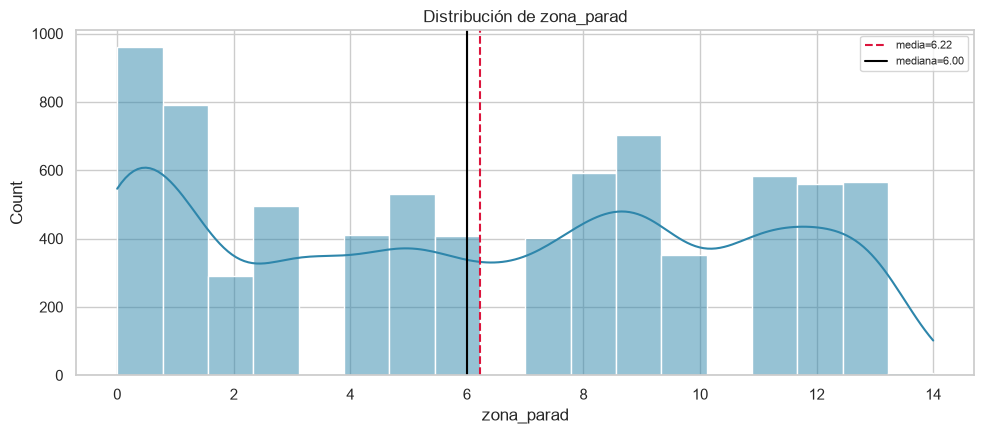

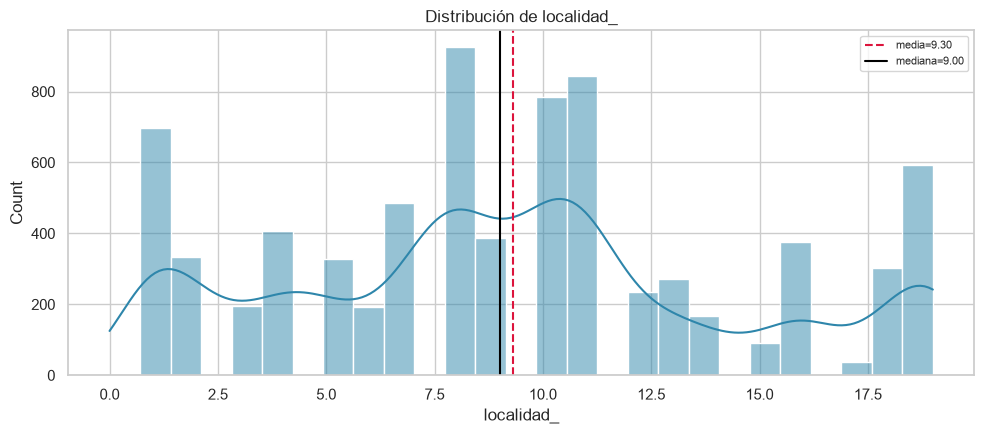

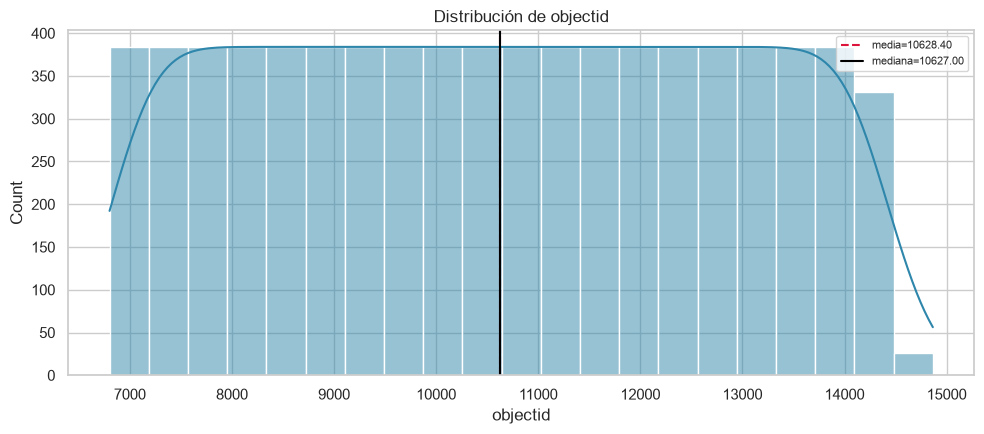

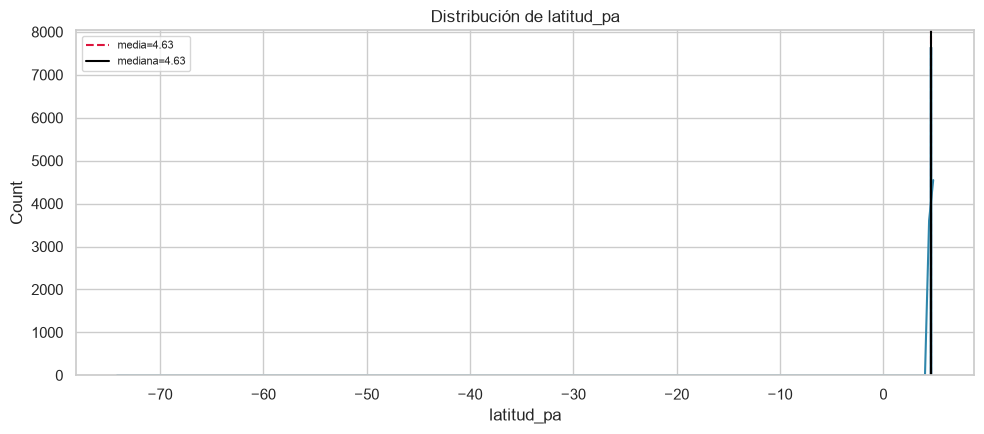

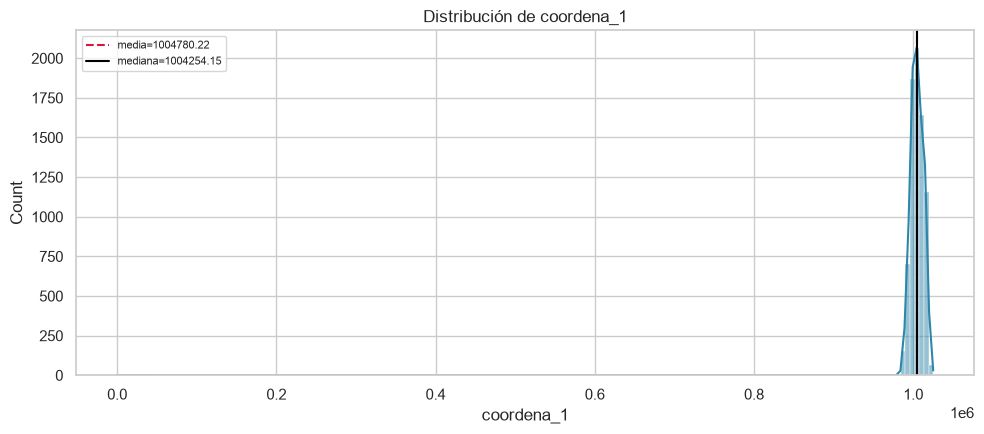

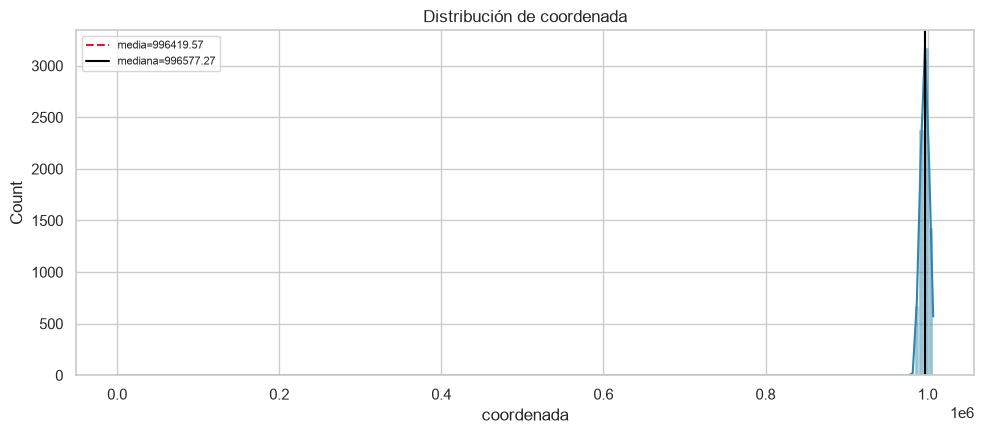

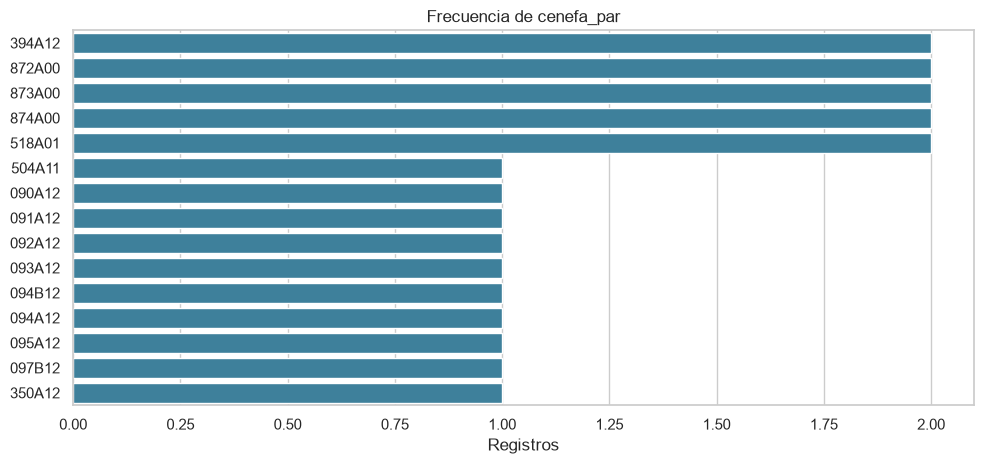

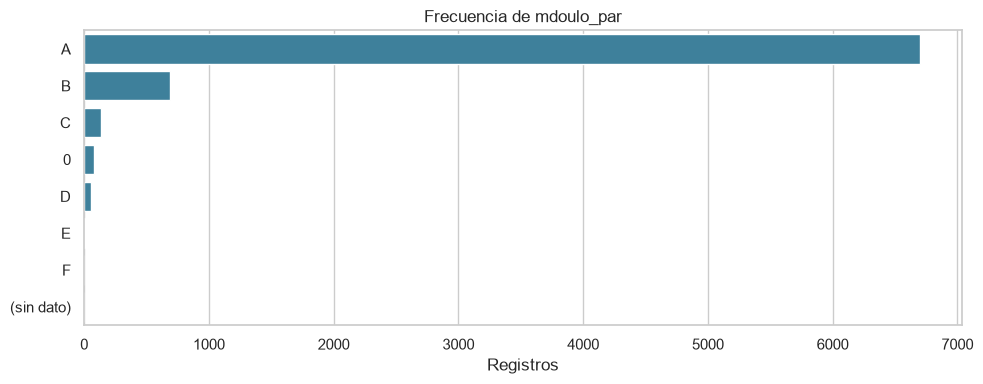

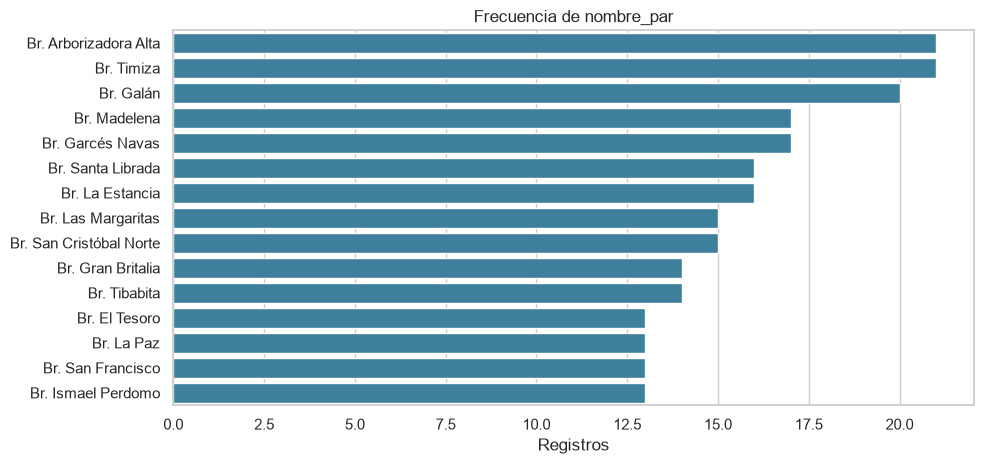

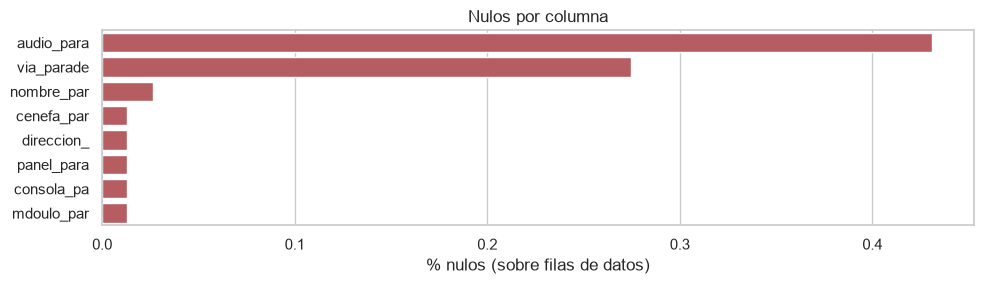

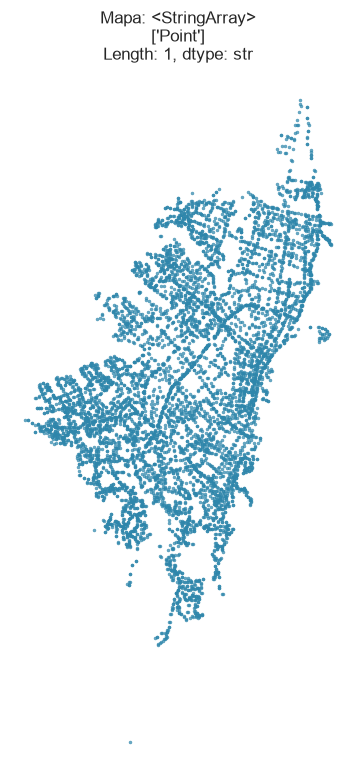

In [3]:
t0('paraderos')
SPEC = {
    'id': 'paraderos_zonales_sitp',
    'titulo': 'Paraderos zonales SITP',
    'path': 'data/raw/MOVILIDAD/paraderos_zonales_sitp.gpkg',
    'capa': 'Paraderos',
    'origen': 'TransMilenio S.A. -- datos abiertos',
    'corte': 'Vigente (corte 2024-2026)',
    'valor_publico': 'Cobertura zonal del SITP: paraderos por localidad y distancia a la red',
    'indicadores': 'MOV-01 (paraderos por localidad)',
    'notas': '7.653 paraderos, EPSG:4686, con columna de localidad (`localidad_`).',
}
RES = explorar_dataset(SPEC, RAW_DIR, PERFILES, smoke=SMOKE)
t1('paraderos')


## 2. Estaciones y trazados

### Estaciones troncales

### Estaciones troncales

,columna,dtype,tipo_variable,n_nulos,pct_nulos,n_unicos,ejemplo_1,ejemplo_2,ejemplo_3
0,objectid,int32,id/llave,0,0.00,153,1,2,3
1,numero_estacion,str,categórica nominal,0,0.00,153,10000,03000,06000
2,nombre_estacion,str,categórica nominal,0,0.00,152,Portal 20 de Julio,Portal Suba,Portal El Dorado - C.C. NUESTRO BOGOTÁ
3,coordenada_x_estacion,float64,categórica ordinal,0,0.00,153,997836.0595,998139.4242,995130.6531
4,coordenada_y_estacion,float64,categórica ordinal,0,0.00,153,996629.2544,1016655.2375,1009444.2454
5,ubicacion_estacion,str,categórica nominal,0,0.00,152,Kra 5 a Cl 33 Sur,Av Suba Av C. Cali,KR 87
6,troncal_estacion,str,categórica nominal,0,0.00,13,Cr 7-10,Suba,Calle 26
7,numero_vagones_estacion,int32,numérica discreta,0,0.00,5,1,3,2
8,numero_accesos_estacion,int32,numérica discreta,0,0.00,3,0,2,1
9,biciestacion_estacion,str,categórica nominal,0,0.00,2,1,0,


,columna,n,n_nulos,pct_nulos,n_unicos,media,mediana,moda,desv_est,min,...,asimetria_skew,curtosis,CV_pct,n_outliers_iqr,pct_outliers,sin_valores_numericos,n_categorias,dominante,pct_dominante,top_5
0,objectid,153,0,0.00,153.0,7.701960e+01,7.700000e+01,1.000000e+00,4.434500e+01,1.000000e+00,...,0.0026,-1.1965,57.5763,0.0,0.00,False,NaN,NaN,NaN,NaN
1,numero_estacion,153,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,153.0,10000,0.65,10000=1 | 03000=1 | 06000=1 | 04000=1 | 05000=1
2,nombre_estacion,153,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,152.0,Temporal AV. Jiménez - Inter Eléctricas,1.31,Temporal AV. Jiménez - Inter Eléctricas=2 | Po...
3,coordenada_x_estacion,153,0,0.00,153.0,9.978501e+05,9.987509e+05,9.857363e+05,4.082733e+03,9.857363e+05,...,-1.1476,1.0033,0.4092,8.0,5.23,False,NaN,NaN,NaN,NaN
4,coordenada_y_estacion,153,0,0.00,153.0,1.004820e+06,1.003703e+06,9.928692e+05,5.795552e+03,9.928692e+05,...,0.4887,-0.5982,0.5768,0.0,0.00,False,NaN,NaN,NaN,NaN
5,ubicacion_estacion,153,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,152.0,KR 4,1.31,KR 4=2 | Kra 5 a Cl 33 Sur=1 | Av Suba Av C. C...
6,troncal_estacion,153,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,13.0,Caracas,18.30,Caracas=28 | NQS=23 | Americas=18 | Autonorte=...
7,numero_vagones_estacion,153,0,0.00,5.0,2.196100e+00,2.000000e+00,2.000000e+00,7.169000e-01,1.000000e+00,...,0.7761,1.5031,32.6441,1.0,0.65,False,NaN,NaN,NaN,NaN
8,numero_accesos_estacion,153,0,0.00,3.0,1.333300e+00,1.000000e+00,1.000000e+00,5.849000e-01,0.000000e+00,...,-0.2221,-0.6431,43.8673,0.0,0.00,False,NaN,NaN,NaN,NaN
9,biciestacion_estacion,153,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0,89.54,0=137 | 1=16


## Interpretación -- Estaciones troncales

**Origen**: TransMilenio S.A. -- datos abiertos  
**Corte temporal**: Vigente  
**Valor público**: Cobertura de la red troncal por localidad (cruce espacial)

**Qué contiene**: 153 filas y 25 columnas; 16.42% de celdas nulas y 0 duplicados.
Capas con geometría (<StringArray>
['Point']
Length: 1, dtype: str) en CRS EPSG:4326.

**Comportamiento de variables numéricas**:
- `objectid`: media 77.0, mediana 77.0, desv 44.3, rango [1, 154], curtosis -1.2 -- variabilidad alta (CV=58%)
- `numero_estacion`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)
- `nombre_estacion`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)
- `coordenada_x_estacion`: media 997,850.1, mediana 998,750.9, desv 4,082.7, rango [985,736, 1,003,765], curtosis +1.0 -- asimetría negativa (-1.15); 8.0 outliers IQR (5%)
- `coordenada_y_estacion`: media 1,004,820.4, mediana 1,003,703.1, desv 5,795.6, rango [992,869, 1,019,088], curtosis -0.6

**Categóricas dominantes**:
- `numero_estacion`: 153.0 categorías; dominante '10000' (1%)
- `nombre_estacion`: 152.0 categorías; dominante 'Temporal AV. Jiménez - Inter Eléctricas' (1%)
- `ubicacion_estacion`: 152.0 categorías; dominante 'KR 4' (1%)
- `troncal_estacion`: 13.0 categorías; dominante 'Caracas' (18%)

**Notas / qué falta**: 153 estaciones, EPSG:4326.

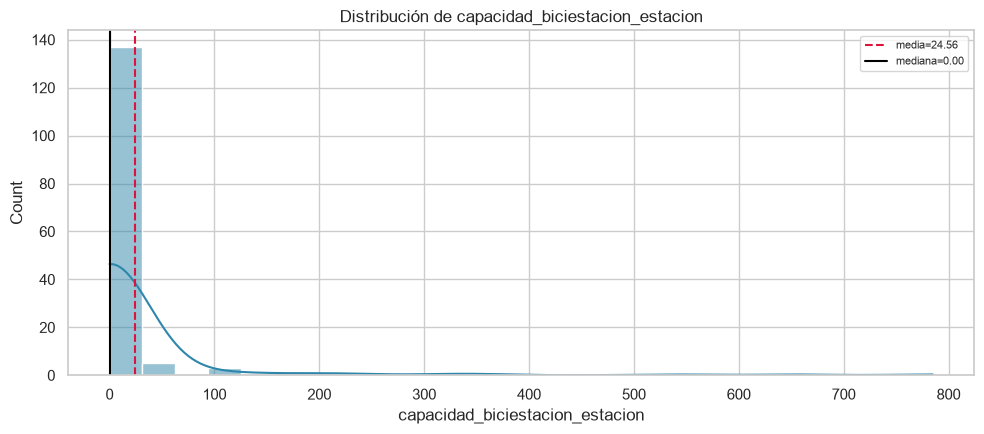

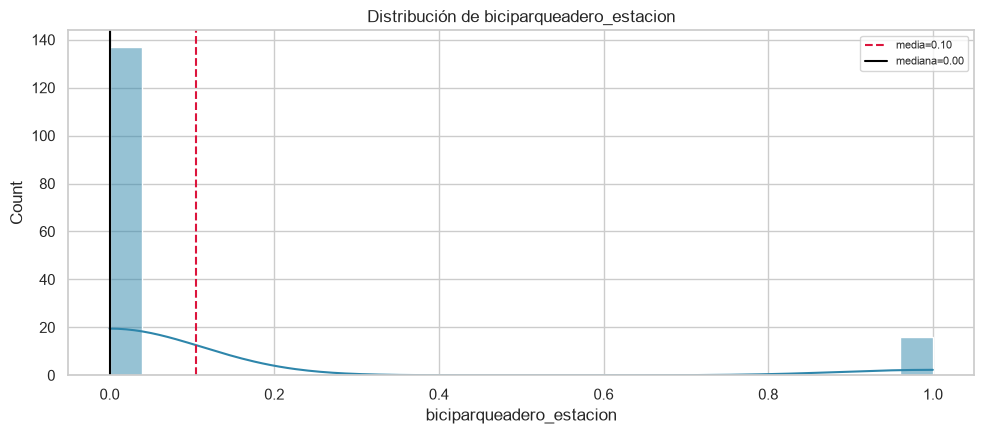

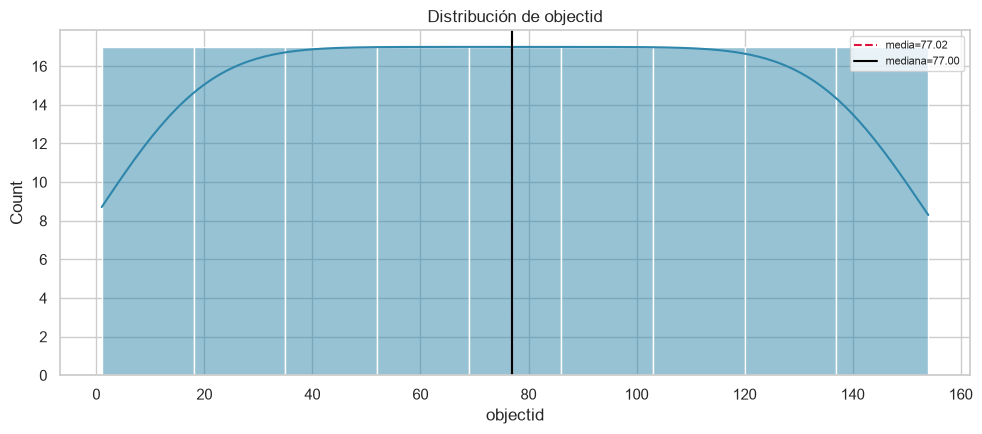

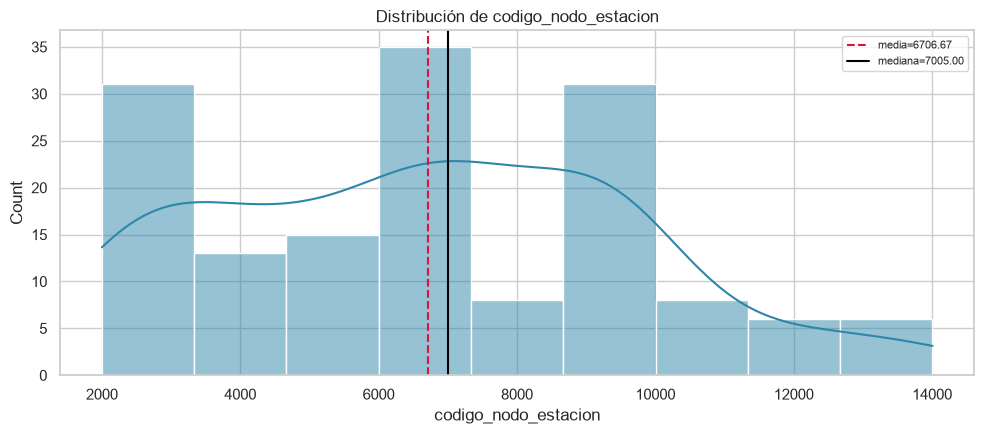

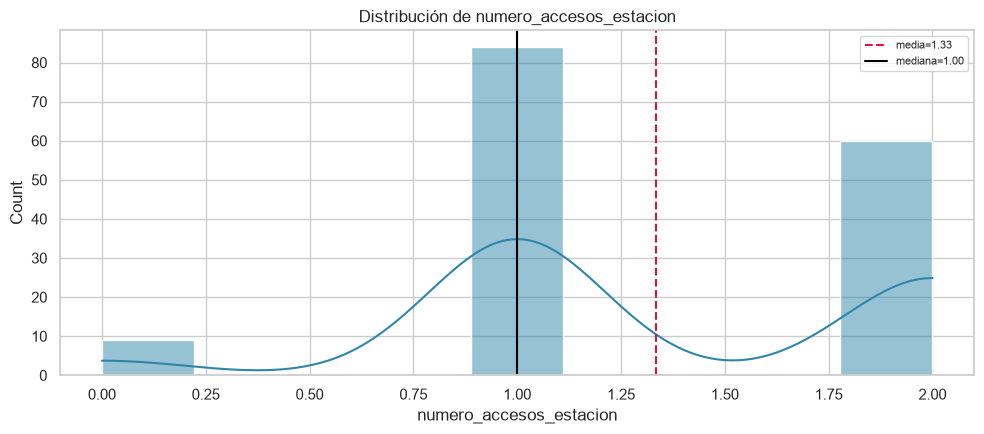

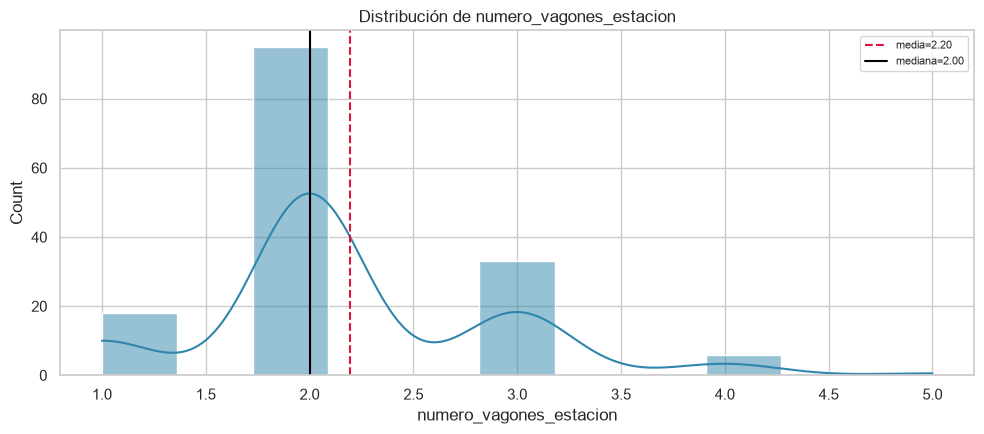

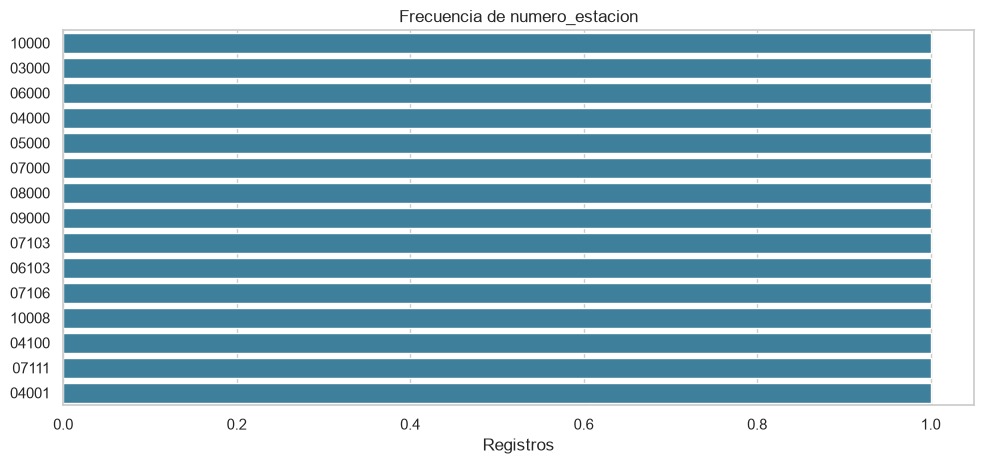

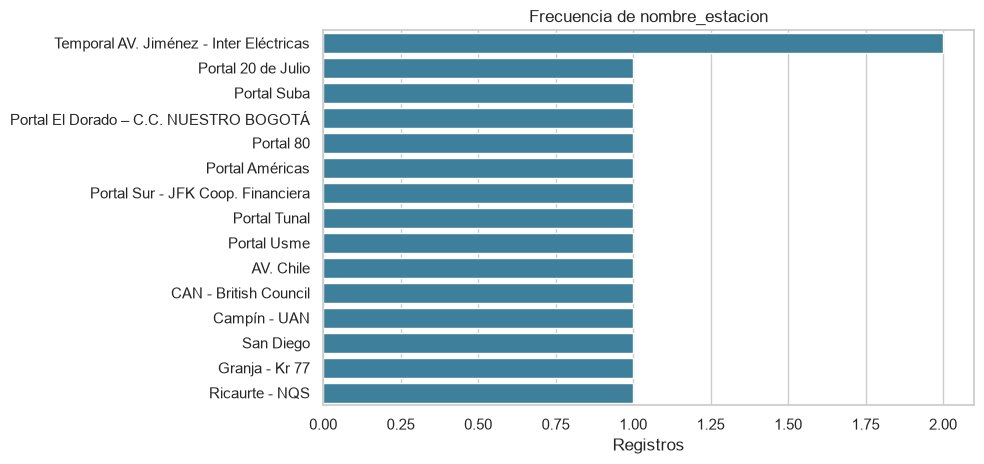

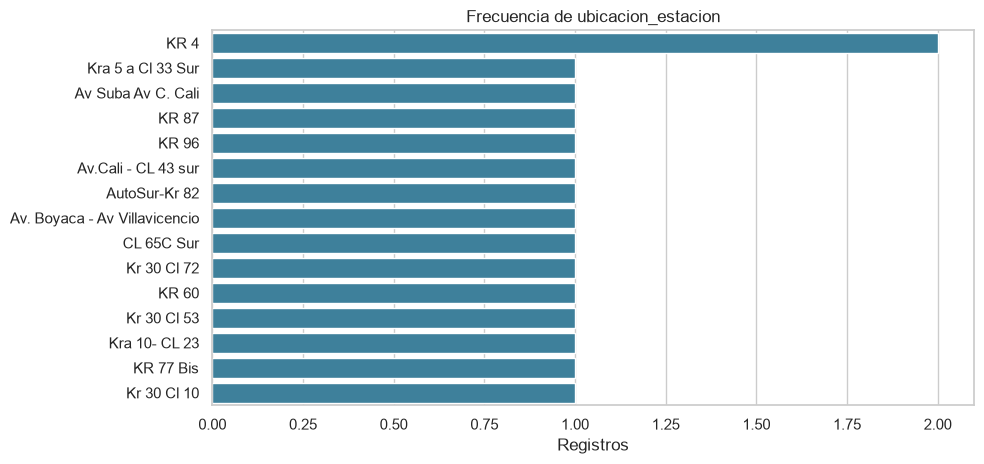

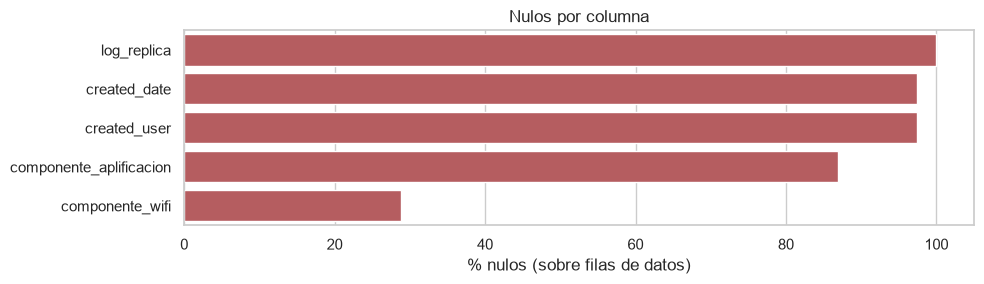

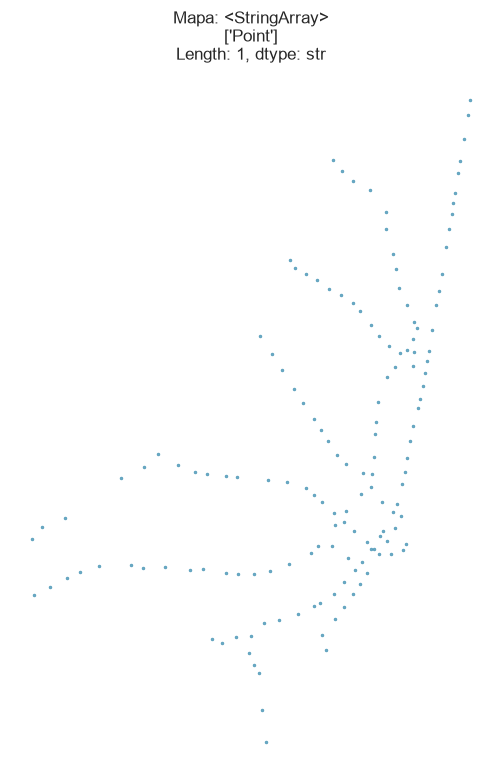

In [4]:
t0('est_troncales')
SPEC = {
    'id': 'estaciones_troncales',
    'titulo': 'Estaciones troncales',
    'path': 'data/raw/MOVILIDAD/estaciones_troncales.geojson',
    'origen': 'TransMilenio S.A. -- datos abiertos',
    'corte': 'Vigente',
    'valor_publico': 'Cobertura de la red troncal por localidad (cruce espacial)',
    'indicadores': 'MOV-02 (estaciones por localidad)',
    'notas': '153 estaciones, EPSG:4326.',
}
RES = explorar_dataset(SPEC, RAW_DIR, PERFILES, smoke=SMOKE)
t1('est_troncales')


### Estaciones Línea 1 (metro)

### Estaciones Línea 1 (metro)

,columna,dtype,tipo_variable,n_nulos,pct_nulos,n_unicos,ejemplo_1,ejemplo_2,ejemplo_3
0,OBJECTID,int32,numérica discreta,0,0.0,16,1,2,3
1,RefName,str,categórica nominal,0,0.0,16,Portal de las Américas-02,Carrera 80-03,Calle 42 Sur-04
2,NUMERO,str,categórica nominal,0,0.0,16,02,03,04
3,NOMBRE,str,categórica nominal,0,0.0,16,E02,E03,E04
4,Shape_Leng,float64,numérica discreta,0,0.0,16,356.200267495,320.399852348,320.399965209
5,Shape_Area,float64,numérica discreta,0,0.0,16,4215.0112394,2203.98914358,2203.99540815
6,TIPO,str,categórica nominal,0,0.0,1,No Definida,,


,columna,n,n_nulos,pct_nulos,n_unicos,media,mediana,moda,desv_est,min,...,asimetria_skew,curtosis,CV_pct,n_outliers_iqr,pct_outliers,sin_valores_numericos,n_categorias,dominante,pct_dominante,top_5
0,OBJECTID,16,0,0.0,16.0,8.5000,8.5000,1.0000,4.7610,1.0000,...,0.0000,-1.2000,56.0112,0.0,0.0,False,NaN,NaN,NaN,NaN
1,RefName,16,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,16.0,Portal de las Américas-02,6.25,Portal de las Américas-02=1 | Carrera 80-03=1 ...
2,NUMERO,16,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,16.0,02,6.25,02=1 | 03=1 | 04=1 | 05=1 | 06=1
3,NOMBRE,16,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,16.0,E02,6.25,E02=1 | E03=1 | E04=1 | E05=1 | E06=1
4,Shape_Leng,16,0,0.0,16.0,334.0874,334.4000,320.3998,11.5275,320.3998,...,0.2809,-0.9702,3.4504,0.0,0.0,False,NaN,NaN,NaN,NaN
5,Shape_Area,16,0,0.0,16.0,2808.0636,2580.0043,2203.9891,601.8685,2203.9891,...,1.0296,0.3365,21.4336,0.0,0.0,False,NaN,NaN,NaN,NaN
6,TIPO,16,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,No Definida,100.00,No Definida=16


No hay valores numéricos para RefName.
No hay valores numéricos para NOMBRE.
Sin columnas con nulos.


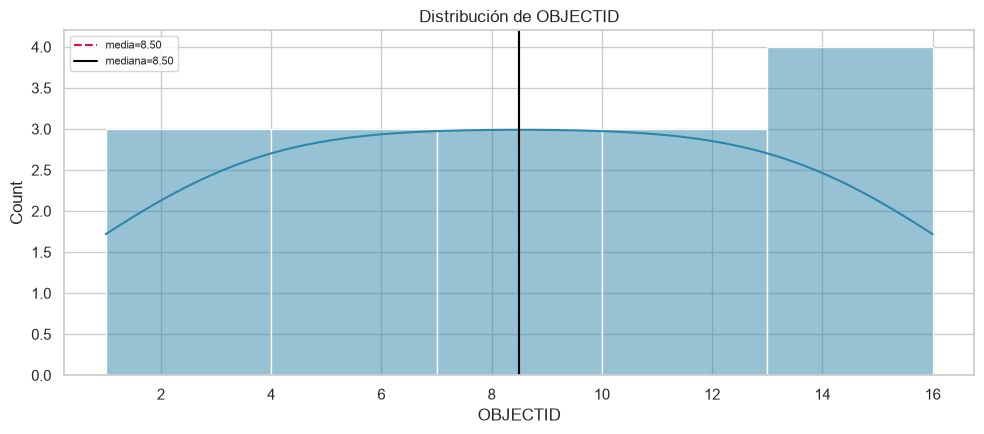

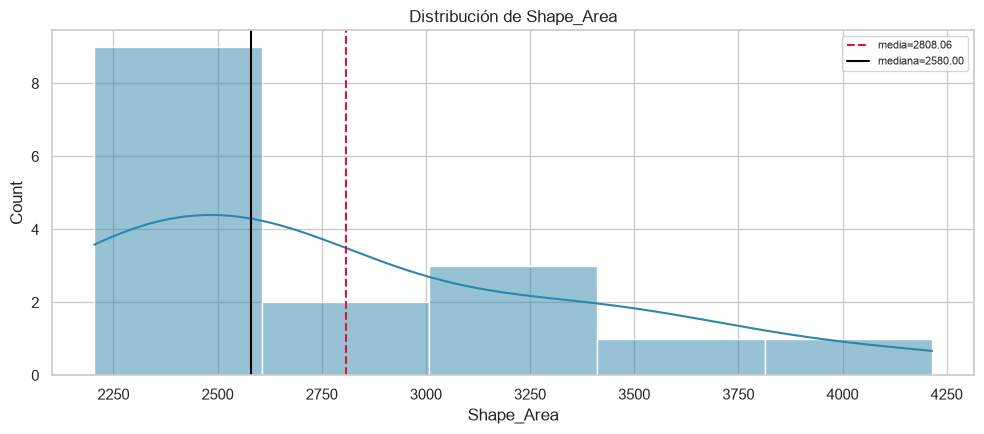

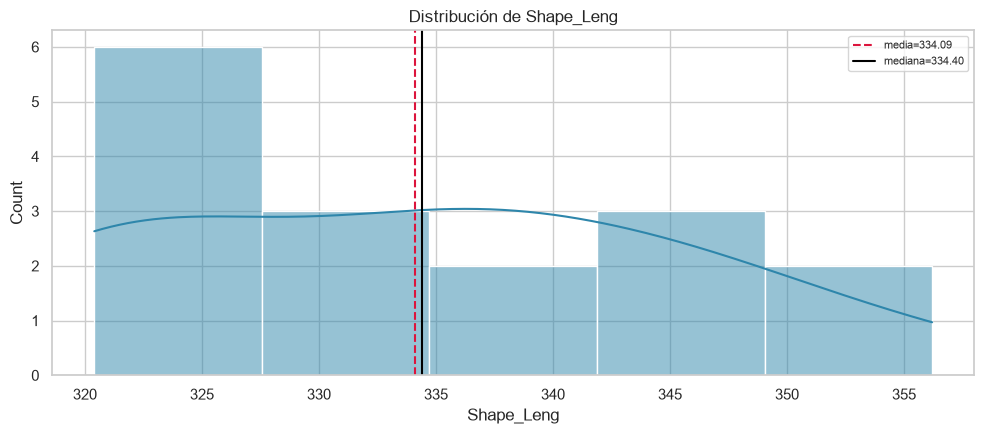

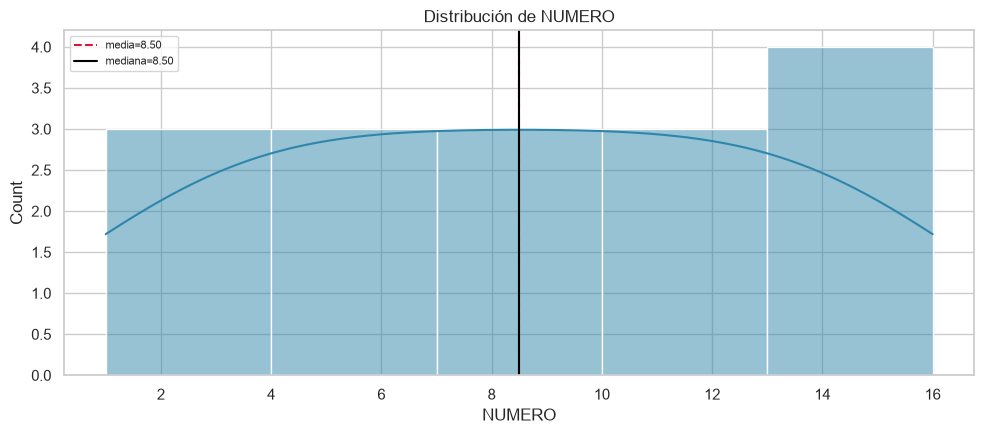

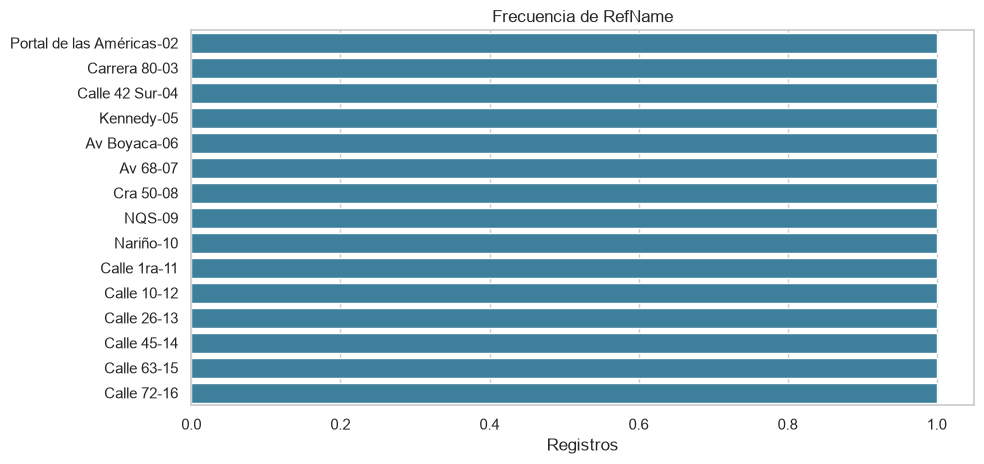

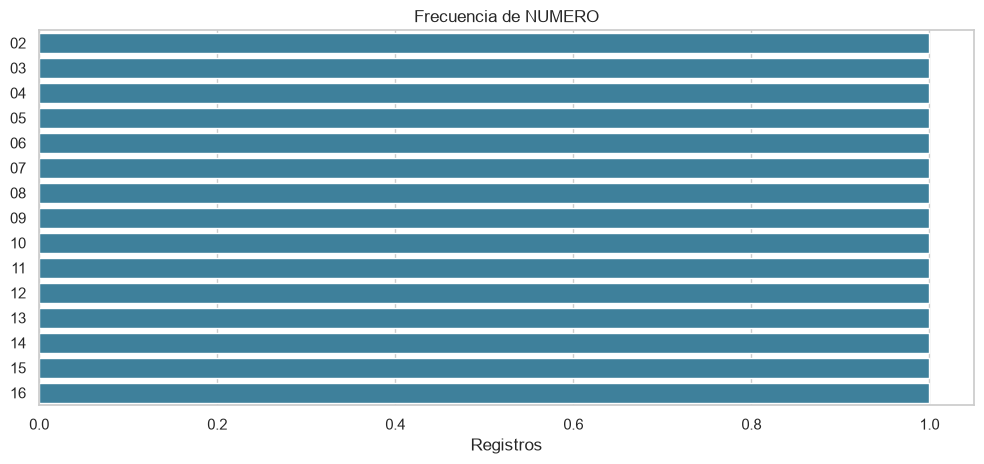

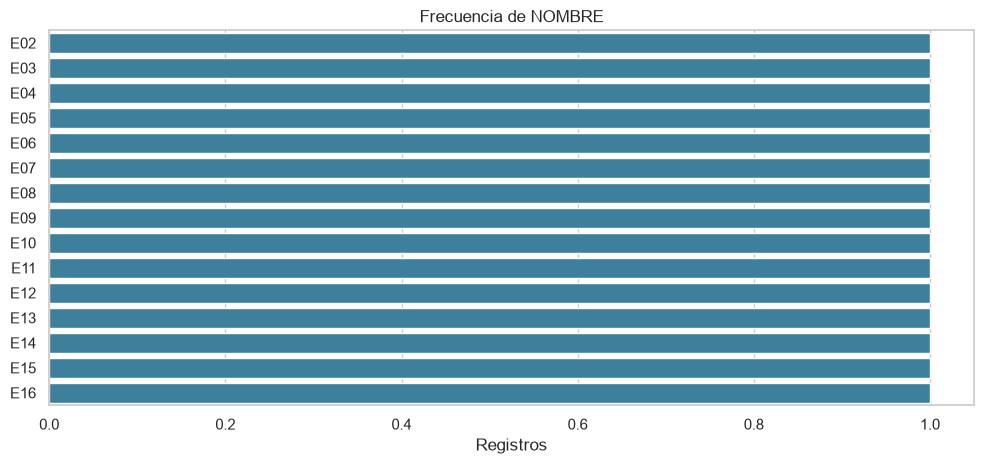

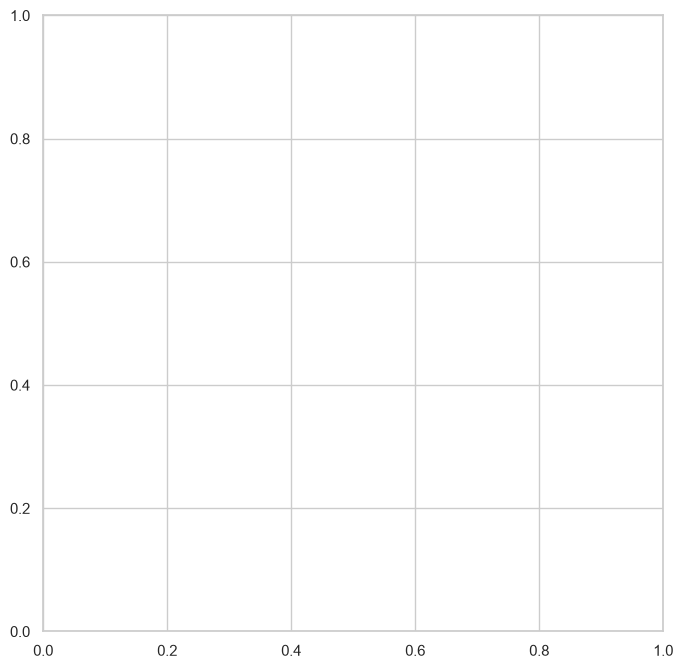

In [5]:
t0('est_l1')
SPEC = {
    'id': 'estaciones_linea1',
    'titulo': 'Estaciones Línea 1 (metro)',
    'path': 'data/raw/MOVILIDAD/estaciones_linea1.geojson',
    'origen': 'Metro de Bogotá -- datos abiertos',
    'corte': 'Vigente (proyecto)',
    'valor_publico': 'Localización del proyecto PLMB por localidad',
    'indicadores': 'MOV-02 (estaciones por localidad)',
    'notas': 'GeoJSON con elevación (EPSG:4979).',
}
RES = explorar_dataset(SPEC, RAW_DIR, PERFILES, smoke=SMOKE)
t1('est_l1')


### Estaciones Línea 2 (metro)

### Estaciones Línea 2 (metro)

,columna,dtype,tipo_variable,n_nulos,pct_nulos,n_unicos,ejemplo_1,ejemplo_2,ejemplo_3
0,OBJECTID,int64,numérica discreta,0,0.0,11,1,2,3
1,NUMERO,str,categórica nominal,0,0.0,11,01,02,03
2,NOMBRE,str,categórica nominal,0,0.0,11,ESTACIÓN 1,ESTACIÓN 2,ESTACIÓN 3
3,TIPO,str,categórica nominal,0,0.0,1,No Definida,,
4,SHAPE_Length,float64,numérica discreta,0,0.0,11,0.0033959534763895642,0.003394737577836677,0.003395395631434296
5,SHAPE_Area,float64,numérica discreta,0,0.0,11,3.64849473685189e-07,3.648535123388944e-07,3.648593962950347e-07


,columna,n,n_nulos,pct_nulos,n_unicos,media,mediana,moda,desv_est,min,...,asimetria_skew,curtosis,CV_pct,n_outliers_iqr,pct_outliers,sin_valores_numericos,n_categorias,dominante,pct_dominante,top_5
0,OBJECTID,11,0,0.0,11.0,6.0000,6.0000,1.0000,3.3166,1.0000,...,0.0000,-1.2000,55.2771,0.0,0.00,False,NaN,NaN,NaN,NaN
1,NUMERO,11,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,11.0,01,9.09,01=1 | 02=1 | 03=1 | 04=1 | 05=1
2,NOMBRE,11,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,11.0,ESTACIÓN 1,9.09,ESTACIÓN 1=1 | ESTACIÓN 2=1 | ESTACIÓN 3=1 | E...
3,TIPO,11,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,No Definida,100.00,No Definida=11
4,SHAPE_Length,11,0,0.0,11.0,0.0034,0.0034,0.0034,0.0000,0.0034,...,-1.1902,4.6796,0.1726,2.0,18.18,False,NaN,NaN,NaN,NaN
5,SHAPE_Area,11,0,0.0,11.0,0.0000,0.0000,0.0000,0.0000,0.0000,...,-1.8223,6.6496,1.2766,2.0,18.18,False,NaN,NaN,NaN,NaN


No hay valores numéricos para NOMBRE.
No hay valores numéricos para TIPO.
Sin columnas con nulos.


## Interpretación -- Estaciones Línea 2 (metro)

**Origen**: Metro de Bogotá -- datos abiertos  
**Corte temporal**: Vigente (proyecto)  
**Valor público**: Localización del proyecto L2 por localidad

**Qué contiene**: 11 filas y 6 columnas; 0.0% de celdas nulas y 0 duplicados.
Capas con geometría (<StringArray>
['MultiPolygon']
Length: 1, dtype: str) en CRS EPSG:4686.

**Comportamiento de variables numéricas**:
- `OBJECTID`: media 6.0, mediana 6.0, desv 3.3, rango [1, 11], curtosis -1.2 -- variabilidad alta (CV=55%)
- `NUMERO`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)
- `NOMBRE`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)
- `TIPO`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)
- `SHAPE_Length`: media 0.0, mediana 0.0, desv 0.0, rango [0, 0], curtosis +4.7 -- asimetría negativa (-1.19); 2.0 outliers IQR (18%)

**Categóricas dominantes**:
- `NUMERO`: 11.0 categorías; dominante '01' (9%)
- `NOMBRE`: 11.0 categorías; dominante 'ESTACIÓN 1' (9%)
- `TIPO`: 1.0 categorías; dominante 'No Definida' (100%)

**Notas / qué falta**: 11 estaciones, EPSG:4686.

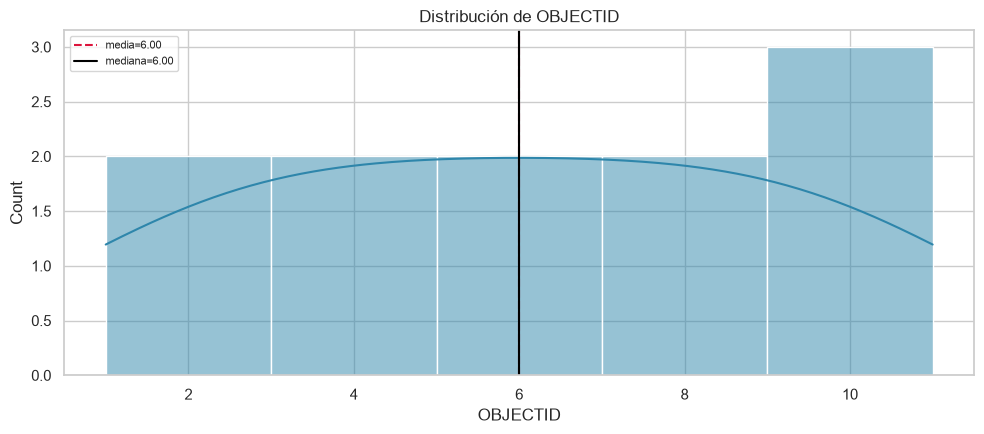

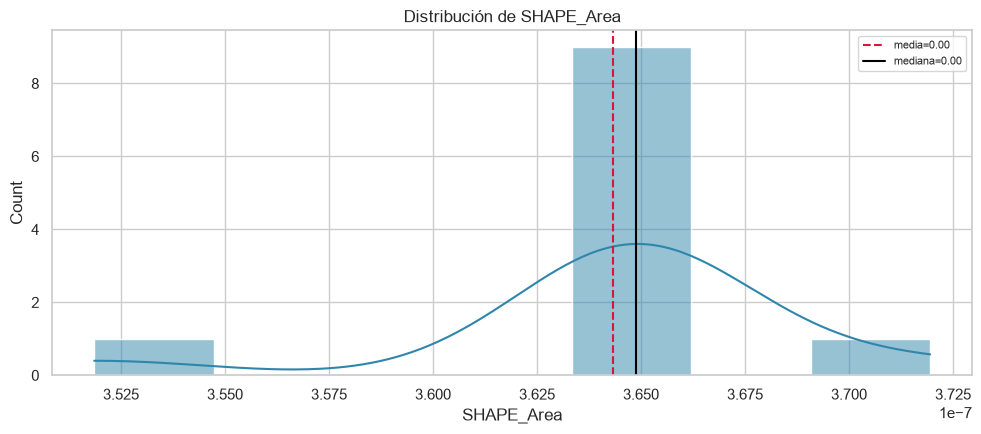

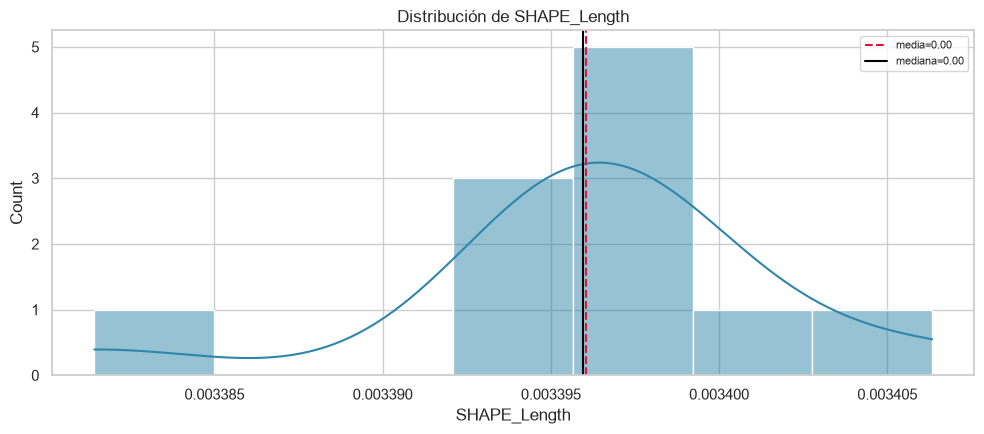

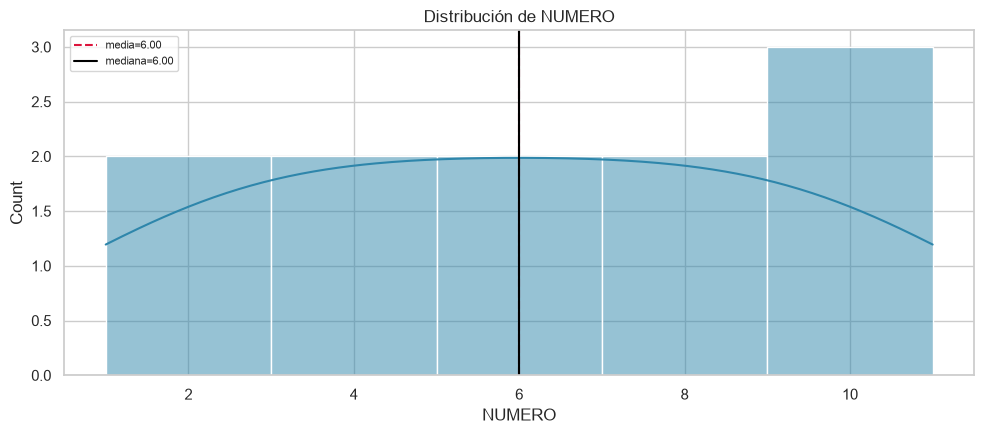

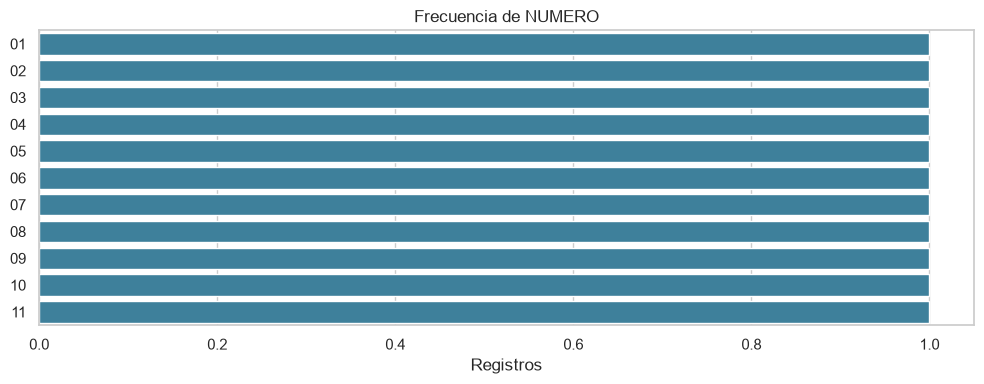

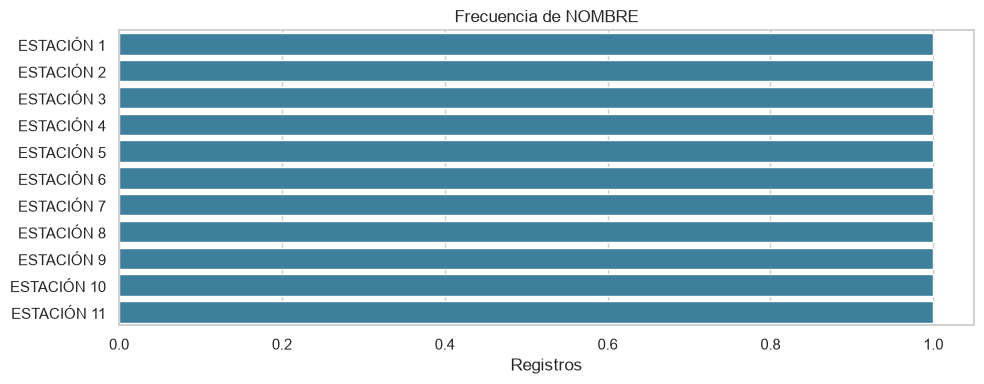

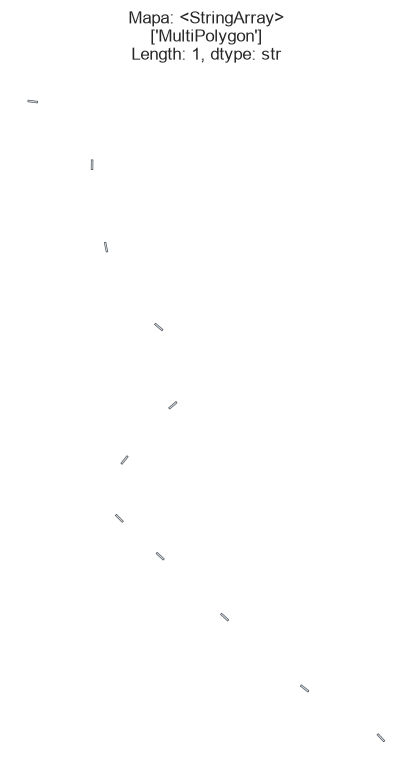

In [6]:
t0('est_l2')
SPEC = {
    'id': 'estaciones_linea2',
    'titulo': 'Estaciones Línea 2 (metro)',
    'path': 'data/raw/MOVILIDAD/estaciones_linea2.gpkg',
    'capa': 'estacionessegundalinea',
    'origen': 'Metro de Bogotá -- datos abiertos',
    'corte': 'Vigente (proyecto)',
    'valor_publico': 'Localización del proyecto L2 por localidad',
    'indicadores': 'MOV-02 (estaciones por localidad)',
    'notas': '11 estaciones, EPSG:4686.',
}
RES = explorar_dataset(SPEC, RAW_DIR, PERFILES, smoke=SMOKE)
t1('est_l2')


## 3. Conexiones, retornos y trazados

### Conexiones operacionales

### Conexiones operacionales

,columna,dtype,tipo_variable,n_nulos,pct_nulos,n_unicos,ejemplo_1,ejemplo_2,ejemplo_3
0,latitud,float64,espacial,0,0.0,13,4.60216644,4.6036552,4.56909667
1,longitud,float64,espacial,0,0.0,13,-74.0766654,-74.07986393,-74.12550392
2,objectid,int32,numérica discreta,0,0.0,13,1,2,3
3,id_conexio,str,categórica nominal,0,0.0,13,CN001,CN002,CN003
4,conexion,str,categórica nominal,0,0.0,13,Carrera 10 - Eje Ambiental,Caracas Centro - Americas,Tunal - Caracas Sur
5,esta_oper,int32,numérica discreta,0,0.0,1,1,,
6,tip_conex,int32,numérica discreta,0,0.0,4,1,2,4
7,eta_oper,int32,numérica discreta,0,0.0,1,1,,
8,globalid,str,categórica nominal,0,0.0,13,{2357067B-5E7D-452A-B5C6-1BDAE137FD93},{DEBE4BF8-6EAA-4E5F-B6A8-C3E57085363A},{61C06661-2820-4F73-B965-EF9744267869}
9,created_user,object,categórica nominal,13,100.0,0,,,


,columna,n,n_nulos,pct_nulos,n_unicos,media,mediana,moda,desv_est,min,...,asimetria_skew,curtosis,CV_pct,n_outliers_iqr,pct_outliers,sin_valores_numericos,n_categorias,dominante,pct_dominante,top_5
0,latitud,13,0,0.0,13.0,4.6204,4.6121,4.5691,0.0334,4.5691,...,0.7382,-0.2545,0.7219,1.0,7.69,False,NaN,NaN,NaN,NaN
1,longitud,13,0,0.0,13.0,-74.0807,-74.0798,-74.1255,0.0175,-74.1255,...,-1.3721,2.8322,-0.0236,1.0,7.69,False,NaN,NaN,NaN,NaN
2,objectid,13,0,0.0,13.0,7.0000,7.0000,1.0000,3.8944,1.0000,...,0.0000,-1.2000,55.6349,0.0,0.00,False,NaN,NaN,NaN,NaN
3,id_conexio,13,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,13.0,CN001,7.69,CN001=1 | CN002=1 | CN003=1 | CN004=1 | CN005=1
4,conexion,13,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,13.0,Carrera 10 - Eje Ambiental,7.69,Carrera 10 - Eje Ambiental=1 | Caracas Centro ...
5,esta_oper,13,0,0.0,1.0,1.0000,1.0000,1.0000,0.0000,1.0000,...,0.0000,0.0000,0.0000,0.0,0.00,False,NaN,NaN,NaN,NaN
6,tip_conex,13,0,0.0,4.0,1.8462,1.0000,1.0000,1.1435,1.0000,...,1.1387,-0.0245,61.9420,2.0,15.38,False,NaN,NaN,NaN,NaN
7,eta_oper,13,0,0.0,1.0,1.0000,1.0000,1.0000,0.0000,1.0000,...,0.0000,0.0000,0.0000,0.0,0.00,False,NaN,NaN,NaN,NaN
8,globalid,13,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,13.0,{2357067B-5E7D-452A-B5C6-1BDAE137FD93},7.69,{2357067B-5E7D-452A-B5C6-1BDAE137FD93}=1 | {DE...
9,created_user,0,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,(nulo),100.00,(nulo)=13


No hay valores numéricos para id_conexio.
No hay valores numéricos para conexion.


## Interpretación -- Conexiones operacionales

**Origen**: TransMilenio S.A.  
**Corte temporal**: Vigente  
**Valor público**: Puntos de integración de la red

**Qué contiene**: 13 filas y 13 columnas; 30.77% de celdas nulas y 0 duplicados.
Capas con geometría (<StringArray>
['Point']
Length: 1, dtype: str) en CRS EPSG:4326.

**Comportamiento de variables numéricas**:
- `latitud`: media 4.6, mediana 4.6, desv 0.0, rango [5, 5], curtosis -0.3 -- 1.0 outliers IQR (8%)
- `longitud`: media -74.1, mediana -74.1, desv 0.0, rango [-74, -74], curtosis +2.8 -- asimetría negativa (-1.37); 1.0 outliers IQR (8%)
- `objectid`: media 7.0, mediana 7.0, desv 3.9, rango [1, 13], curtosis -1.2 -- variabilidad alta (CV=56%)
- `id_conexio`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)
- `conexion`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)

**Categóricas dominantes**:
- `id_conexio`: 13.0 categorías; dominante 'CN001' (8%)
- `conexion`: 13.0 categorías; dominante 'Carrera 10 - Eje Ambiental' (8%)
- `globalid`: 13.0 categorías; dominante '{2357067B-5E7D-452A-B5C6-1BDAE137FD93}' (8%)
- `created_user`: 1.0 categorías; dominante '(nulo)' (100%)

**Notas / qué falta**: 13 conexiones.

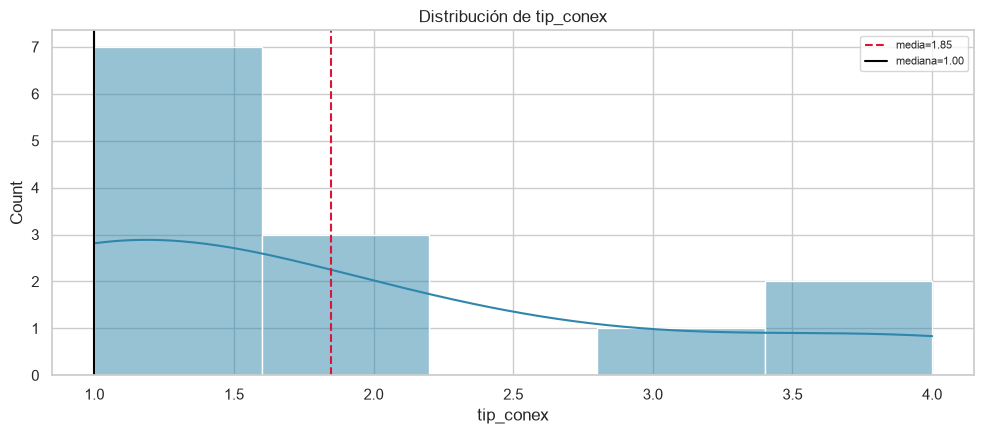

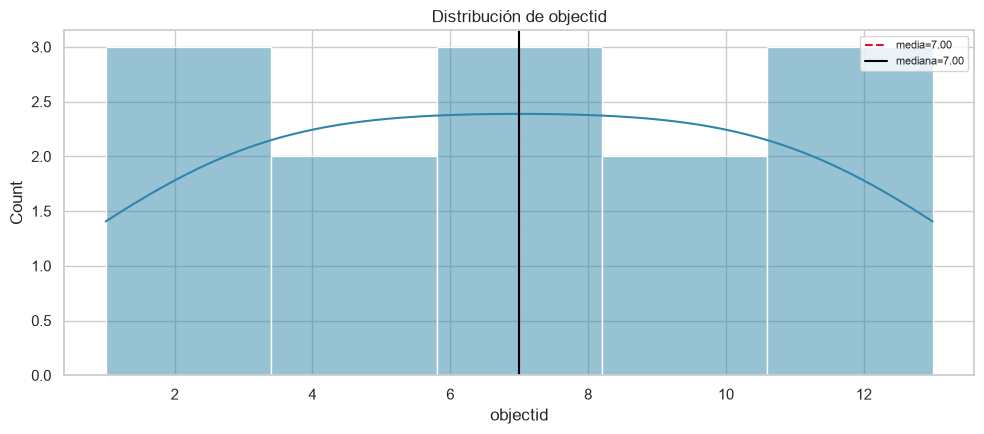

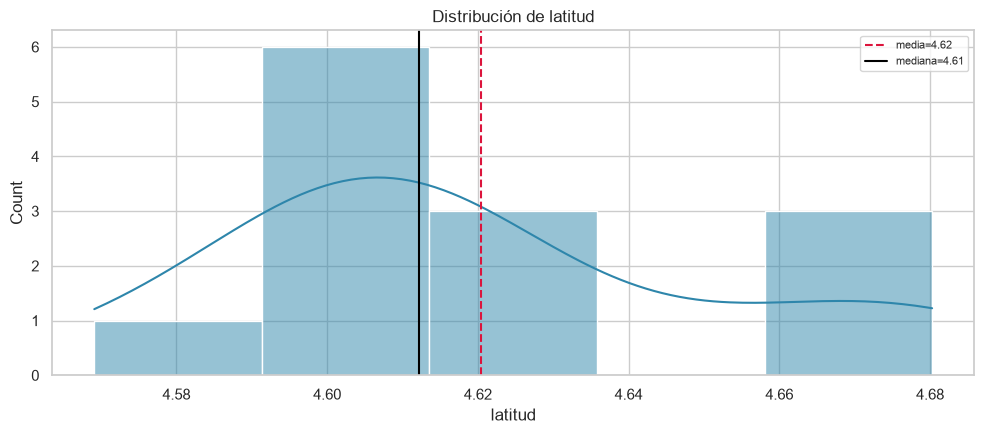

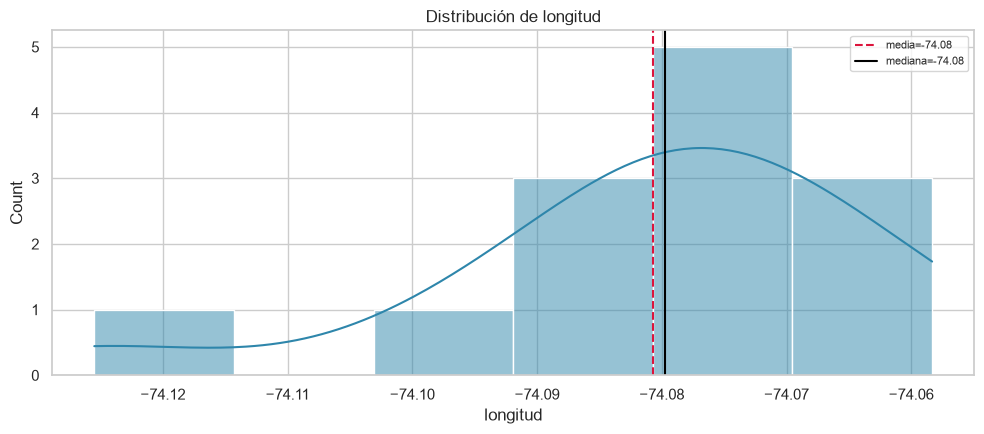

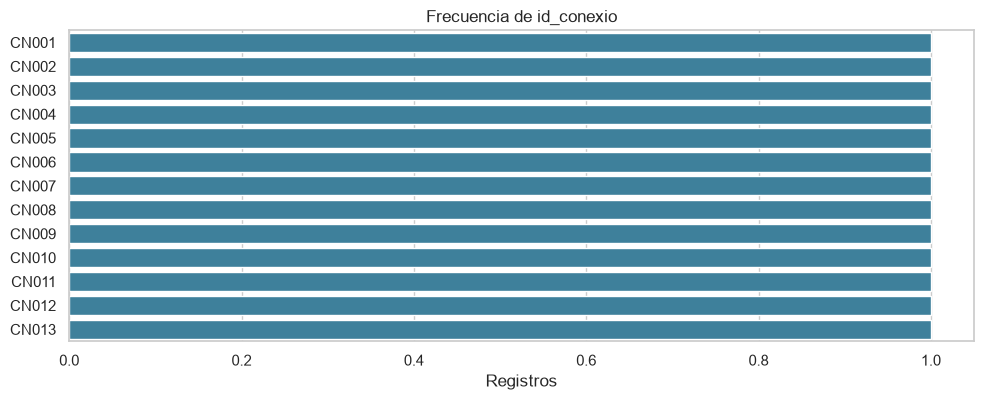

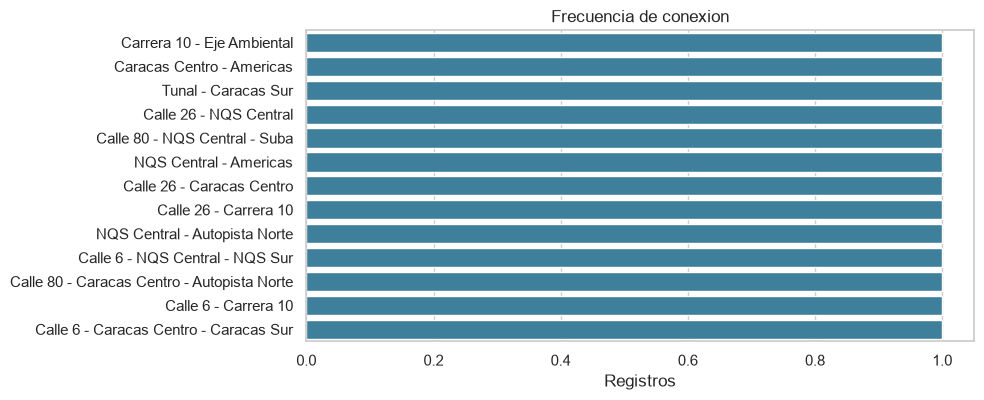

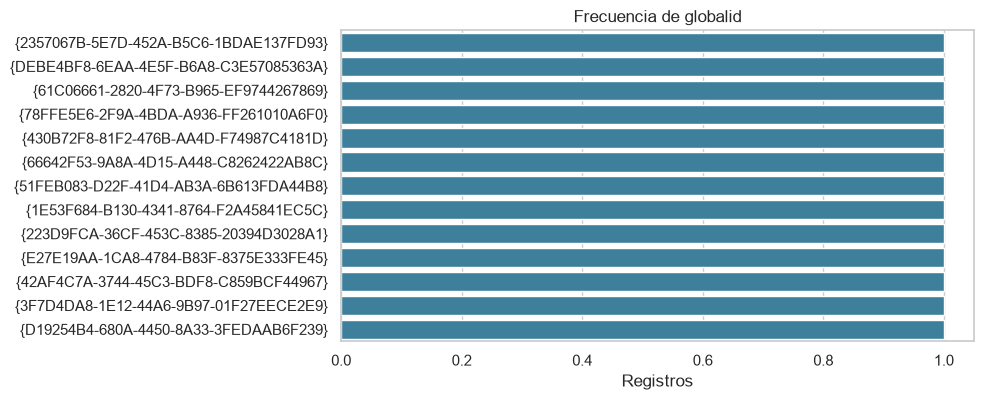

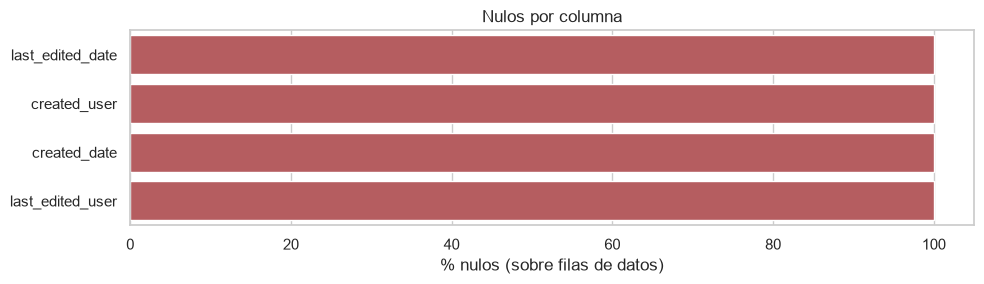

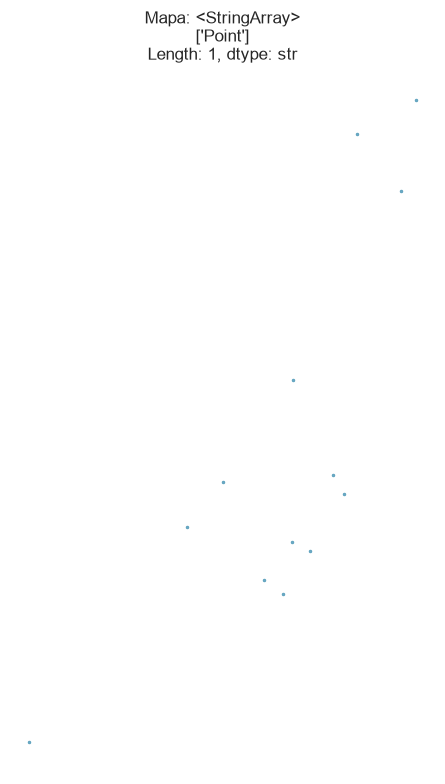

In [7]:
t0('conexiones')
SPEC = {
    'id': 'conexion_operacional',
    'titulo': 'Conexiones operacionales',
    'path': 'data/raw/MOVILIDAD/conexion_operacional.geojson',
    'origen': 'TransMilenio S.A.',
    'corte': 'Vigente',
    'valor_publico': 'Puntos de integración de la red',
    'indicadores': 'MOV-04 (integración modal)',
    'notas': '13 conexiones.',
}
RES = explorar_dataset(SPEC, RAW_DIR, PERFILES, smoke=SMOKE)
t1('conexiones')


### Retornos operacionales

### Retornos operacionales

,columna,dtype,tipo_variable,n_nulos,pct_nulos,n_unicos,ejemplo_1,ejemplo_2,ejemplo_3
0,ub_ret,str,categórica nominal,0,0.0,33,Costado Occidental,Costado Oriental,Costado Sur - Oriental
1,longitud,float64,espacial,0,0.0,47,-74.20092974,-74.10793933000001,-74.06256217
2,latitud,float64,espacial,0,0.0,47,4.58824877,4.66062084,4.65571241
3,objectid,int32,id/llave,0,0.0,47,196,197,198
4,id_retorno,str,id/llave,0,0.0,47,RT042,RT016,RT026
5,nombre,str,categórica nominal,0,0.0,47,Terreros,Avenida Rojas,Flores
6,observ,str,categórica nominal,0,0.0,4,Sin observacion,Mixto giro a la izquierda,Retorno semaforico
7,id_trazado,str,categórica nominal,0,0.0,17,TZ011,TZ016,TZ001
8,esta_oper,int32,numérica discreta,0,0.0,1,1,,
9,tip_ret,int32,numérica discreta,0,0.0,4,2,1,3


,columna,n,n_nulos,n_categorias,dominante,pct_dominante,top_5,pct_nulos,n_unicos,media,...,rango,Q1,Q3,IQR,asimetria_skew,curtosis,CV_pct,n_outliers_iqr,pct_outliers,sin_valores_numericos
0,ub_ret,47,0,33.0,Costado Occidental,19.15,Costado Occidental=9 | Costado Oriental=4 | Co...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,longitud,47,0,NaN,NaN,NaN,NaN,0.0,47.0,-74.0939,...,0.1636,-74.1185,-74.0685,0.0500,-1.0900,1.0592,-0.0521,2.0,4.26,False
2,latitud,47,0,NaN,NaN,NaN,NaN,0.0,47.0,4.6475,...,0.2010,4.6025,4.6804,0.0779,0.7811,-0.5090,1.2083,0.0,0.00,False
3,objectid,47,0,NaN,NaN,NaN,NaN,0.0,47.0,219.7660,...,64.0000,207.5000,230.5000,23.0000,0.5304,0.0809,7.0007,0.0,0.00,False
4,id_retorno,47,0,47.0,RT042,2.13,RT042=1 | RT016=1 | RT026=1 | RT008=1 | RT014=1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,nombre,47,0,47.0,Terreros,2.13,Terreros=1 | Avenida Rojas=1 | Flores=1 | Puen...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,observ,47,0,4.0,Sin observacion,93.62,Sin observacion=44 | Mixto giro a la izquierda...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,id_trazado,47,0,17.0,TZ016,14.89,TZ016=7 | TZ002=7 | TZ009=6 | TZ008=4 | TZ005=3,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,esta_oper,47,0,NaN,NaN,NaN,NaN,0.0,1.0,1.0000,...,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.00,False
9,tip_ret,47,0,NaN,NaN,NaN,NaN,0.0,4.0,1.6809,...,3.0000,1.0000,2.0000,1.0000,1.4129,1.3634,54.2246,4.0,8.51,False


## Interpretación -- Retornos operacionales

**Origen**: TransMilenio S.A.  
**Corte temporal**: Vigente  
**Valor público**: Operación de giro de la red troncal

**Qué contiene**: 47 filas y 18 columnas; 22.22% de celdas nulas y 0 duplicados.
Capas con geometría (<StringArray>
['Point']
Length: 1, dtype: str) en CRS EPSG:4326.

**Comportamiento de variables numéricas**:
- `ub_ret`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)
- `longitud`: media -74.1, mediana -74.1, desv 0.0, rango [-74, -74], curtosis +1.1 -- asimetría negativa (-1.09); 2.0 outliers IQR (4%)
- `latitud`: media 4.6, mediana 4.6, desv 0.1, rango [5, 5], curtosis -0.5
- `objectid`: media 219.8, mediana 219.0, desv 15.4, rango [196, 260], curtosis +0.1
- `id_retorno`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)

**Categóricas dominantes**:
- `ub_ret`: 33.0 categorías; dominante 'Costado Occidental' (19%)
- `id_retorno`: 47.0 categorías; dominante 'RT042' (2%)
- `nombre`: 47.0 categorías; dominante 'Terreros' (2%)
- `observ`: 4.0 categorías; dominante 'Sin observacion' (94%)

**Notas / qué falta**: Puntos de retorno.

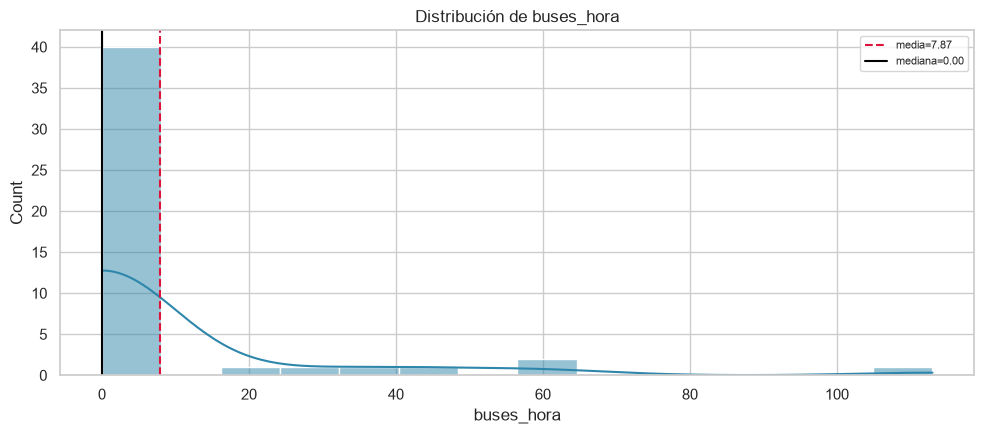

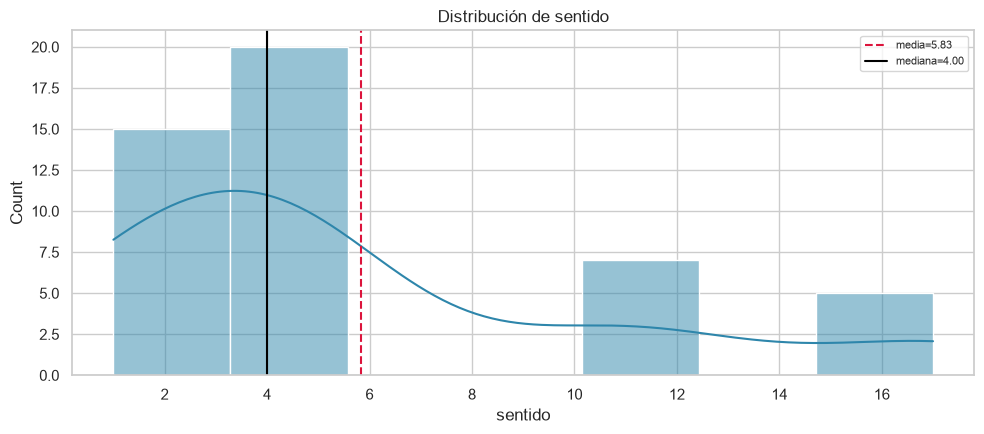

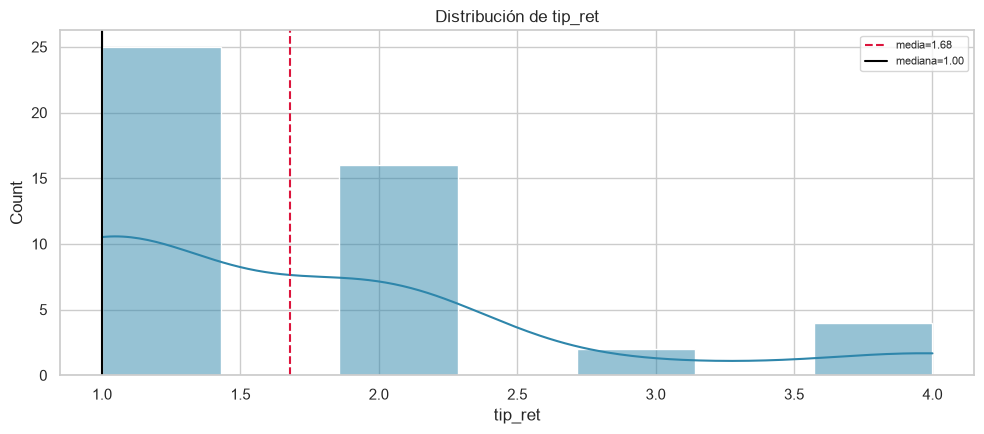

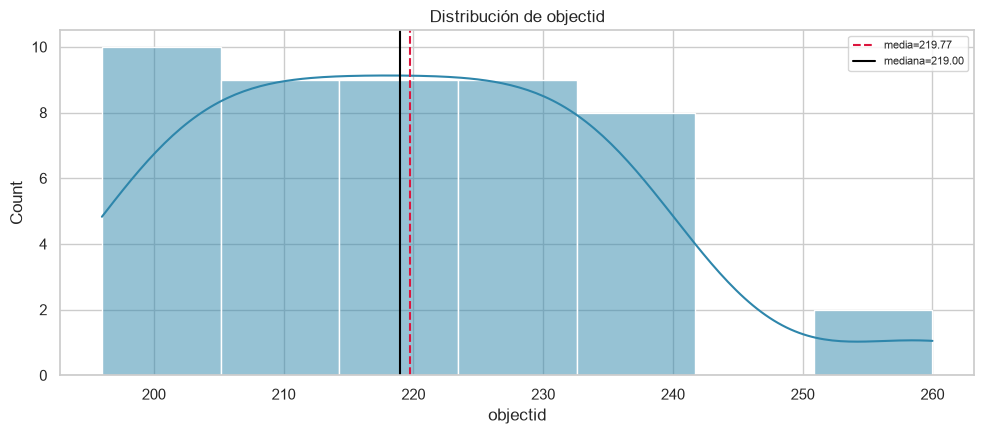

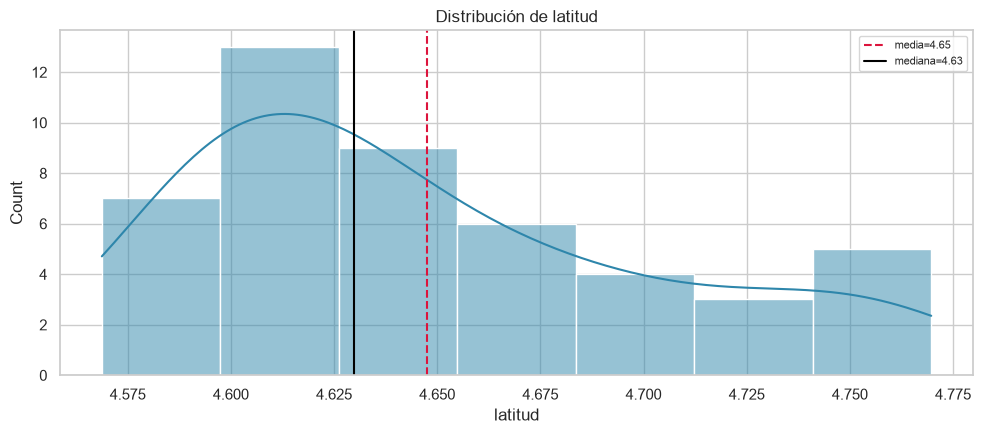

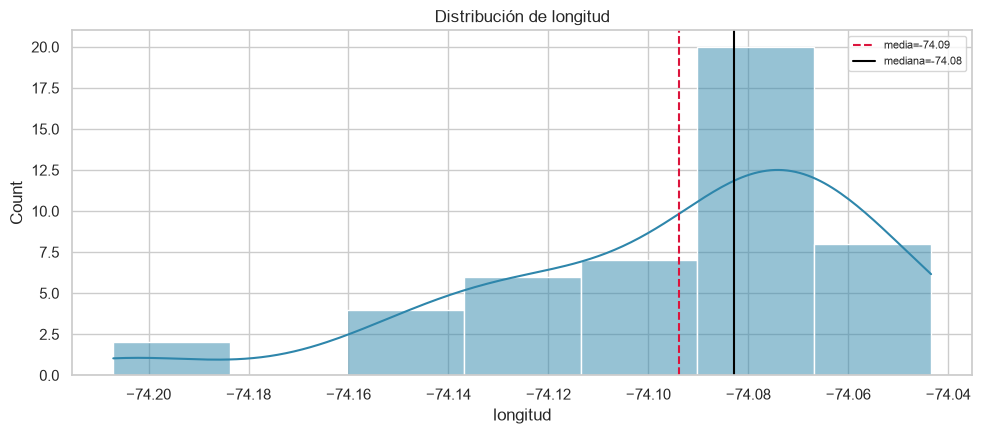

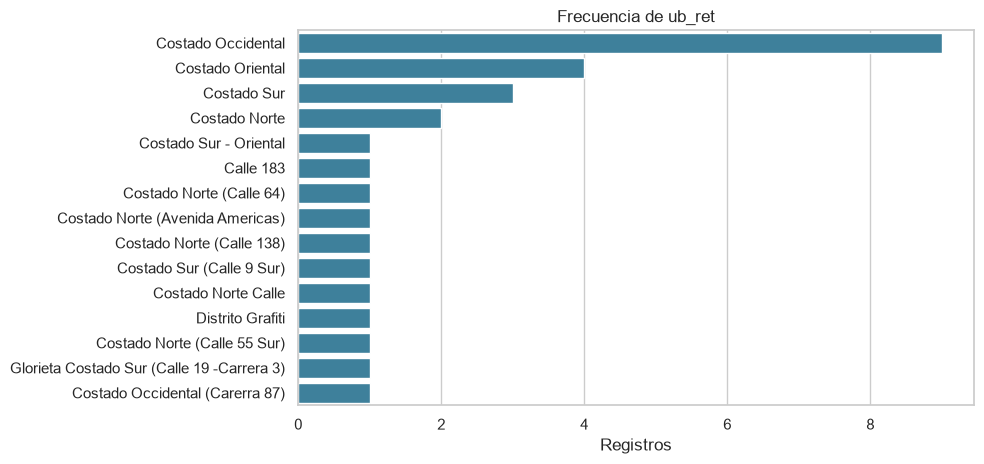

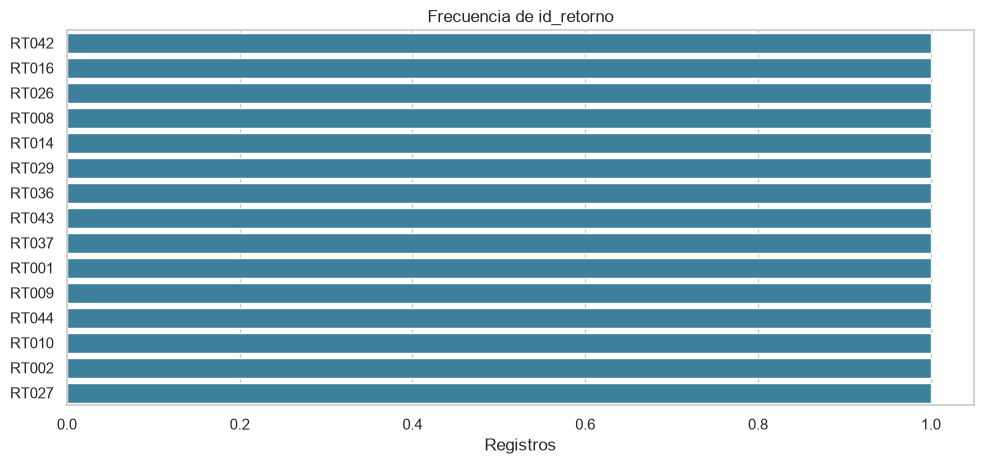

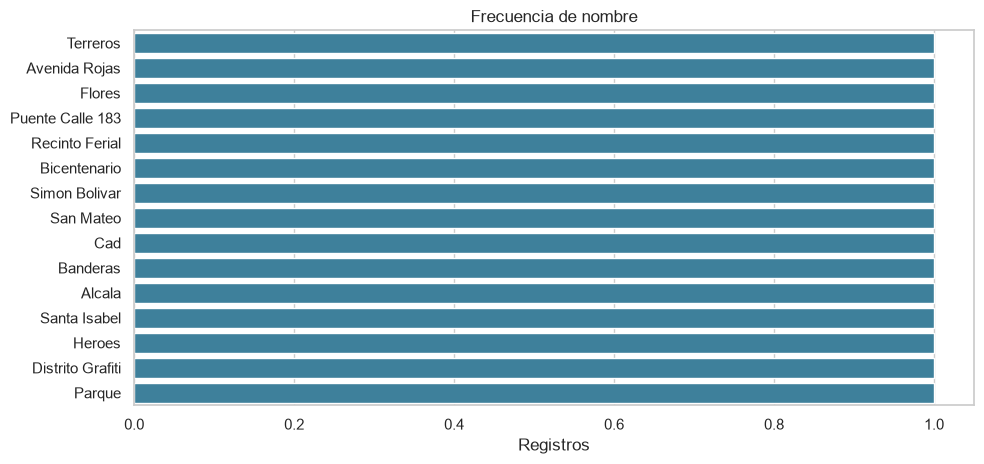

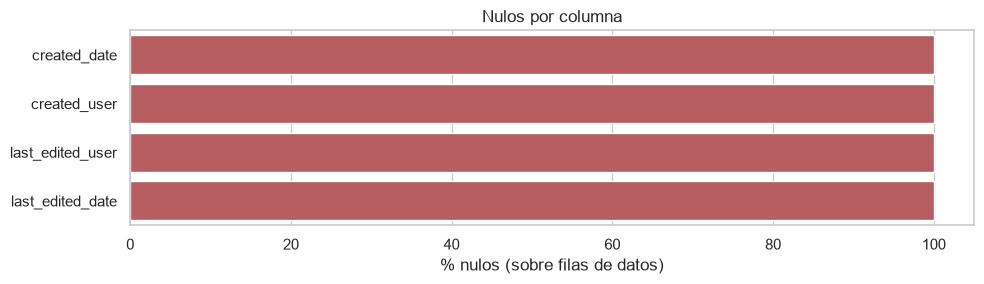

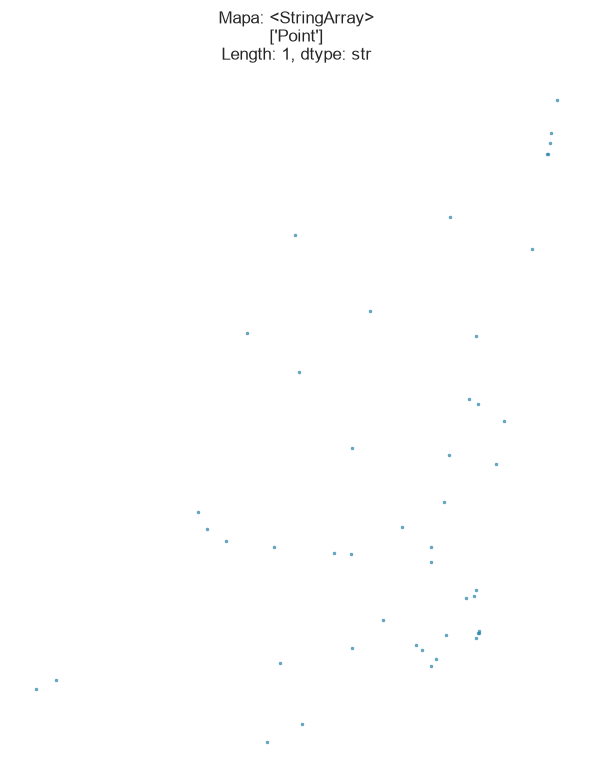

In [8]:
t0('retornos')
SPEC = {
    'id': 'retorno_operacional',
    'titulo': 'Retornos operacionales',
    'path': 'data/raw/MOVILIDAD/retorno_operacional.geojson',
    'origen': 'TransMilenio S.A.',
    'corte': 'Vigente',
    'valor_publico': 'Operación de giro de la red troncal',
    'indicadores': 'MOV-04',
    'notas': 'Puntos de retorno.',
}
RES = explorar_dataset(SPEC, RAW_DIR, PERFILES, smoke=SMOKE)
t1('retornos')


### Trazados troncales

### Trazados troncales

,columna,dtype,tipo_variable,n_nulos,pct_nulos,n_unicos,ejemplo_1,ejemplo_2,ejemplo_3
0,objectid,int32,id/llave,0,0.0,20,126,127,128
1,id_trazado,str,id/llave,0,0.0,20,TZ002,TZ008,TZ009
2,long_traz,float64,numérica discreta,0,0.0,20,11.8213993,9.95684642,13.09255757
3,ori_traz,str,categórica nominal,0,0.0,14,Avenida Calle 80,Autopista Norte,Avenida Caracas
4,fin_traz,str,categórica nominal,0,0.0,18,Terminal,Avenida Calle 6,Portal Americas
5,nom_traz,str,categórica nominal,0,0.0,19,Autopista Norte,NQS Central,Americas
6,le_troncal,str,categórica nominal,0,0.0,12,B,E,F
7,nom_tronc,str,categórica nominal,0,0.0,12,Autopista Norte,NQS Central,Americas
8,fase_tronc,str,categórica nominal,0,0.0,3,FASE I,FASE II,FASE III
9,eta_oper,int32,numérica discreta,0,0.0,1,1,,


,columna,n,n_nulos,pct_nulos,n_unicos,media,mediana,moda,desv_est,min,...,asimetria_skew,curtosis,CV_pct,n_outliers_iqr,pct_outliers,sin_valores_numericos,n_categorias,dominante,pct_dominante,top_5
0,objectid,20,0,0.0,20.0,136.4500,135.5000,126.0000,8.4882,126.0000,...,1.7569,5.0054,6.2208,1.0,5.0,False,NaN,NaN,NaN,NaN
1,id_trazado,20,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,20.0,TZ002,5.0,TZ002=1 | TZ008=1 | TZ009=1 | TZ015=1 | TZ018=1
2,long_traz,20,0,0.0,20.0,6.4142,6.9342,0.6410,4.4141,0.6410,...,0.1524,-1.7118,68.8171,0.0,0.0,False,NaN,NaN,NaN,NaN
3,ori_traz,20,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,14.0,Avenida Calle 80,15.0,Avenida Calle 80=3 | Autopista Norte=2 | Aveni...
4,fin_traz,20,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,18.0,Avenida Calle 6,10.0,Avenida Calle 6=2 | Limite del Distrito=2 | Te...
5,nom_traz,20,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,19.0,Carrera 7,10.0,Carrera 7=2 | Autopista Norte=1 | NQS Central=...
6,le_troncal,20,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,H,15.0,H=3 | E=2 | C=2 | G=2 | M=2
7,nom_tronc,20,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,Caracas Sur,15.0,Caracas Sur=3 | NQS Central=2 | Suba=2 | NQS S...
8,fase_tronc,20,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3.0,FASE I,40.0,FASE I=8 | FASE II=6 | FASE III=6
9,eta_oper,20,0,0.0,1.0,1.0000,1.0000,1.0000,0.0000,1.0000,...,0.0000,0.0000,0.0000,0.0,0.0,False,NaN,NaN,NaN,NaN


No hay valores numéricos para id_trazado.
No hay valores numéricos para ori_traz.
Sin columnas con nulos.


## Interpretación -- Trazados troncales

**Origen**: TransMilenio S.A.  
**Corte temporal**: Vigente  
**Valor público**: Longitud y trazado de la red troncal

**Qué contiene**: 20 filas y 14 columnas; 0.0% de celdas nulas y 0 duplicados.
Capas con geometría (<StringArray>
['MultiLineString', 'LineString']
Length: 2, dtype: str) en CRS EPSG:4326.

**Comportamiento de variables numéricas**:
- `objectid`: media 136.4, mediana 135.5, desv 8.5, rango [126, 164], curtosis +5.0 -- asimetría positiva (+1.76); 1.0 outliers IQR (5%)
- `id_trazado`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)
- `long_traz`: media 6.4, mediana 6.9, desv 4.4, rango [1, 13], curtosis -1.7 -- variabilidad alta (CV=69%)
- `ori_traz`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)
- `fin_traz`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)

**Categóricas dominantes**:
- `id_trazado`: 20.0 categorías; dominante 'TZ002' (5%)
- `ori_traz`: 14.0 categorías; dominante 'Avenida Calle 80' (15%)
- `fin_traz`: 18.0 categorías; dominante 'Avenida Calle 6' (10%)
- `nom_traz`: 19.0 categorías; dominante 'Carrera 7' (10%)

**Notas / qué falta**: Líneas como geometrías.

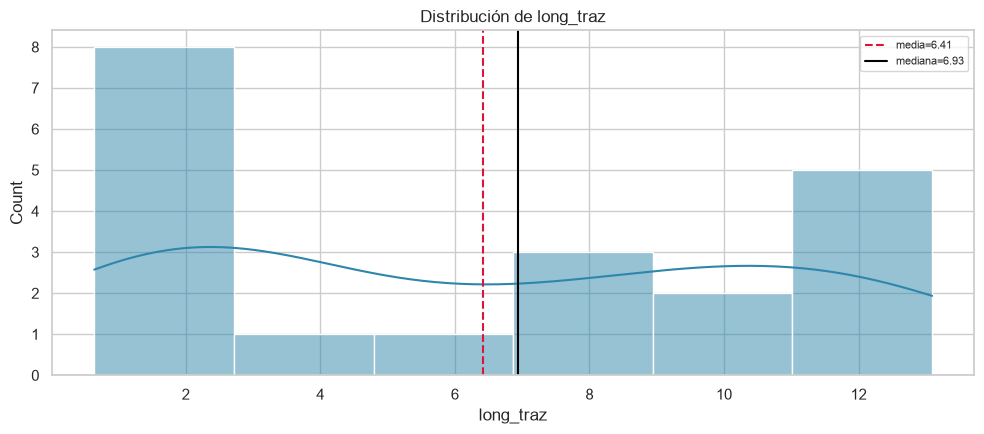

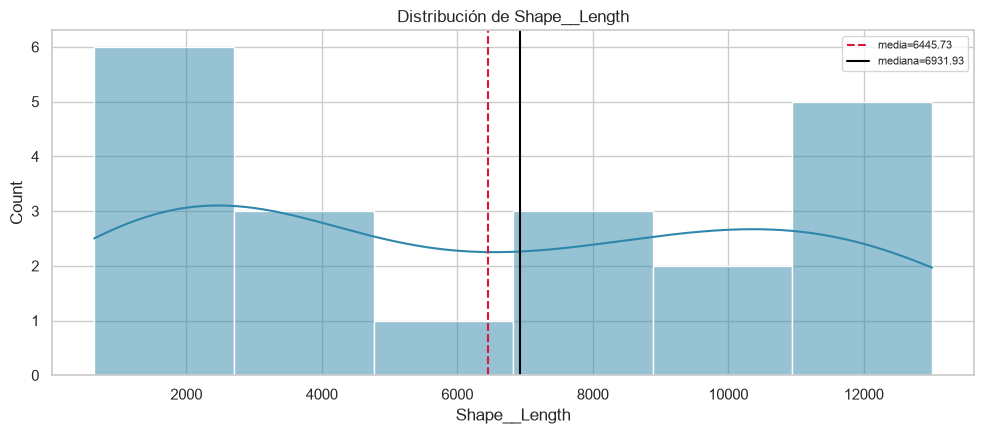

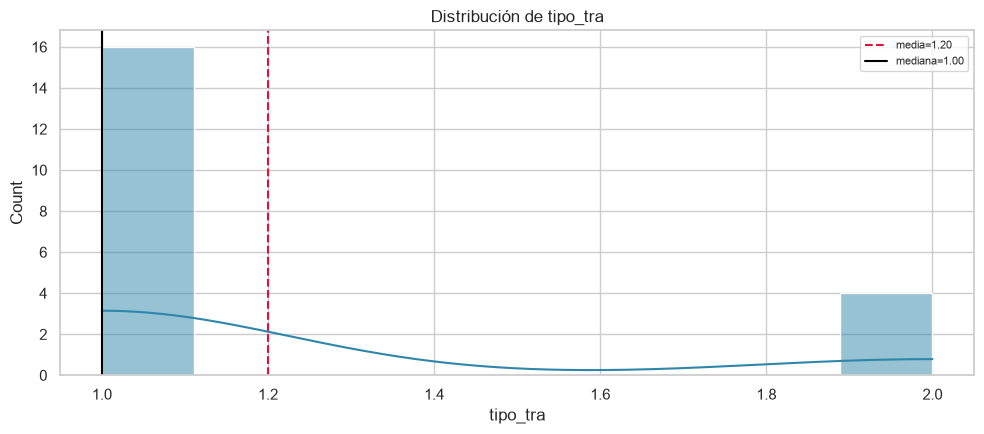

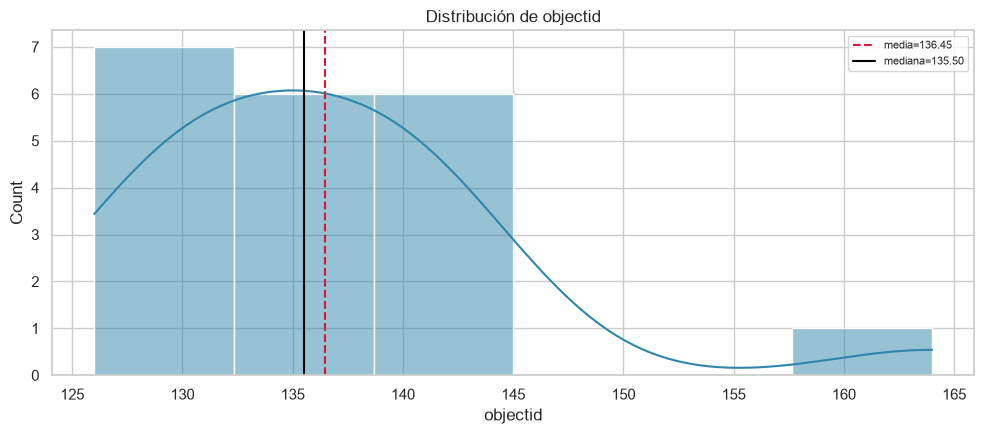

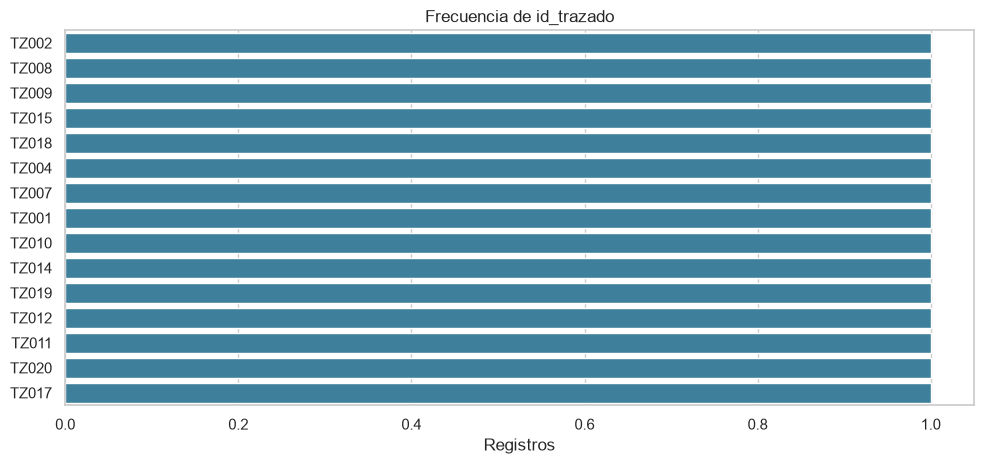

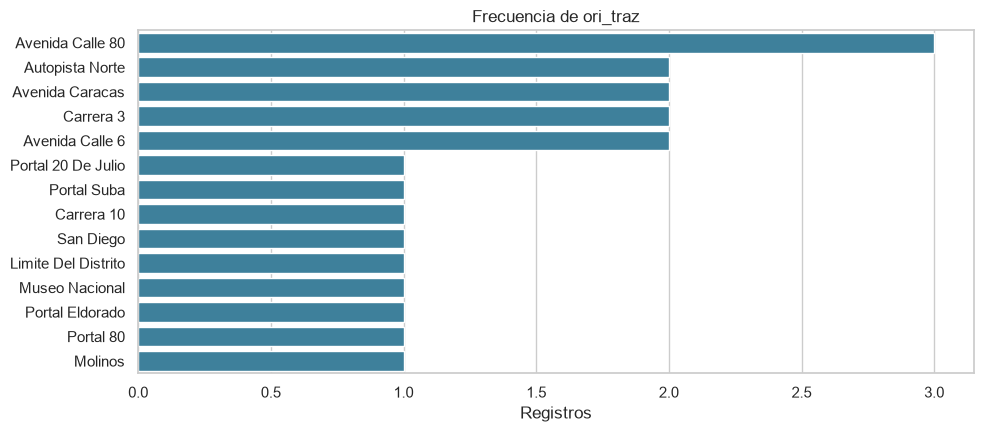

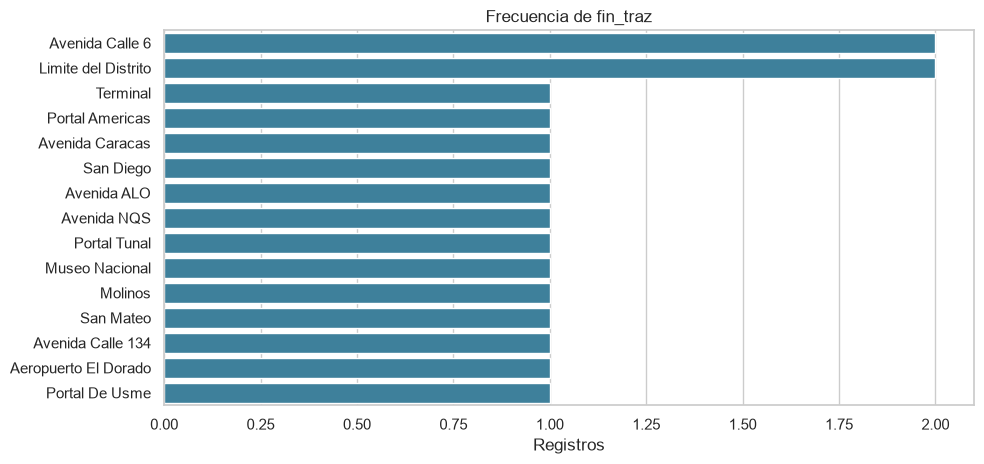

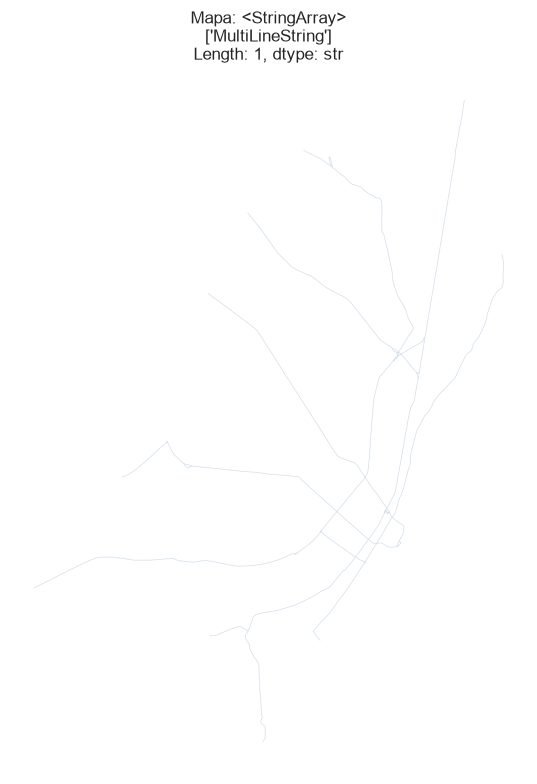

In [9]:
t0('trazados')
SPEC = {
    'id': 'trazados_troncales',
    'titulo': 'Trazados troncales',
    'path': 'data/raw/MOVILIDAD/trazados_troncales.geojson',
    'origen': 'TransMilenio S.A.',
    'corte': 'Vigente',
    'valor_publico': 'Longitud y trazado de la red troncal',
    'indicadores': 'MOV-04',
    'notas': 'Líneas como geometrías.',
}
RES = explorar_dataset(SPEC, RAW_DIR, PERFILES, smoke=SMOKE)
t1('trazados')


### Trazado Línea 2

### Trazado Línea 2 (metro)

,columna,dtype,tipo_variable,n_nulos,pct_nulos,n_unicos,ejemplo_1,ejemplo_2,ejemplo_3
0,OBJECTID,int64,numérica discreta,0,0.0,1,1,,
1,NOMBRE,str,categórica nominal,0,0.0,1,EJE PRINCIPAL SEGUNDA LINEA DEL METRO DE BOGOTÁ,,
2,Shape_Leng,float64,numérica discreta,0,0.0,1,15367.8652332,,
3,SHAPE_Length,float64,numérica discreta,0,0.0,1,0.13870932546720868,,


,columna,n,n_nulos,pct_nulos,n_unicos,media,mediana,moda,desv_est,min,...,asimetria_skew,curtosis,CV_pct,n_outliers_iqr,pct_outliers,sin_valores_numericos,n_categorias,dominante,pct_dominante,top_5
0,OBJECTID,1,0,0.0,1.0,1.0000,1.0000,1.0000,NaN,1.0000,...,NaN,NaN,NaN,0.0,0.0,False,NaN,NaN,NaN,NaN
1,NOMBRE,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,EJE PRINCIPAL SEGUNDA LINEA DEL METRO DE BOGOTÁ,100.0,EJE PRINCIPAL SEGUNDA LINEA DEL METRO DE BOGOTÁ=1
2,Shape_Leng,1,0,0.0,1.0,15367.8652,15367.8652,15367.8652,NaN,15367.8652,...,NaN,NaN,NaN,0.0,0.0,False,NaN,NaN,NaN,NaN
3,SHAPE_Length,1,0,0.0,1.0,0.1387,0.1387,0.1387,NaN,0.1387,...,NaN,NaN,NaN,0.0,0.0,False,NaN,NaN,NaN,NaN


No hay valores numéricos para NOMBRE.
Sin columnas con nulos.


## Interpretación -- Trazado Línea 2 (metro)

**Origen**: Metro de Bogotá  
**Corte temporal**: Vigente (proyecto)  
**Valor público**: Trazado del proyecto L2

**Qué contiene**: 1 filas y 4 columnas; 0.0% de celdas nulas y 0 duplicados.
Capas con geometría (<StringArray>
['MultiLineString']
Length: 1, dtype: str) en CRS EPSG:4686.

**Comportamiento de variables numéricas**:
- `OBJECTID`: media 1.0, mediana 1.0, desv nan, rango [1, 1], curtosis +nan
- `NOMBRE`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)
- `Shape_Leng`: media 15,367.9, mediana 15,367.9, desv nan, rango [15,368, 15,368], curtosis +nan
- `SHAPE_Length`: media 0.1, mediana 0.1, desv nan, rango [0, 0], curtosis +nan

**Categóricas dominantes**:
- `NOMBRE`: 1.0 categorías; dominante 'EJE PRINCIPAL SEGUNDA LINEA DEL METRO DE BOGOTÁ' (100%)

**Notas / qué falta**: EPSG:4686.

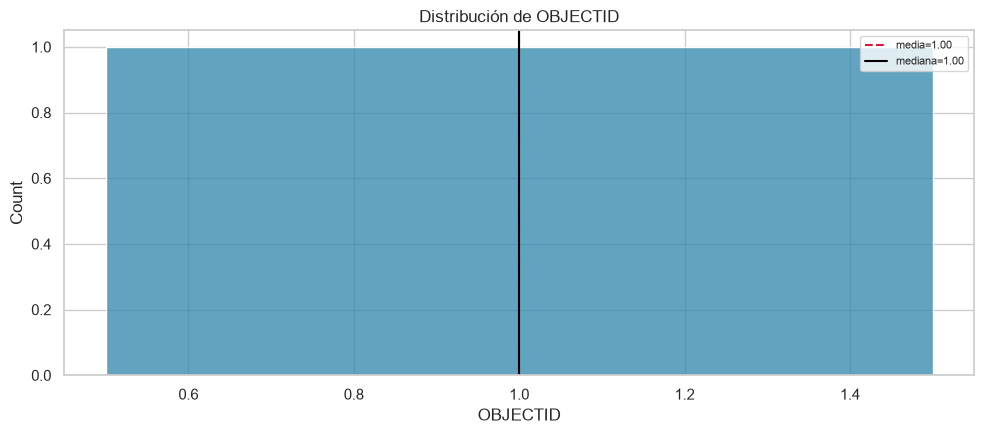

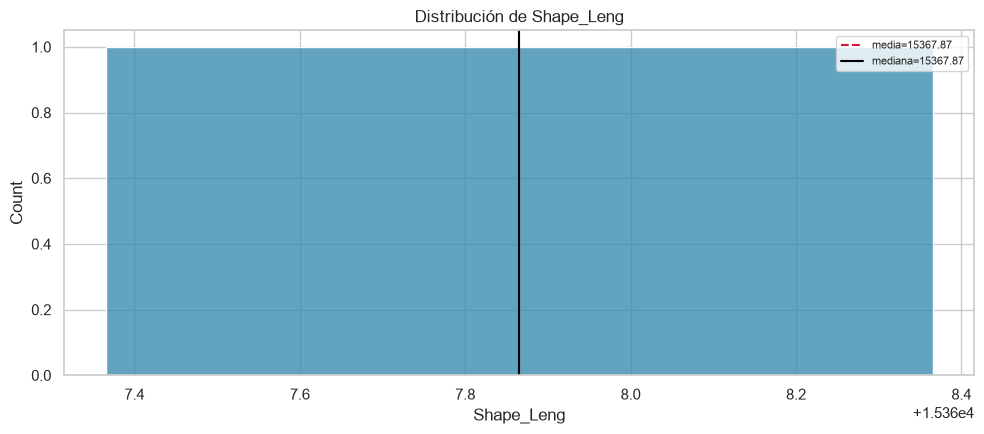

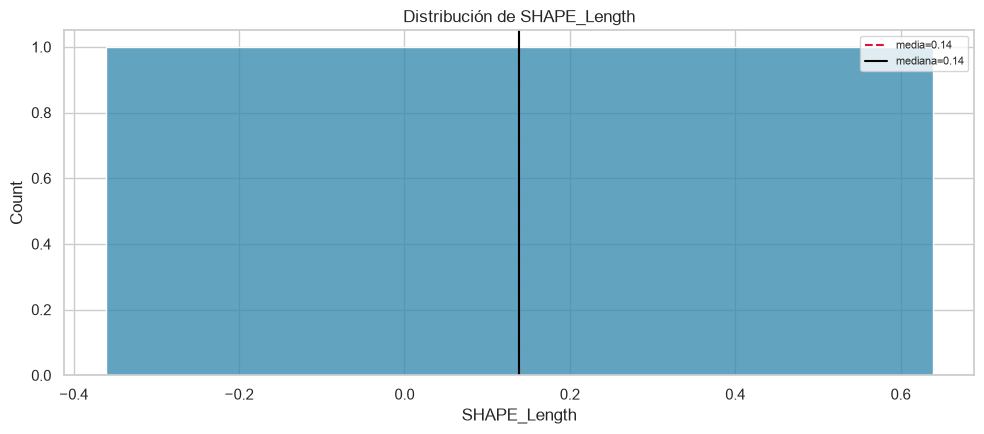

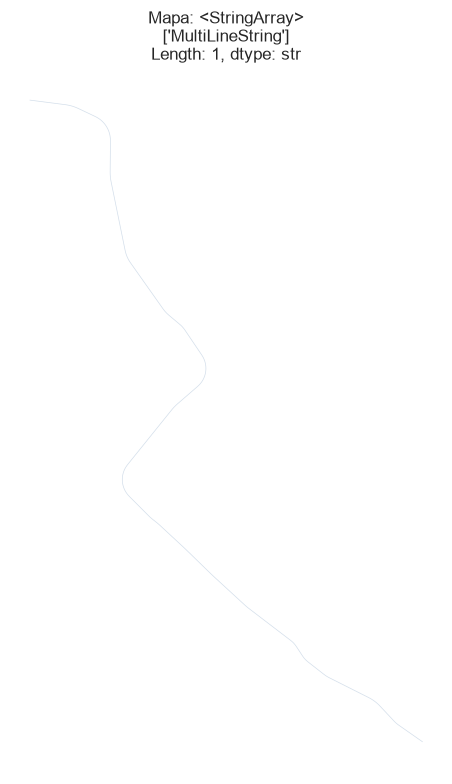

In [10]:
t0('trazado_l2')
SPEC = {
    'id': 'trazado_linea2',
    'titulo': 'Trazado Línea 2 (metro)',
    'path': 'data/raw/MOVILIDAD/trazado_linea2.gpkg',
    'capa': 'trazadosegundalinea',
    'origen': 'Metro de Bogotá',
    'corte': 'Vigente (proyecto)',
    'valor_publico': 'Trazado del proyecto L2',
    'indicadores': 'MOV-04',
    'notas': 'EPSG:4686.',
}
RES = explorar_dataset(SPEC, RAW_DIR, PERFILES, smoke=SMOKE)
t1('trazado_l2')


### Zonas ZAT

### Zonas ZAT (zonas de transporte)

,columna,dtype,tipo_variable,n_nulos,pct_nulos,n_unicos,ejemplo_1,ejemplo_2,ejemplo_3
0,objectid,int32,id/llave,0,0.0,2356,2357,2358,2359
1,id_zat,int32,numérica continua,0,0.0,1215,810,809,823
2,anio_zat,int32,numérica discreta,0,0.0,2,2019,2023,
3,globalid,str,id/llave,0,0.0,2356,{39B5D1C6-E23E-4B67-9404-4B856ADB585C},{3ADA72D0-240A-4B8F-837D-A83FED18333A},{D3B1A241-ACF7-41E5-B7DC-87404D2E8E0C}
4,shape_Length,float64,numérica continua,0,0.0,2041,1.7423336635499849,1.4106992781610161,2.181586570455323
5,shape_Area,float64,numérica continua,0,0.0,2041,0.11121512147173034,0.06701775987394447,0.14863873063003663


,columna,n,n_nulos,pct_nulos,n_unicos,media,mediana,moda,desv_est,min,...,asimetria_skew,curtosis,CV_pct,n_outliers_iqr,pct_outliers,sin_valores_numericos,n_categorias,dominante,pct_dominante,top_5
0,objectid,2356,0,0.0,2356.0,3534.5000,3534.5000,2357.0000,680.2629,2357.0000,...,0.0000,-1.2000,19.2464,0.0,0.00,False,NaN,NaN,NaN,NaN
1,id_zat,2356,0,0.0,1215.0,685.0764,589.5000,1.0000,506.7435,1.0000,...,0.9210,0.0921,73.9689,5.0,0.21,False,NaN,NaN,NaN,NaN
2,anio_zat,2356,0,0.0,2.0,2021.0628,2023.0000,2023.0000,1.9994,2019.0000,...,-0.0629,-1.9977,0.0989,0.0,0.00,False,NaN,NaN,NaN,NaN
3,globalid,2356,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2356.0,{39B5D1C6-E23E-4B67-9404-4B856ADB585C},0.04,{39B5D1C6-E23E-4B67-9404-4B856ADB585C}=1 | {3A...
4,shape_Length,2356,0,0.0,2041.0,0.0723,0.0284,0.0065,0.2515,0.0065,...,8.3831,77.6711,347.9401,244.0,10.36,False,NaN,NaN,NaN,NaN
5,shape_Area,2356,0,0.0,2041.0,0.0017,0.0000,0.0000,0.0139,0.0000,...,10.4153,115.7937,833.1945,275.0,11.67,False,NaN,NaN,NaN,NaN


No hay valores numéricos para globalid.
Sin columnas con nulos.


## Interpretación -- Zonas ZAT (zonas de transporte)

**Origen**: TransMilenio S.A.  
**Corte temporal**: Vigente  
**Valor público**: División zonal de operación y demanda

**Qué contiene**: 2,356 filas y 6 columnas; 0.0% de celdas nulas y 0 duplicados.
Capas con geometría (<StringArray>
['MultiPolygon']
Length: 1, dtype: str) en CRS EPSG:4326.

**Comportamiento de variables numéricas**:
- `objectid`: media 3,534.5, mediana 3,534.5, desv 680.3, rango [2,357, 4,712], curtosis -1.2
- `id_zat`: media 685.1, mediana 589.5, desv 506.7, rango [1, 1,950], curtosis +0.1 -- variabilidad alta (CV=74%); 5.0 outliers IQR (0%)
- `anio_zat`: media 2,021.1, mediana 2,023.0, desv 2.0, rango [2,019, 2,023], curtosis -2.0
- `globalid`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)
- `shape_Length`: media 0.1, mediana 0.0, desv 0.3, rango [0, 4], curtosis +77.7 -- variabilidad alta (CV=348%); asimetría positiva (+8.38); 244.0 outliers IQR (10%)

**Categóricas dominantes**:
- `globalid`: 2,356.0 categorías; dominante '{39B5D1C6-E23E-4B67-9404-4B856ADB585C}' (0%)

**Notas / qué falta**: Polígonos de zonas.

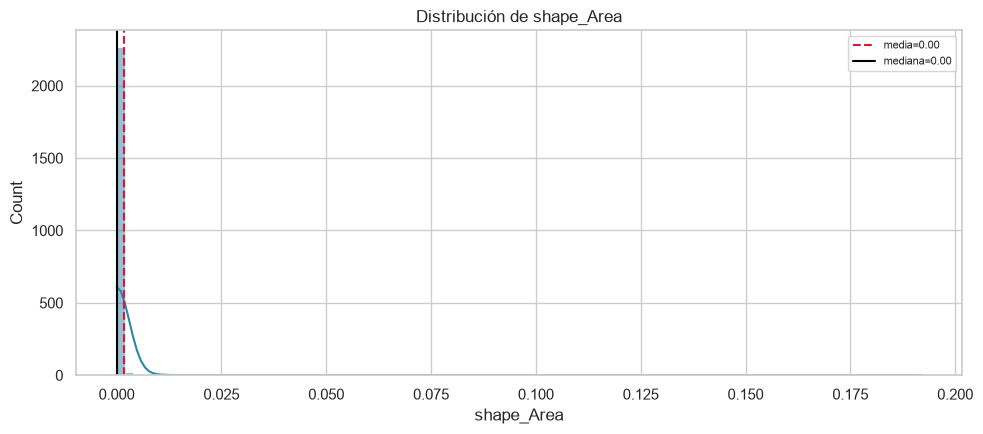

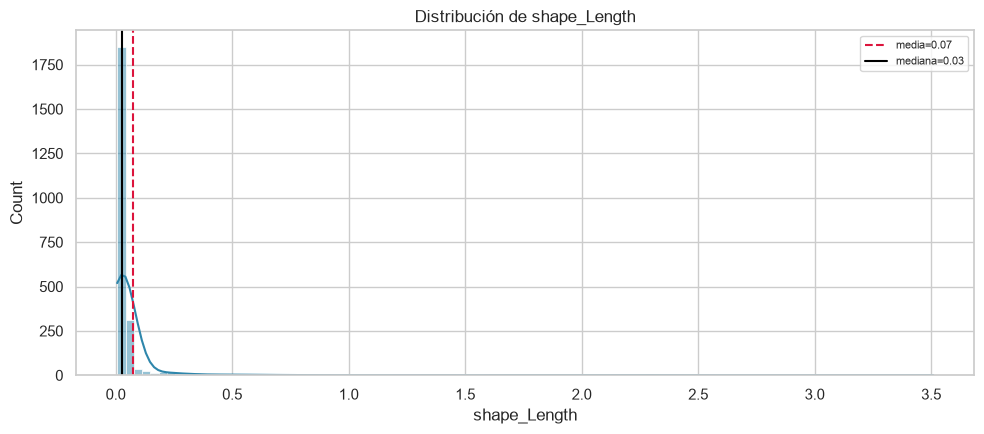

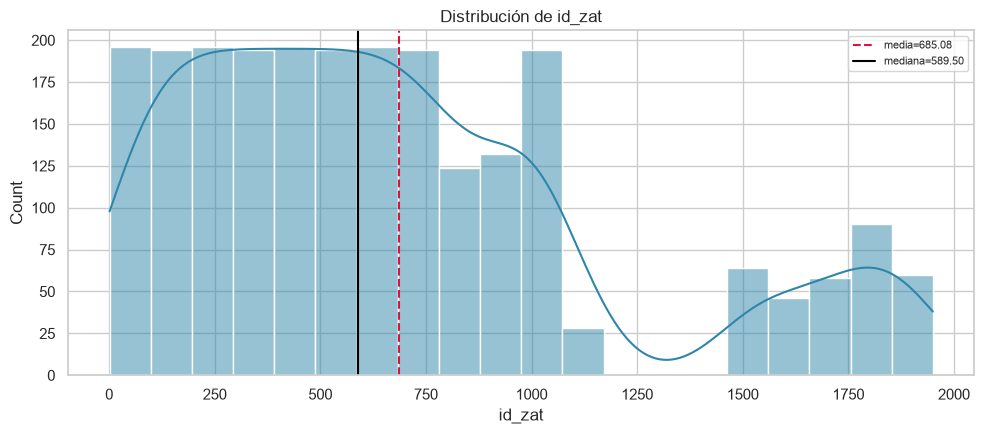

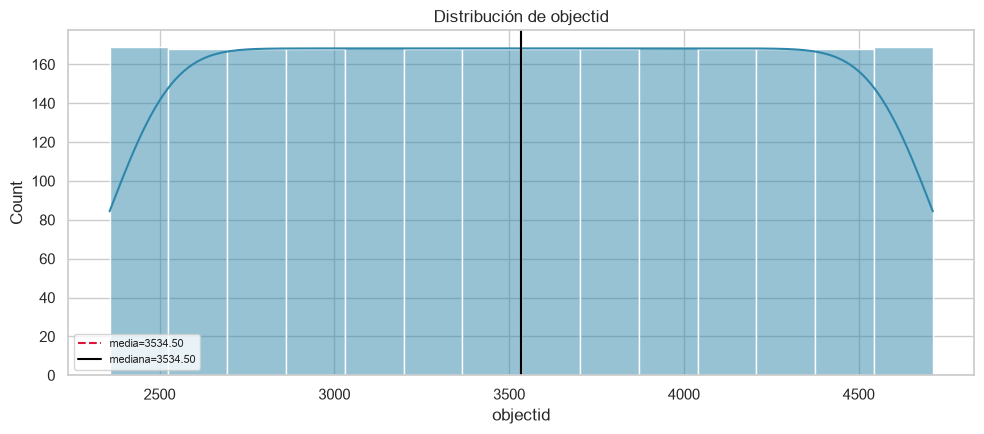

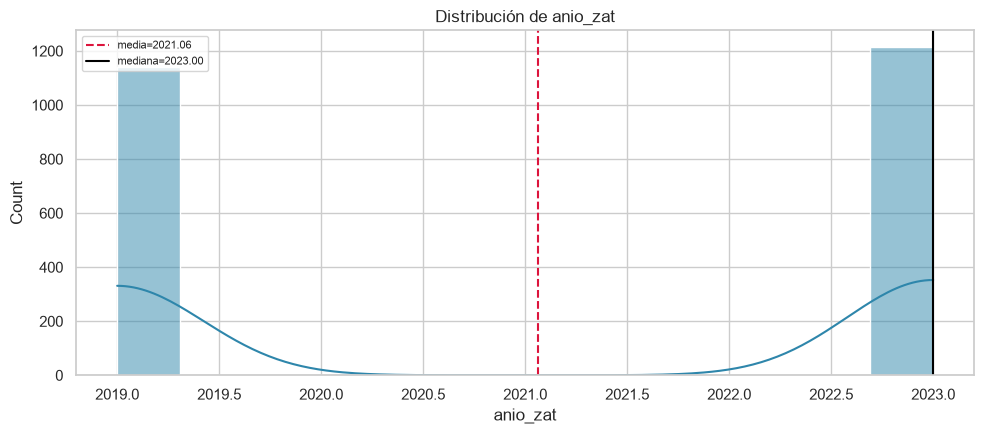

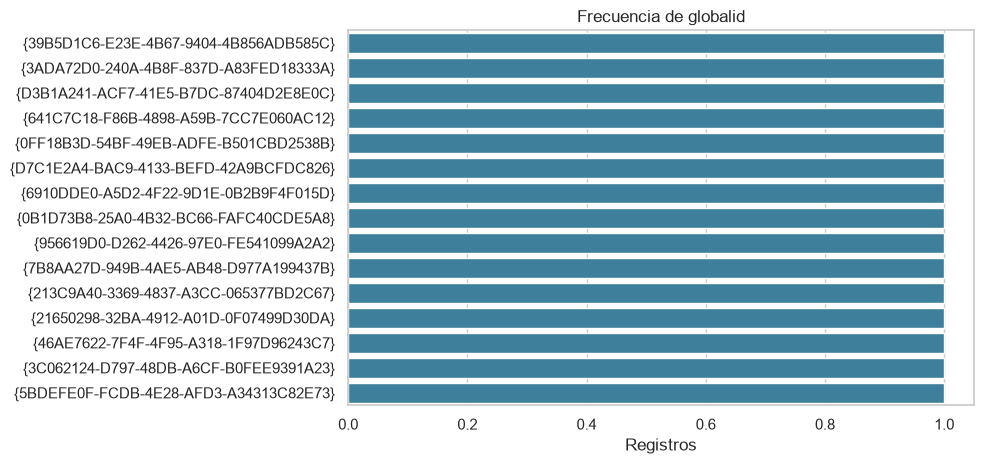

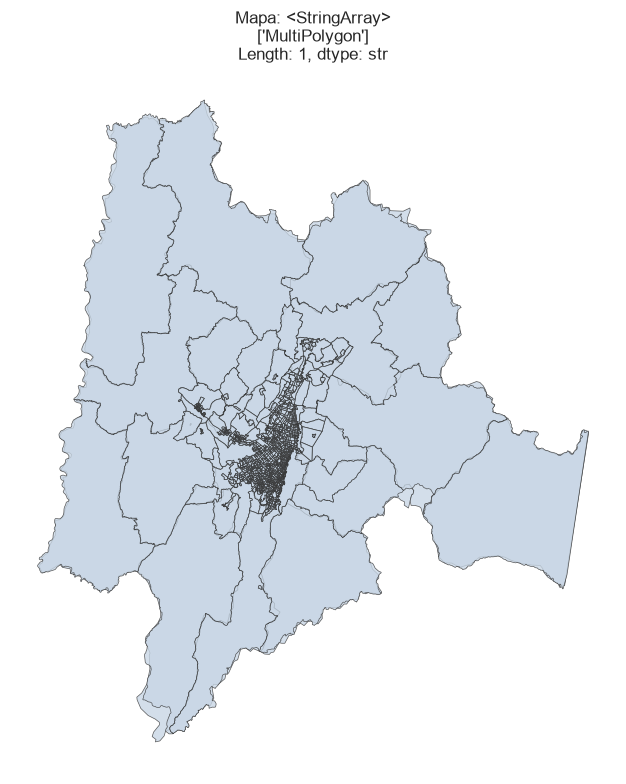

In [11]:
t0('zats')
SPEC = {
    'id': 'zonas_zat',
    'titulo': 'Zonas ZAT (zonas de transporte)',
    'path': 'data/raw/MOVILIDAD/zonas_zat.geojson',
    'origen': 'TransMilenio S.A.',
    'corte': 'Vigente',
    'valor_publico': 'División zonal de operación y demanda',
    'indicadores': 'MOV-01, MOV-03',
    'notas': 'Polígonos de zonas.',
}
RES = explorar_dataset(SPEC, RAW_DIR, PERFILES, smoke=SMOKE)
t1('zats')


## 4. Rutas y flota

### Servicios y rutas troncales-zonales

### Servicios y rutas troncales-zonales

,columna,dtype,tipo_variable,n_nulos,pct_nulos,n_unicos,ejemplo_1,ejemplo_2,ejemplo_3
0,objectid,int64,id/llave,0,0.00,682,10421,10422,10443
1,abrevia,str,categórica nominal,158,23.17,31,AAA,BBB,ALI
2,cod_linea,str,categórica nominal,0,0.00,542,GA503,BB911,BK23
3,nom_ruta,str,categórica nominal,0,0.00,535,GA503,BB911,BK23
4,orig_ruta,str,categórica nominal,0,0.00,260,San Bernardino,Est. Calle 100,Portal Norte
5,dest_ruta,str,categórica nominal,0,0.00,355,Est. Calle 100,San Bernardino,Portal Norte
6,fec_impl,str,categórica nominal,0,0.00,260,13/07/2020,,29/10/2025
7,loc_orig,int64,numérica discreta,0,0.00,19,7,11,9
8,loc_dest,int64,numérica discreta,0,0.00,19,12,11,1
9,long_ruta,float64,numérica continua,0,0.00,680,33.53354731,28.48388308,3.5330569


,columna,n,n_nulos,pct_nulos,n_unicos,media,mediana,moda,desv_est,min,...,asimetria_skew,curtosis,CV_pct,n_outliers_iqr,pct_outliers,sin_valores_numericos,n_categorias,dominante,pct_dominante,top_5
0,objectid,682,0,0.0,682.0,11021.9780,11053.5000,10421.0000,2.605912e+02,10421.0000,...,-0.5191,-0.7129,2.3643,0.0,0.00,False,NaN,NaN,NaN,NaN
1,abrevia,524,158,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,32.0,(nulo),23.17,(nulo)=158 | ALI=101 | HHH=57 | AAA=43 | KKK=37
2,cod_linea,682,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,542.0,MK86,0.59,MK86=4 | ML82=4 | BG12=4 | DL81=4 | FJ23=4
3,nom_ruta,682,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,535.0,MK86,0.59,MK86=4 | ML82=4 | BG12=4 | DL81=4 | FJ23=4
4,orig_ruta,682,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,260.0,Portal Usme,3.37,Portal Usme=23 | Portal Suba=20 | Portal Tunal...
5,dest_ruta,682,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,355.0,Germania,2.20,Germania=15 | Metrovivienda=12 | Portal Usme=1...
6,fec_impl,682,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,260.0,,19.21,=131 | 26/03/2015=39 | 22/05/2021=16 | 17/02/...
7,loc_orig,682,0,0.0,19.0,8.1393,8.0000,11.0000,4.521700e+00,0.0000,...,0.5409,0.1848,55.5543,0.0,0.00,False,NaN,NaN,NaN,NaN
8,loc_dest,682,0,0.0,19.0,8.0894,8.0000,11.0000,4.817000e+00,0.0000,...,0.5539,-0.1193,59.5467,0.0,0.00,False,NaN,NaN,NaN,NaN
9,long_ruta,682,0,0.0,680.0,506243.1859,25.3344,39.3631,3.991614e+06,3.0212,...,9.0785,90.1178,788.4777,15.0,2.20,False,NaN,NaN,NaN,NaN


## Interpretación -- Servicios y rutas troncales-zonales

**Origen**: TransMilenio S.A.  
**Corte temporal**: Vigente (fecha edición 2026-07)  
**Valor público**: Oferta de rutas: tipo de servicio, localidades de origen/destino y longitud

**Qué contiene**: 682 filas y 32 columnas; 2.33% de celdas nulas y 0 duplicados.
Columnas territoriales detectadas: **loc_orig, loc_dest**.

**Comportamiento de variables numéricas**:
- `objectid`: media 11,022.0, mediana 11,053.5, desv 260.6, rango [10,421, 11,413], curtosis -0.7
- `abrevia`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)
- `cod_linea`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)
- `nom_ruta`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)
- `orig_ruta`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)

**Categóricas dominantes**:
- `abrevia`: 32.0 categorías; dominante '(nulo)' (23%)
- `cod_linea`: 542.0 categorías; dominante 'MK86' (1%)
- `nom_ruta`: 535.0 categorías; dominante 'MK86' (1%)
- `orig_ruta`: 260.0 categorías; dominante 'Portal Usme' (3%)

**Cobertura territorial**: 18 localidades con dato (de 20 + Bogotá).

**Notas / qué falta**: 682 registros, 32 columnas.

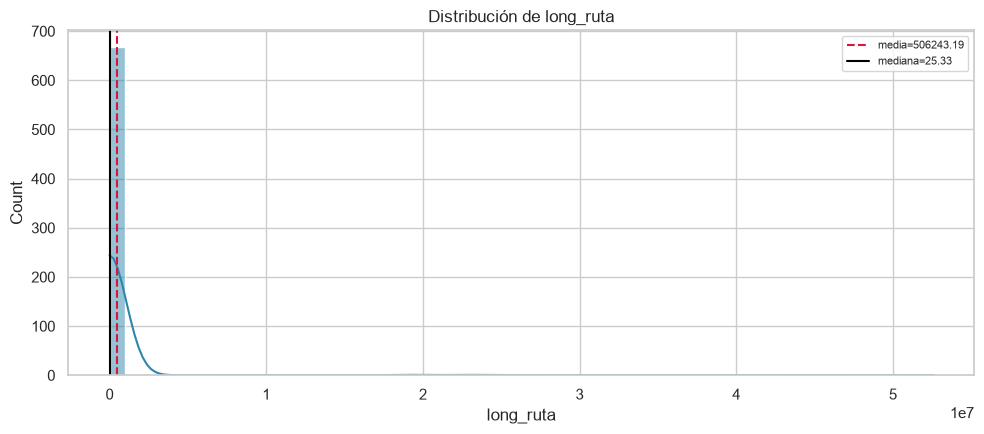

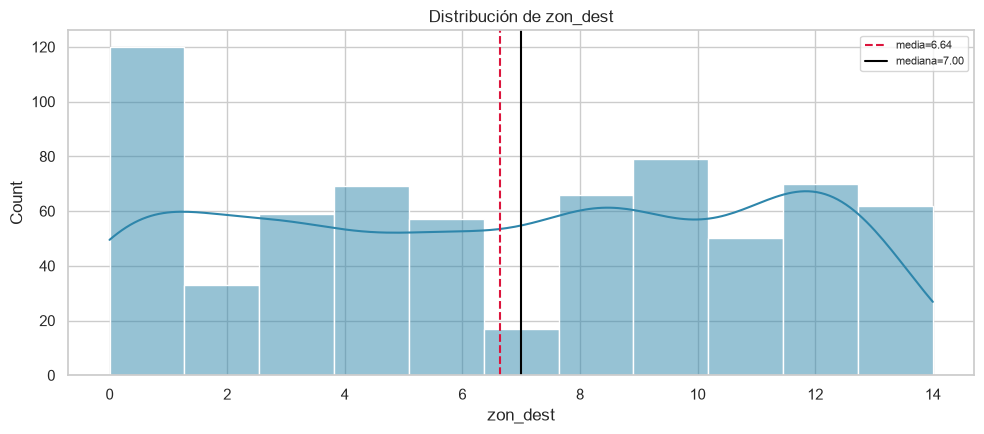

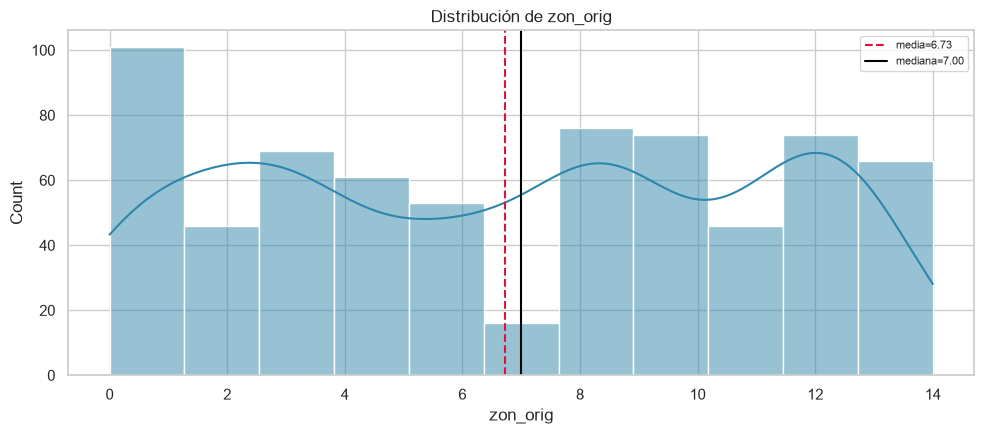

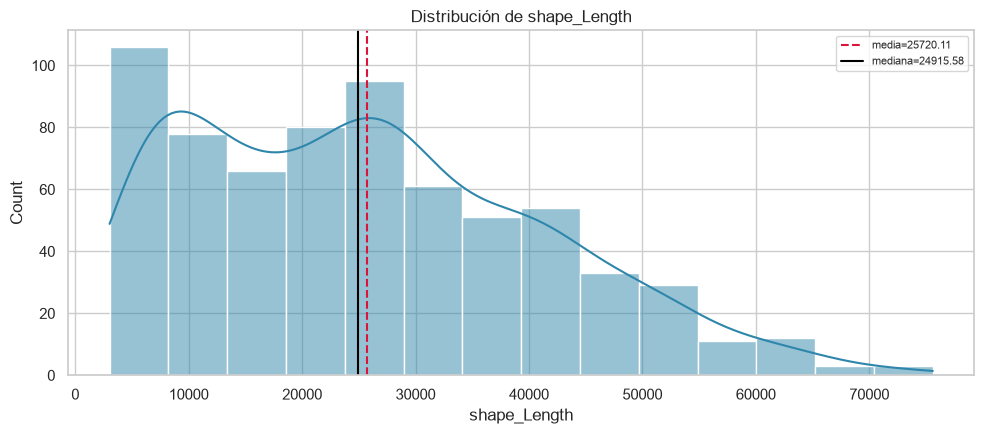

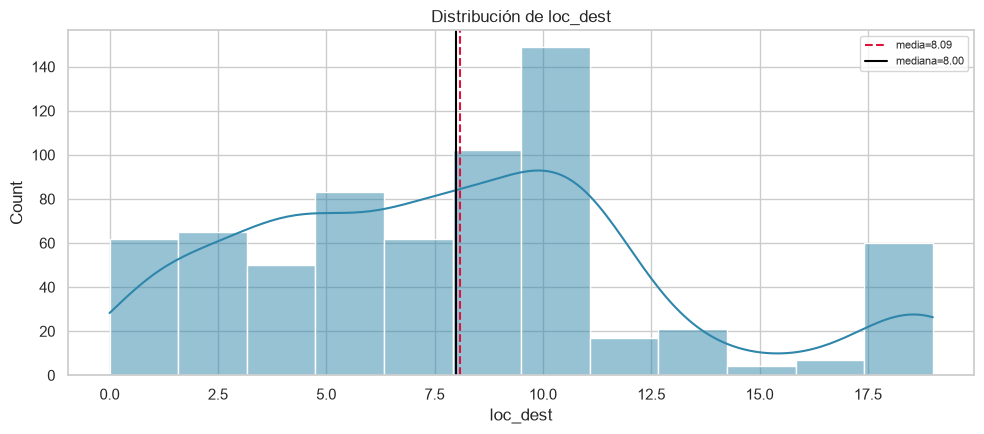

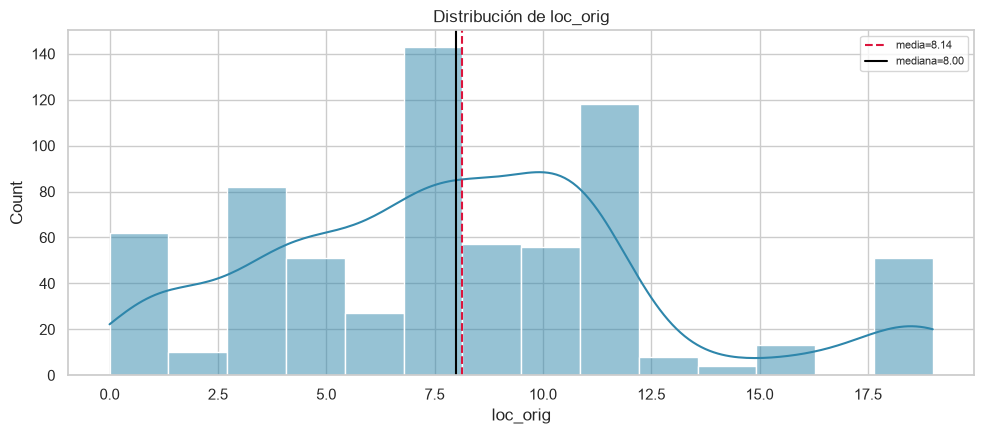

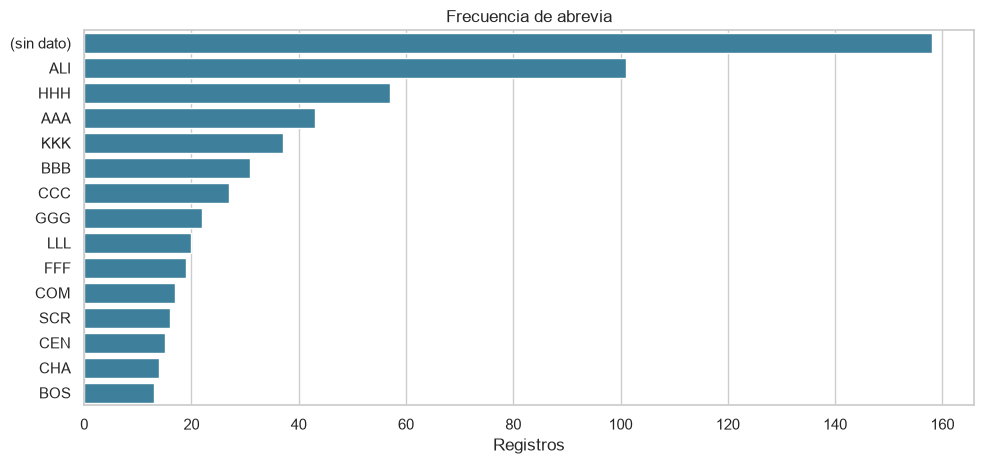

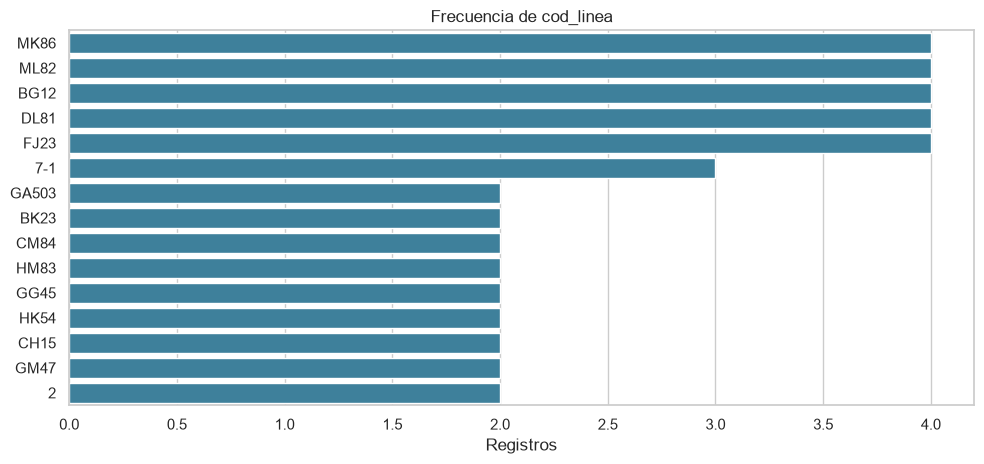

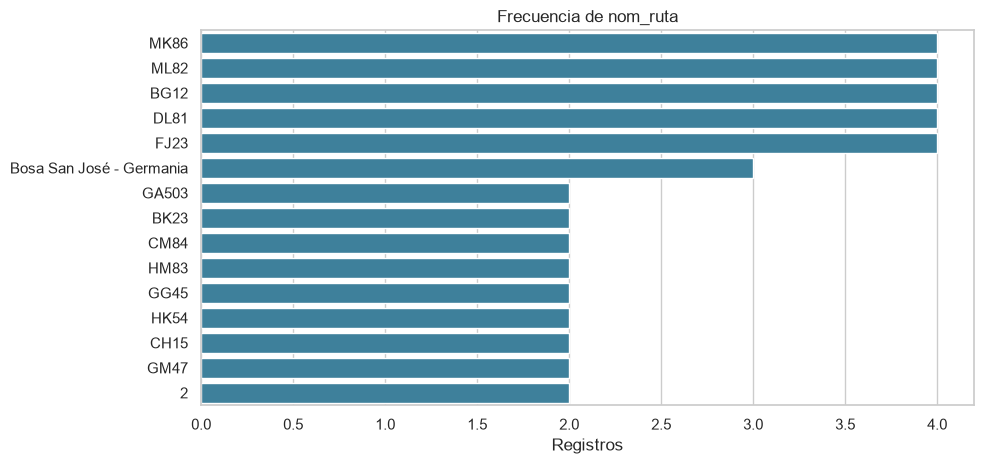

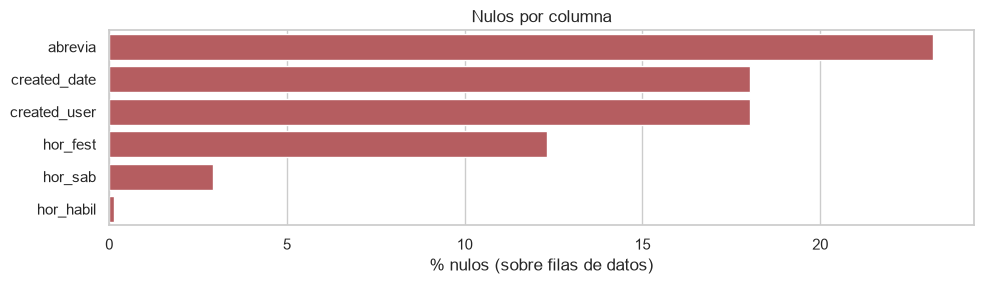

In [12]:
t0('rutas')
SPEC = {
    'id': 'servicios_rutas',
    'titulo': 'Servicios y rutas troncales-zonales',
    'path': 'data/raw/MOVILIDAD/servicios_rutas_troncales_zonales.csv',
    'origen': 'TransMilenio S.A.',
    'corte': 'Vigente (fecha edición 2026-07)',
    'valor_publico': 'Oferta de rutas: tipo de servicio, localidades de origen/destino y longitud',
    'indicadores': 'MOV-03 (rutas por localidad)',
    'notas': '682 registros, 32 columnas.',
}
RES = explorar_dataset(SPEC, RAW_DIR, PERFILES, smoke=SMOKE)
t1('rutas')


### Flota vinculada SITP

### Flota vinculada SITP (dic 2024)

,columna,dtype,tipo_variable,n_nulos,pct_nulos,n_unicos,ejemplo_1,ejemplo_2,ejemplo_3
0,zona,str,categórica nominal,0,0.0,37,ENGATIVÁ,Engativá,SAN CRISTÓBAL
1,fase,str,categórica nominal,0,0.0,5,FASE III,Fase III,FASE IV
2,componente,str,categórica nominal,0,0.0,3,TRONCAL,ALIMENTACIÓN,Zonal
3,estatus_vinculacion,str,categórica nominal,0,0.0,2,Referente,Reserva,
4,combustible,str,categórica nominal,0,0.0,6,DIESEL,HIBRIDO (DIESEL - ELÉCTRICO),HIBRIDO (DIESEL - ELECTRICO)
5,modelo,int64,numérica discreta,0,0.0,16,2012,2008,2010
6,codigo_bus,str,id/llave,0,0.0,10518,E001,E002,E003
7,fecha_vinculacion,str,categórica nominal,0,0.0,1052,10/04/2012,23/03/2012,13/04/2012
8,accesible,str,categórica nominal,0,0.0,4,PLATAFORMA ALTA,ENTRADA BAJA,NO ACCESIBLE
9,edad,float64,numérica discreta,316,3.0,13,12.0,11.0,10.0


,columna,n,n_nulos,n_categorias,dominante,pct_dominante,top_5,pct_nulos,n_unicos,media,...,rango,Q1,Q3,IQR,asimetria_skew,curtosis,CV_pct,n_outliers_iqr,pct_outliers,sin_valores_numericos
0,zona,10518,0,37.0,Usaquén,10.63,Usaquén=1118 | Bosa=1115 | Kennedy=759 | Engat...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,fase,10518,0,5.0,Fase III,52.66,Fase III=5539 | Fase V=1829 | FASE III=1457 | ...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,componente,10518,0,3.0,Zonal,70.05,Zonal=7368 | TRONCAL=2202 | ALIMENTACIÓN=948,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,estatus_vinculacion,10518,0,2.0,Referente,94.53,Referente=9943 | Reserva=575,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,combustible,10518,0,6.0,DIESEL,62.30,DIESEL=6553 | GNV=2143 | ELECTRICO=1129 | ELÉC...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,modelo,10518,0,NaN,NaN,NaN,NaN,0.0,16.0,2017.2780,...,16.0,2014.0,2021.0,7.0,-0.0621,-1.4307,0.1834,0.0,0.0,False
6,codigo_bus,10518,0,10518.0,E001,0.01,E001=1 | E002=1 | E003=1 | E004=1 | E041=1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,fecha_vinculacion,10518,0,1052.0,5/06/2019,3.18,5/06/2019=334 | 9/08/2022=229 | 8/09/2022=186 ...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,accesible,10518,0,4.0,CON ELEVADOR,42.41,CON ELEVADOR=4461 | NO ACCESIBLE=3108 | PLATAF...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,edad,10202,316,NaN,NaN,NaN,NaN,3.0,13.0,6.2439,...,12.0,3.0,10.0,7.0,0.1645,-1.5844,55.4254,0.0,0.0,False


No hay valores numéricos para zona.
No hay valores numéricos para fase.
No hay valores numéricos para componente.
No hay valores numéricos para estatus_vinculacion.


## Interpretación -- Flota vinculada SITP (dic 2024)

**Origen**: TransMilenio S.A. -- datos abiertos  
**Corte temporal**: Dic 2024  
**Valor público**: Composición de la flota: tipo de bus, combustible, emisiones, accesibilidad y edad

**Qué contiene**: 10,518 filas y 14 columnas; 0.21% de celdas nulas y 0 duplicados.

**Comportamiento de variables numéricas**:
- `zona`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)
- `fase`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)
- `componente`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)
- `estatus_vinculacion`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)
- `combustible`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)

**Categóricas dominantes**:
- `zona`: 37.0 categorías; dominante 'Usaquén' (11%)
- `fase`: 5.0 categorías; dominante 'Fase III' (53%)
- `componente`: 3.0 categorías; dominante 'Zonal' (70%)
- `estatus_vinculacion`: 2.0 categorías; dominante 'Referente' (95%)

**Notas / qué falta**: 10.518 buses, 14 columnas.

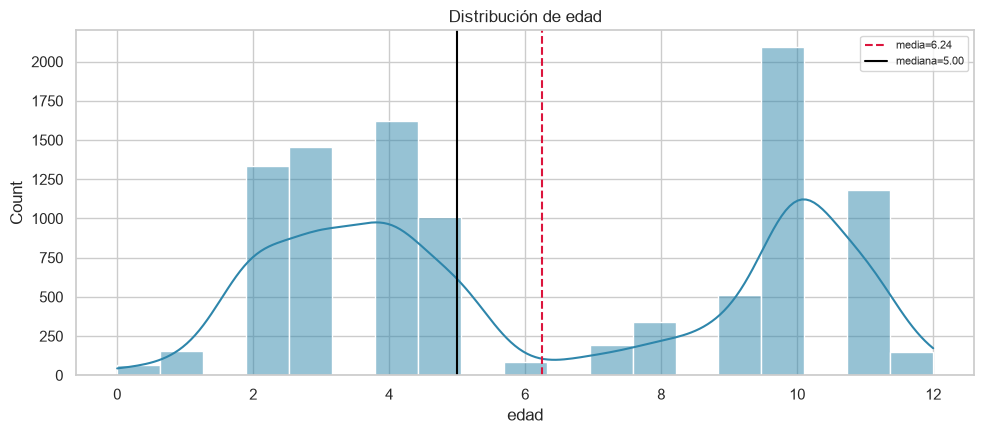

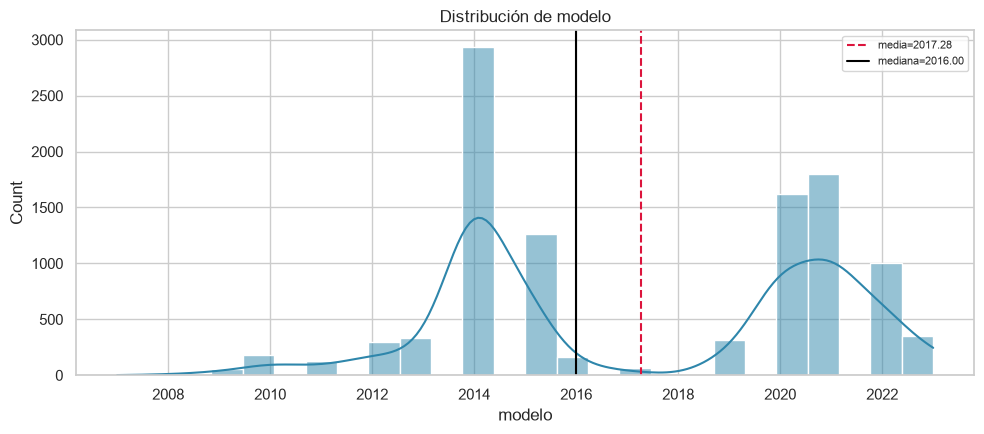

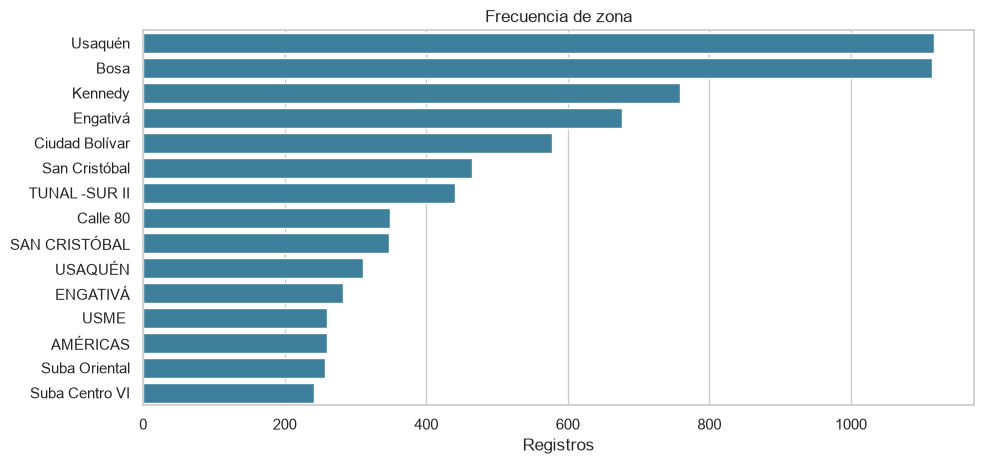

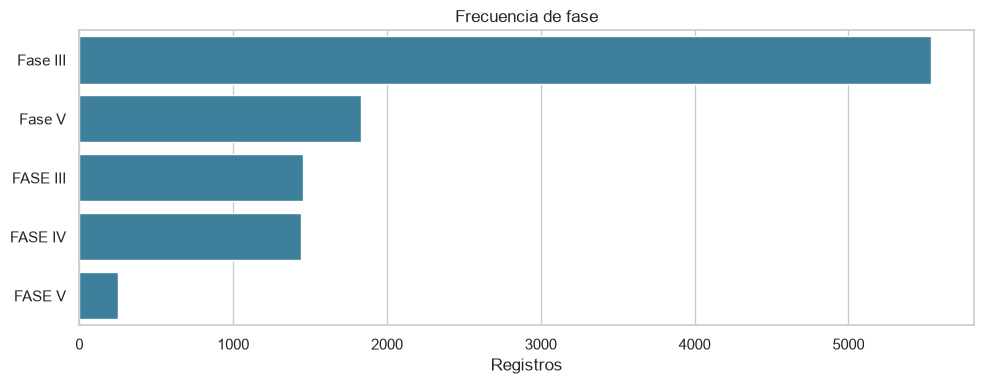

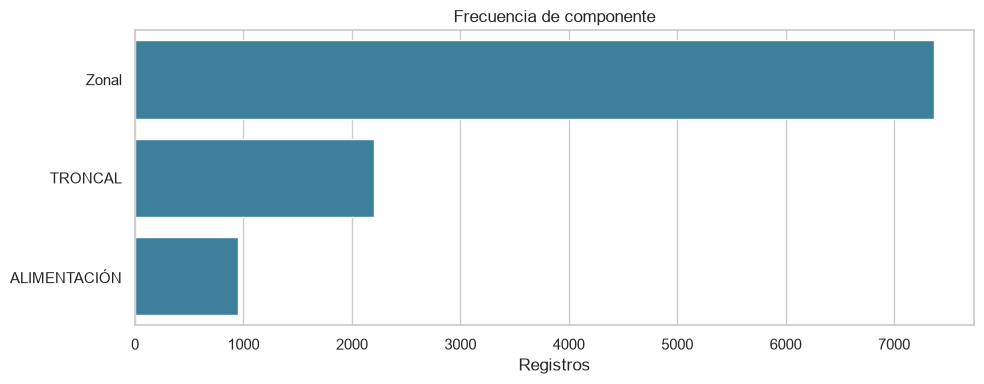

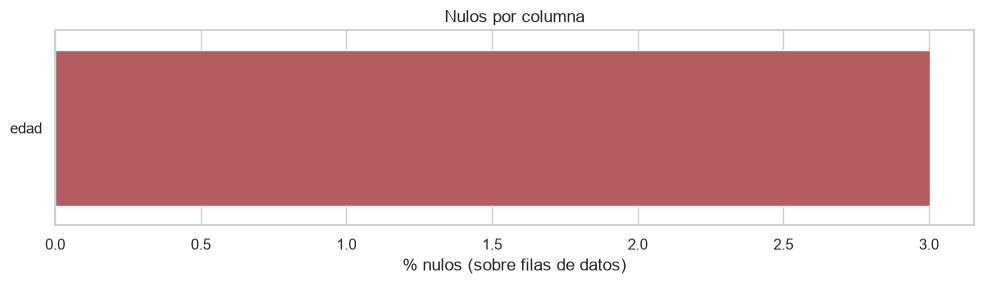

In [13]:
t0('flota')
SPEC = {
    'id': 'flota_sitp_2024_12',
    'titulo': 'Flota vinculada SITP (dic 2024)',
    'path': 'data/raw/MOVILIDAD/flota_vinculada_sitp_2024-12.csv',
    'origen': 'TransMilenio S.A. -- datos abiertos',
    'corte': 'Dic 2024',
    'valor_publico': 'Composición de la flota: tipo de bus, combustible, emisiones, accesibilidad y edad',
    'indicadores': 'MOV-03 (oferta de buses por localidad de operación)',
    'notas': '10.518 buses, 14 columnas.',
}
RES = explorar_dataset(SPEC, RAW_DIR, PERFILES, smoke=SMOKE)
t1('flota')


## 5. GTFS del SITP

### GTFS SITP (11 tablas)

### GTFS SITP (11 tablas)

### GTFS SITP (11 tablas)

,tabla
0,agency.txt
1,routes.txt
2,stops.txt
3,trips.txt
4,stop_times.txt
5,calendar.txt
6,calendar_dates.txt
7,shapes.txt
8,frequencies.txt
9,fare_attributes.txt


**Tabla `agency.txt`** -- 7 filas muestra, 7 columnas

,columna,dtype,tipo_variable,n_nulos,pct_nulos,n_unicos,ejemplo_1,ejemplo_2,ejemplo_3
0,agency_id,int64,numérica discreta,0,0.0,7,1,2,6
1,agency_name,str,categórica nominal,0,0.0,7,Transmilenio-Troncal,Transmilenio-Alimentadores,Transmilenio-Dual
2,agency_url,str,categórica nominal,0,0.0,5,http://www.sitp.gov.co,https://www.sitp.gov.co/publicaciones/40083/ur...,https://www.sitp.gov.co/publicaciones/40085/co...
3,agency_timezone,str,categórica nominal,0,0.0,1,America/Bogota,,
4,agency_lang,str,categórica nominal,0,0.0,1,es,,
5,agency_phone,int64,numérica discreta,0,0.0,1,18000115510,,
6,agency_fare_url,str,categórica nominal,0,0.0,1,https://www.sitp.gov.co/publicaciones/40710/ta...,,


...

**Tabla `feed_info.txt`** -- 1 filas muestra, 7 columnas

,columna,dtype,tipo_variable,n_nulos,pct_nulos,n_unicos,ejemplo_1,ejemplo_2,ejemplo_3
0,feed_publisher_name,str,categórica nominal,0,0.0,1,Transmilenio S.A.,,
1,feed_start_date,int64,numérica discreta,0,0.0,1,20260101,,
2,feed_version,int64,numérica discreta,0,0.0,1,1,,
3,feed_end_date,int64,numérica discreta,0,0.0,1,20261231,,
4,feed_lang,str,categórica nominal,0,0.0,1,es,,
5,feed_publisher_url,str,categórica nominal,0,0.0,1,https://www.transmilenio.gov.co/,,
6,feed_contact_email,str,categórica nominal,0,0.0,1,radicacion@transmilenio.gov.co,,


,columna,n,n_nulos,n_categorias,dominante,pct_dominante,top_5,pct_nulos,n_unicos,media,...,rango,Q1,Q3,IQR,asimetria_skew,curtosis,CV_pct,n_outliers_iqr,pct_outliers,sin_valores_numericos
0,feed_publisher_name,1,0,1.0,Transmilenio S.A.,100.0,Transmilenio S.A.=1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,feed_start_date,1,0,NaN,NaN,NaN,NaN,0.0,1.0,20260101.0,...,0.0,20260101.0,20260101.0,0.0,NaN,NaN,NaN,0.0,0.0,False
2,feed_version,1,0,NaN,NaN,NaN,NaN,0.0,1.0,1.0,...,0.0,1.0,1.0,0.0,NaN,NaN,NaN,0.0,0.0,False
3,feed_end_date,1,0,NaN,NaN,NaN,NaN,0.0,1.0,20261231.0,...,0.0,20261231.0,20261231.0,0.0,NaN,NaN,NaN,0.0,0.0,False
4,feed_lang,1,0,1.0,es,100.0,es=1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,feed_publisher_url,1,0,1.0,https://www.transmilenio.gov.co/,100.0,https://www.transmilenio.gov.co/=1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,feed_contact_email,1,0,1.0,radicacion@transmilenio.gov.co,100.0,radicacion@transmilenio.gov.co=1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


No hay valores numéricos para feed_publisher_name.
Sin columnas con nulos.


## Interpretación -- GTFS SITP (11 tablas)

**Origen**: TransMilenio S.A. -- GTFS de datos abiertos  
**Corte temporal**: 29 abr 2026  
**Valor público**: Operación completa: paradas, rutas, frecuencias, tiempos y shapes

**Qué contiene**: 0 filas y 11 columnas; 0% de celdas nulas y 0 duplicados.

**Notas / qué falta**: 11 tablas: agency, routes, trips, stop_times, calendar, shapes, frequencies, fare_attributes, stops, calendar_dates, feed_info.

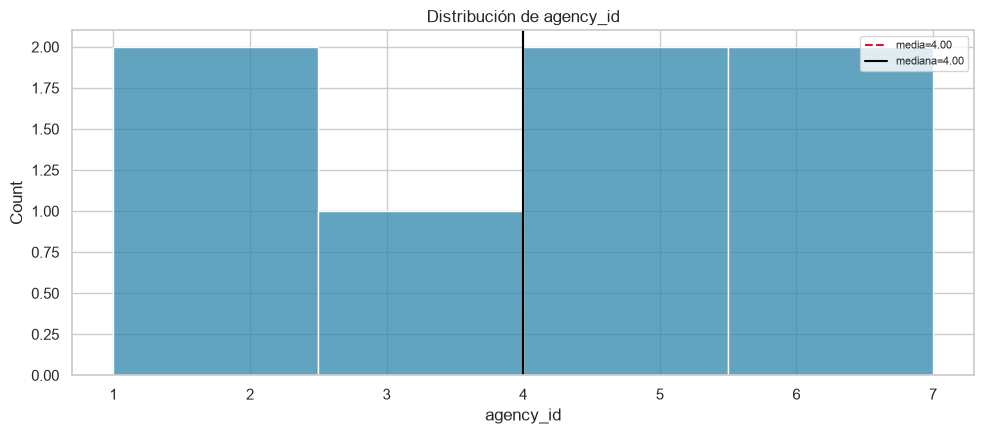

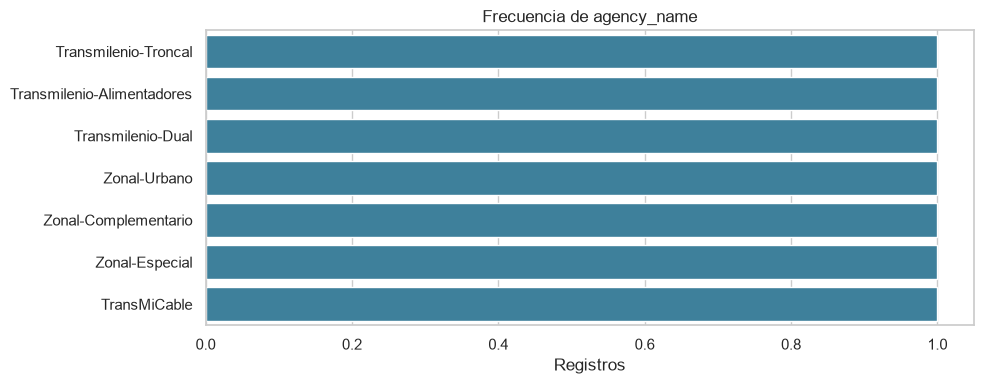

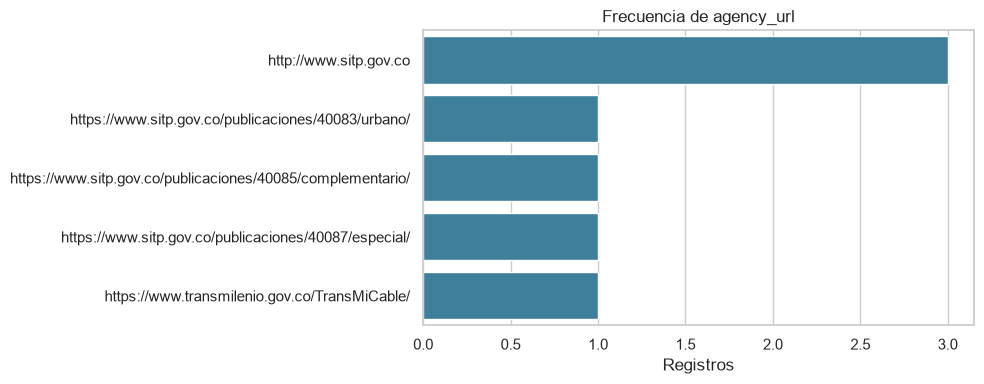

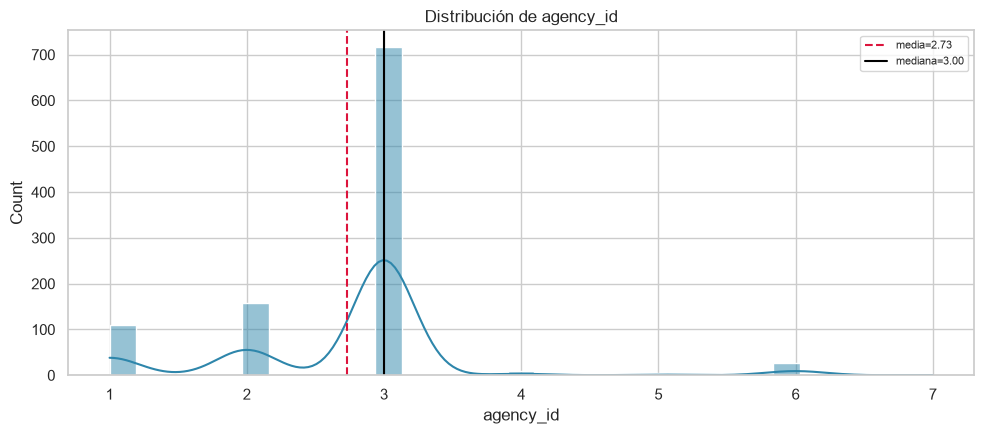

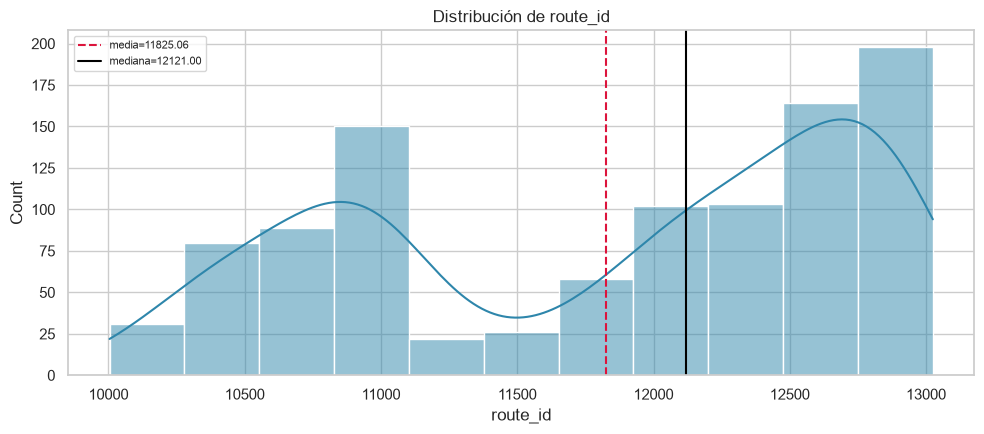

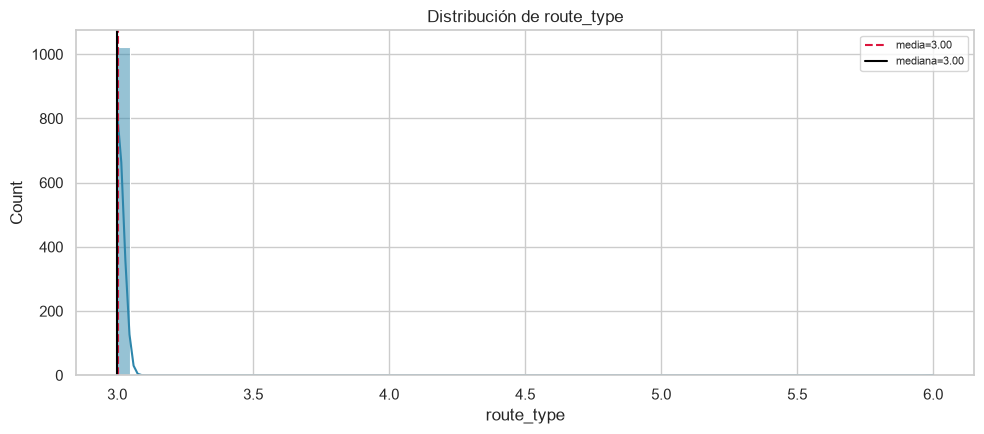

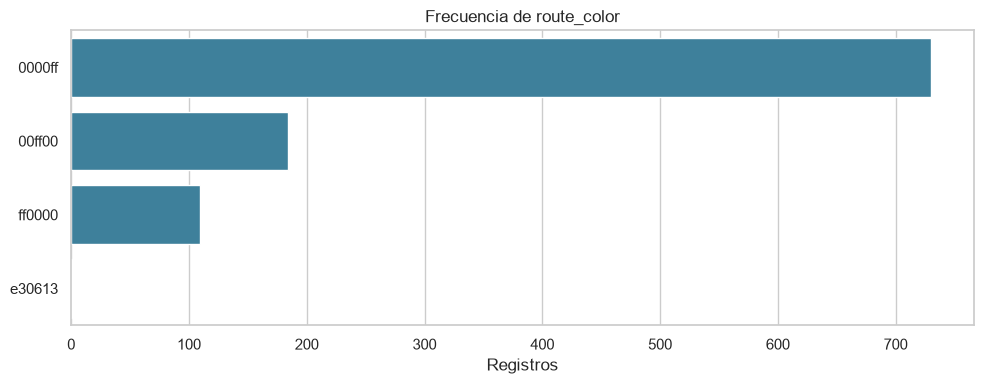

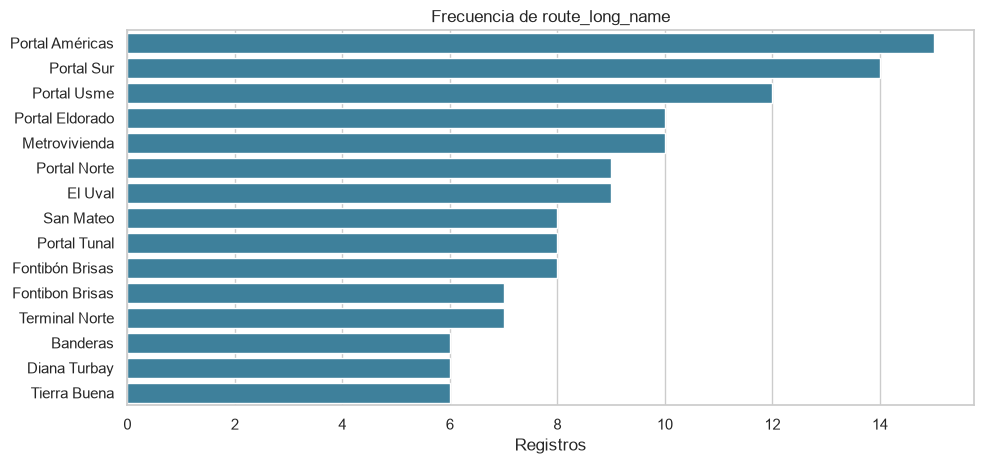

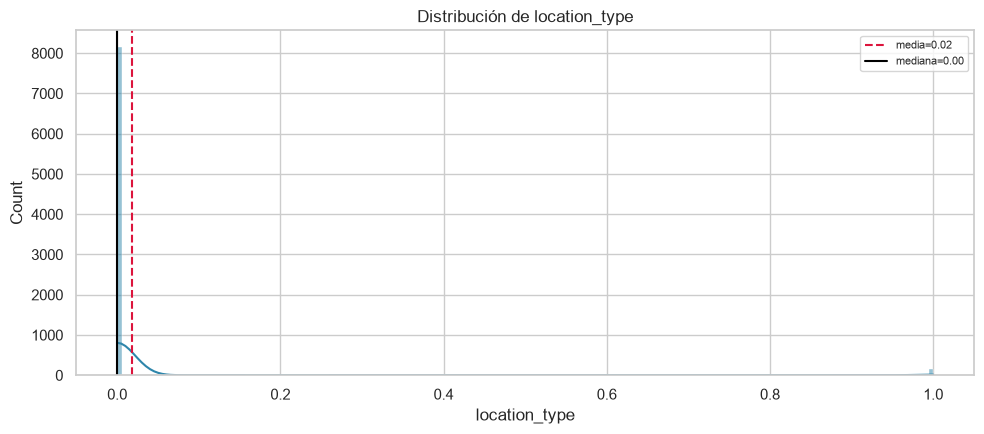

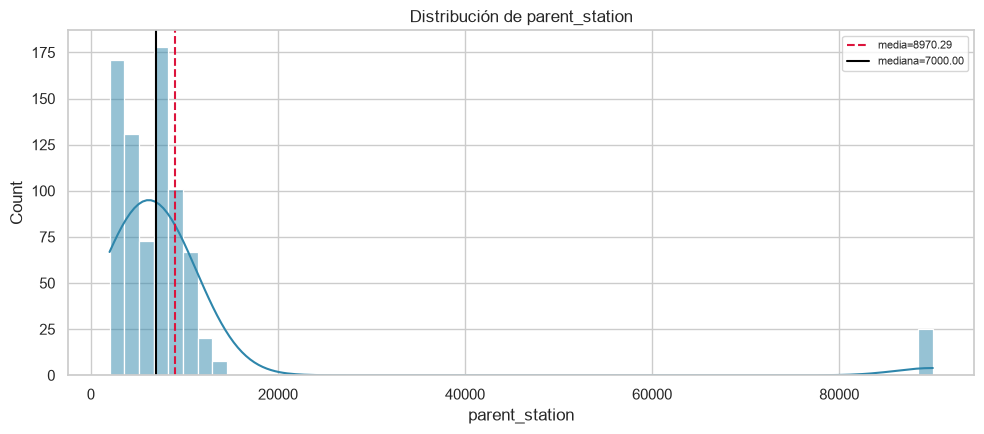

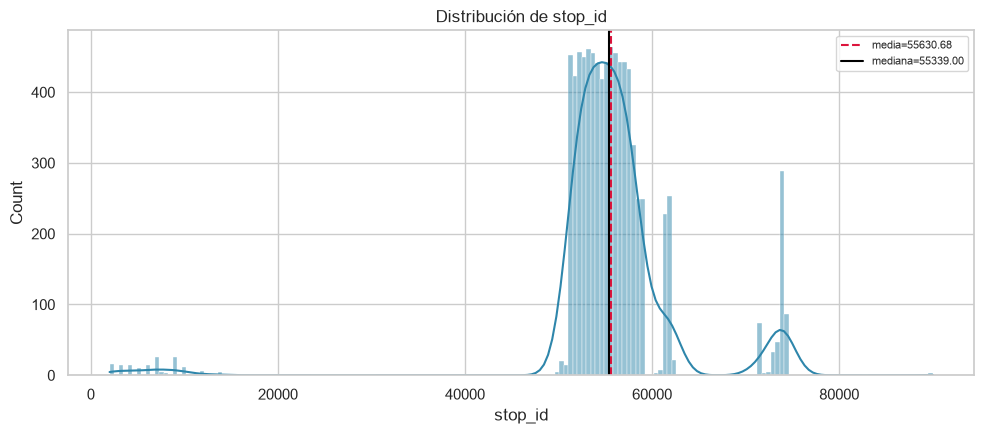

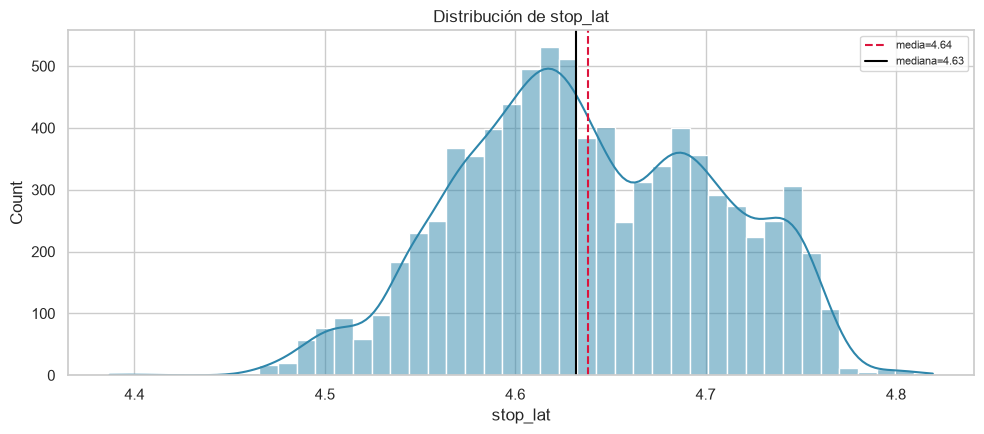

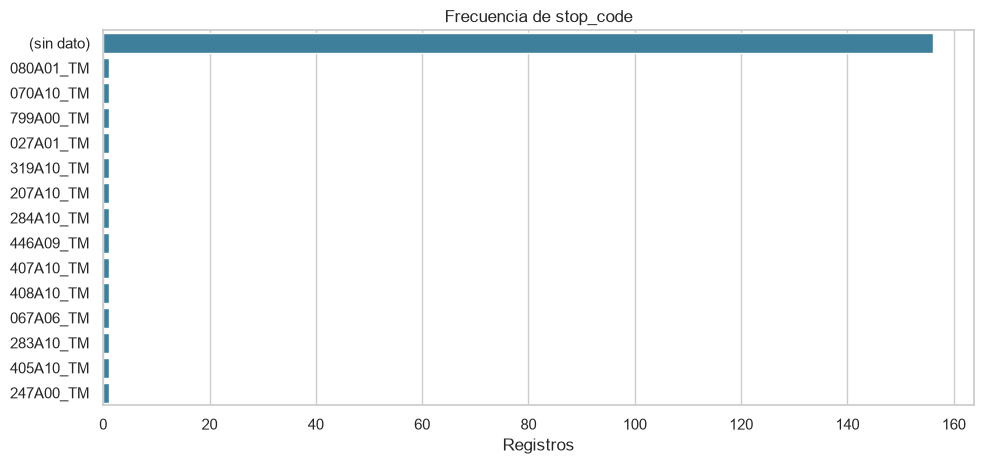

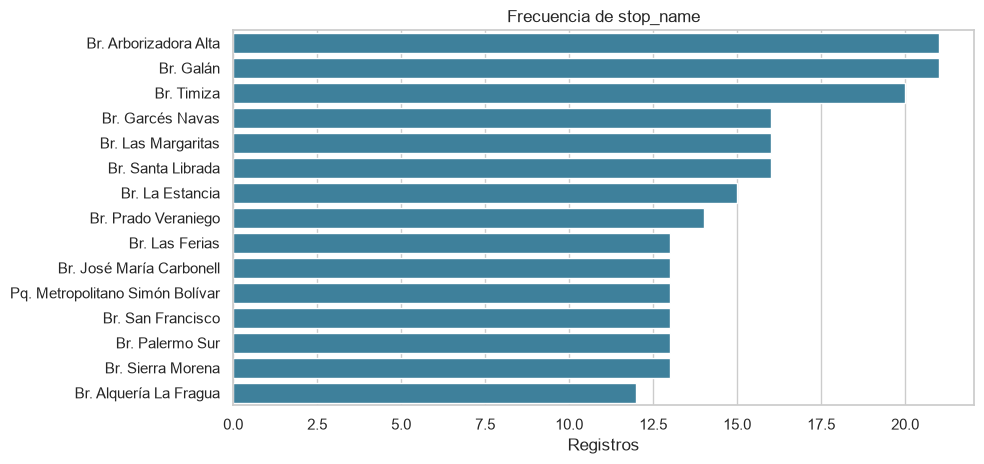

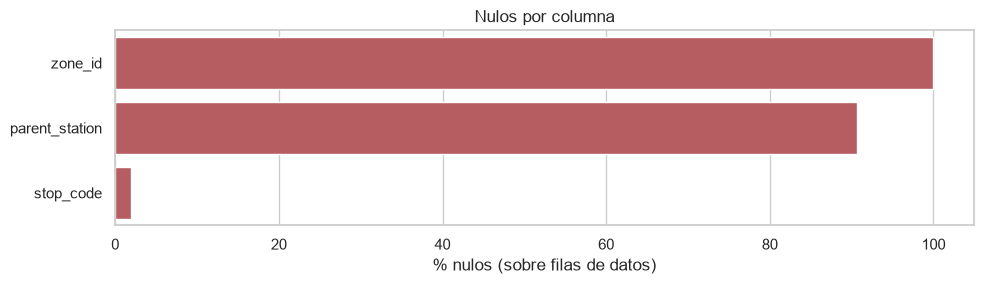

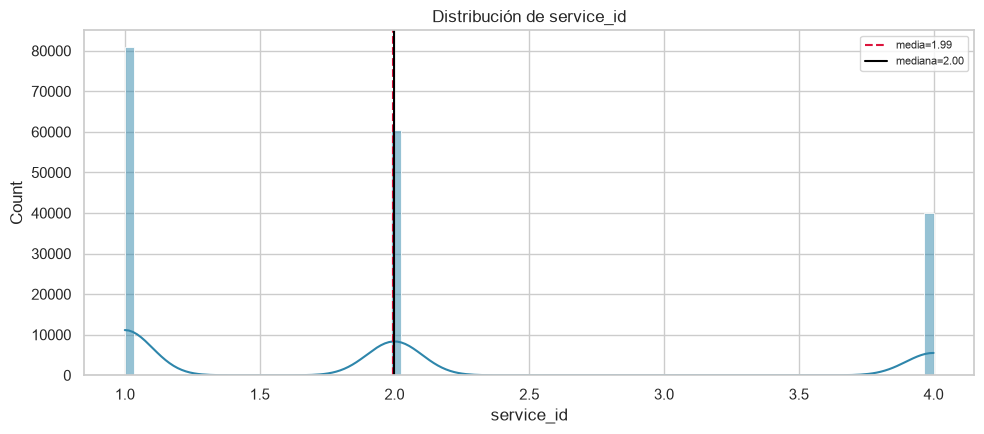

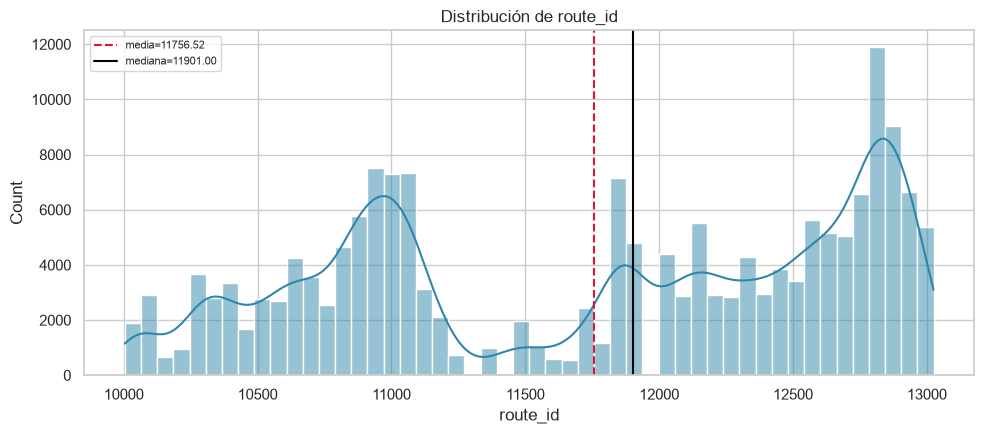

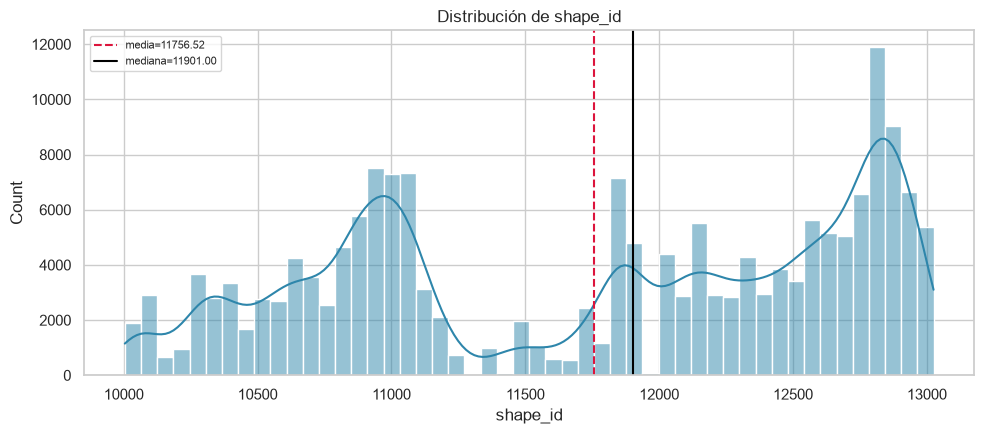

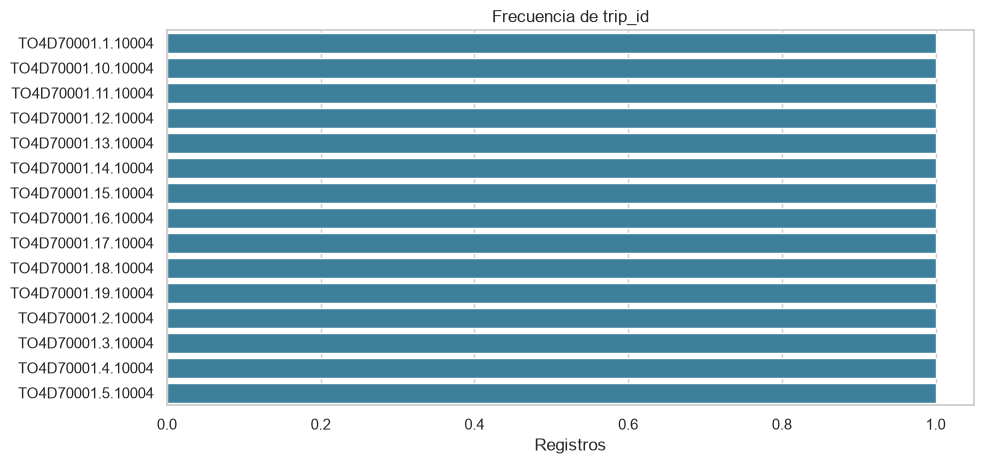

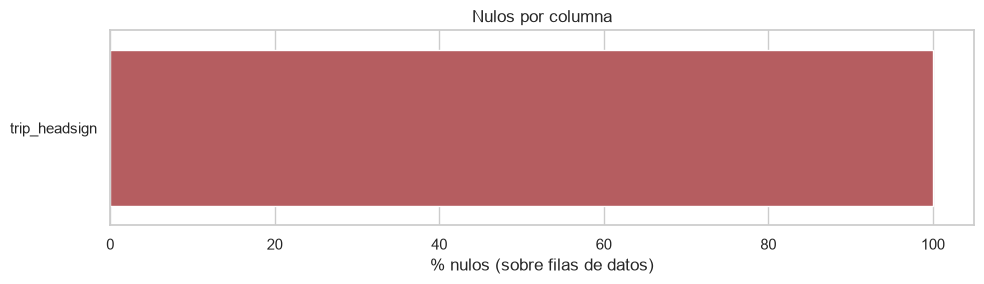

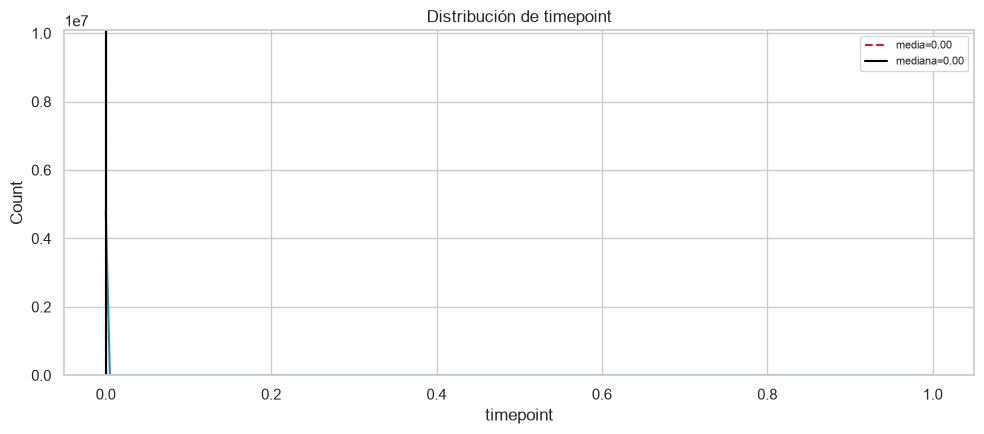

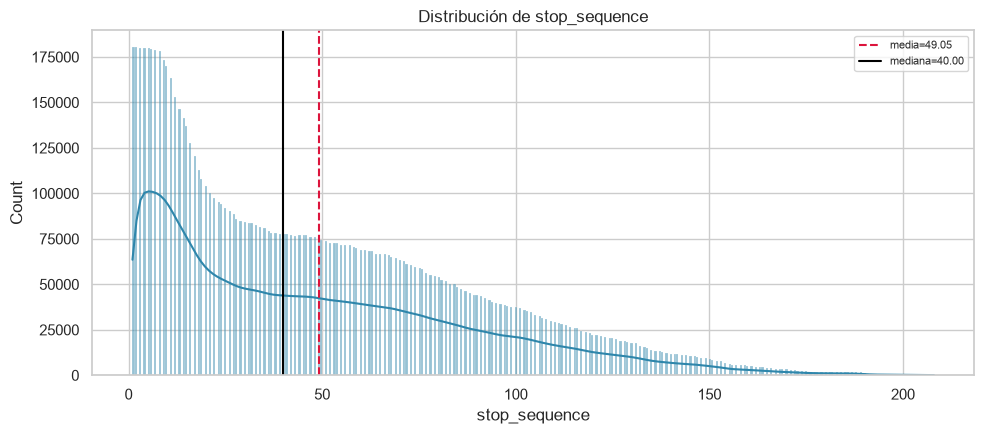

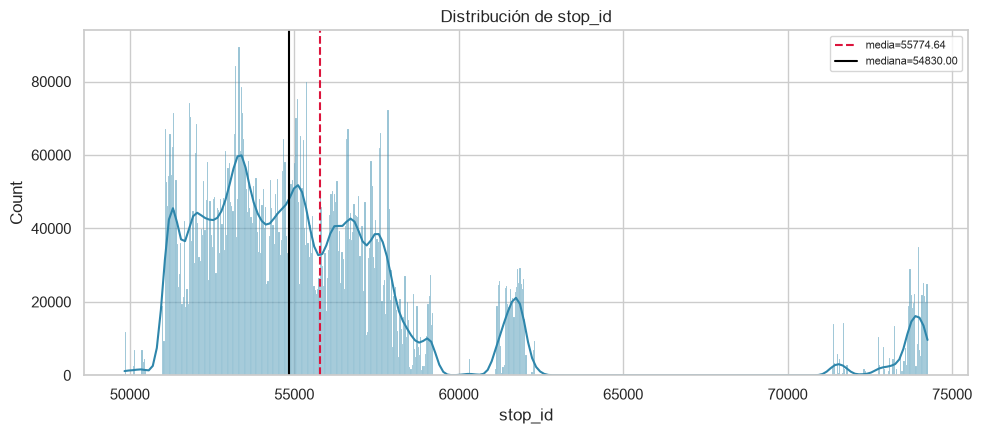

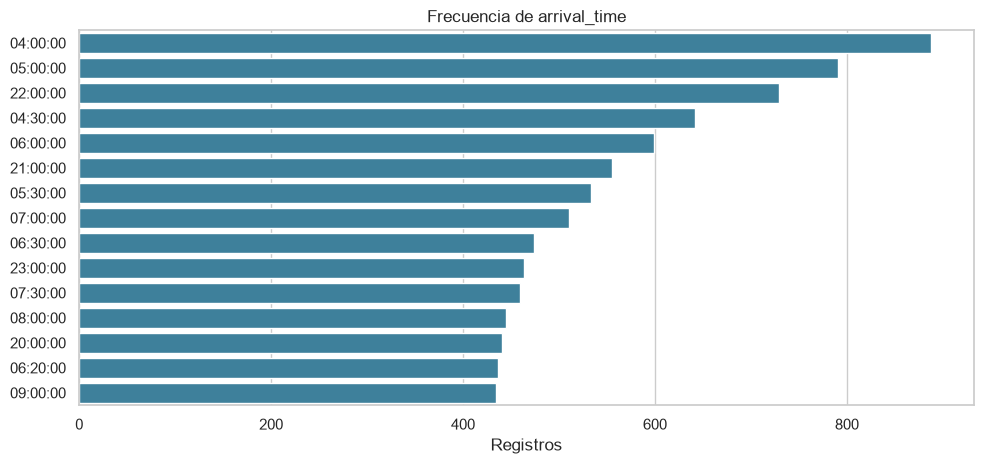

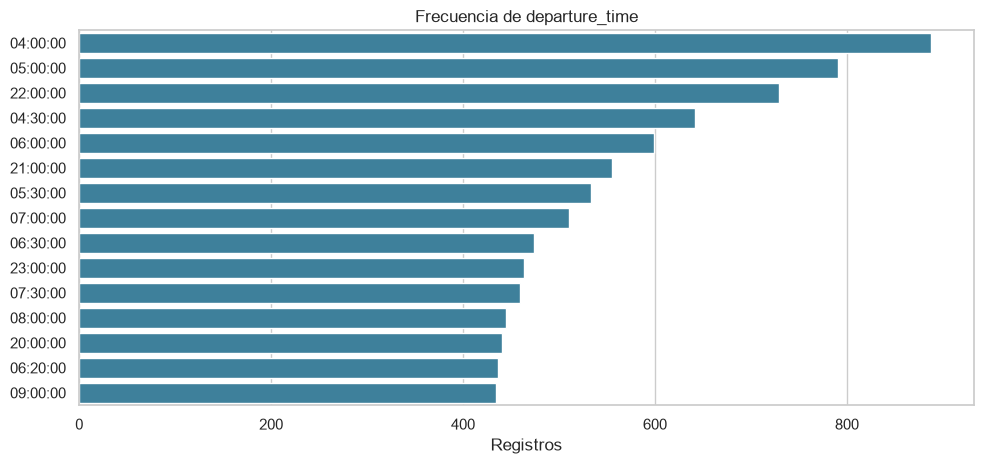

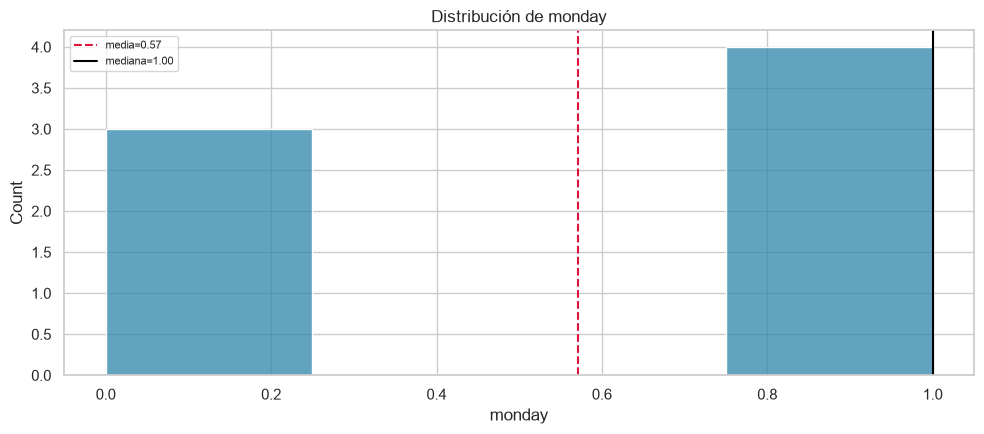

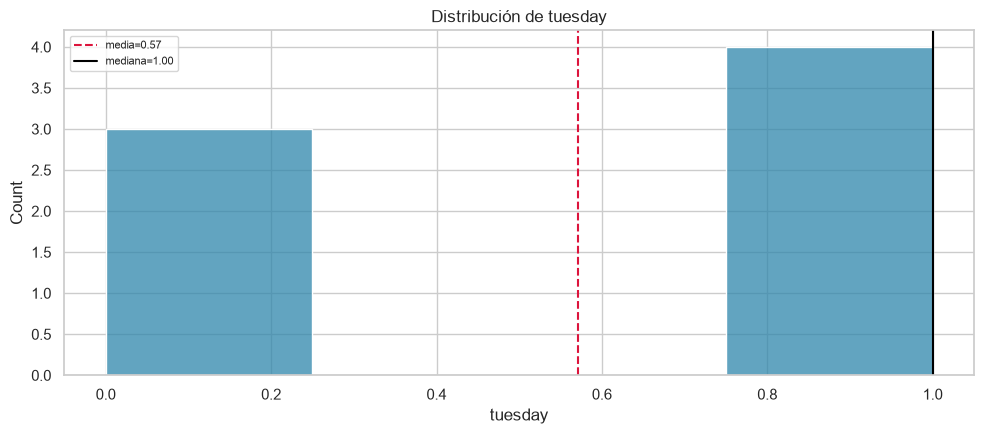

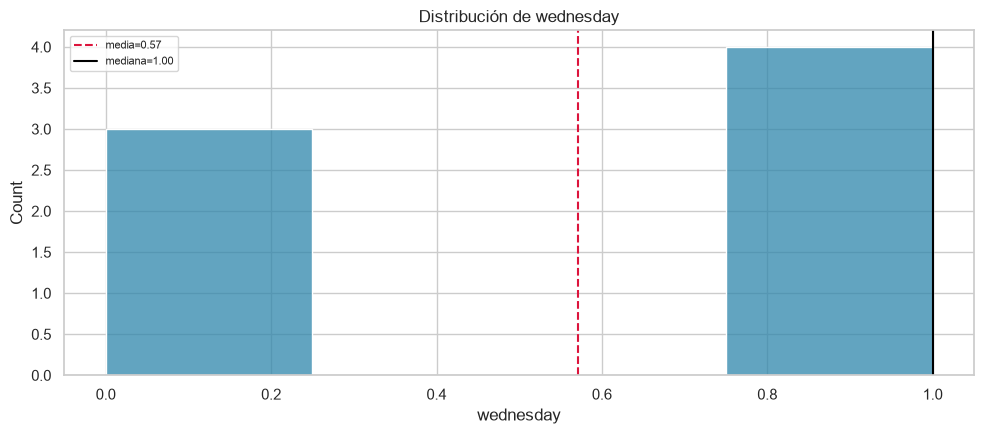

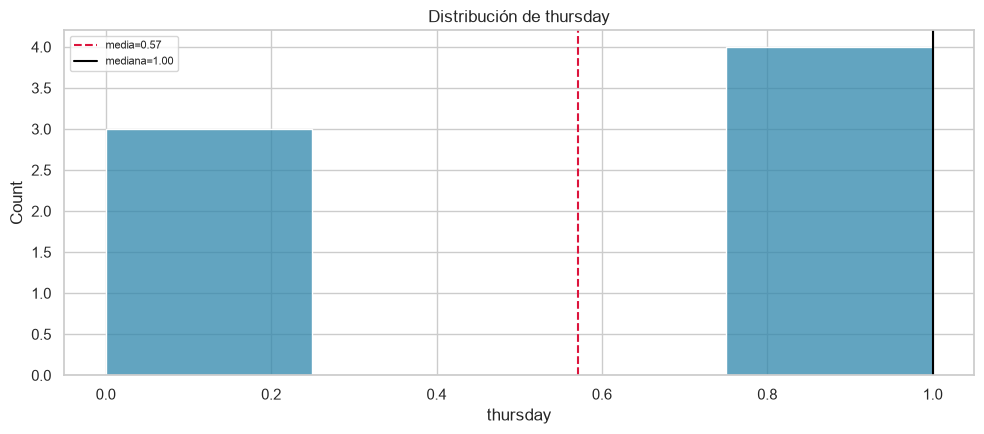

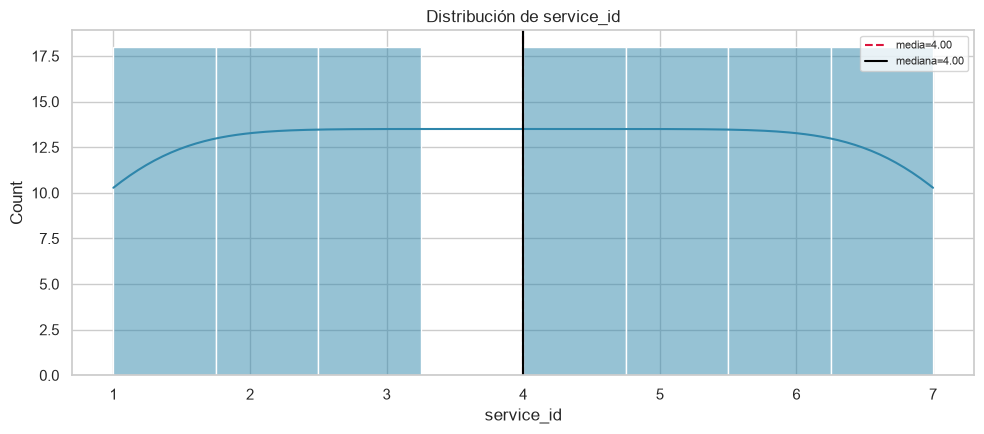

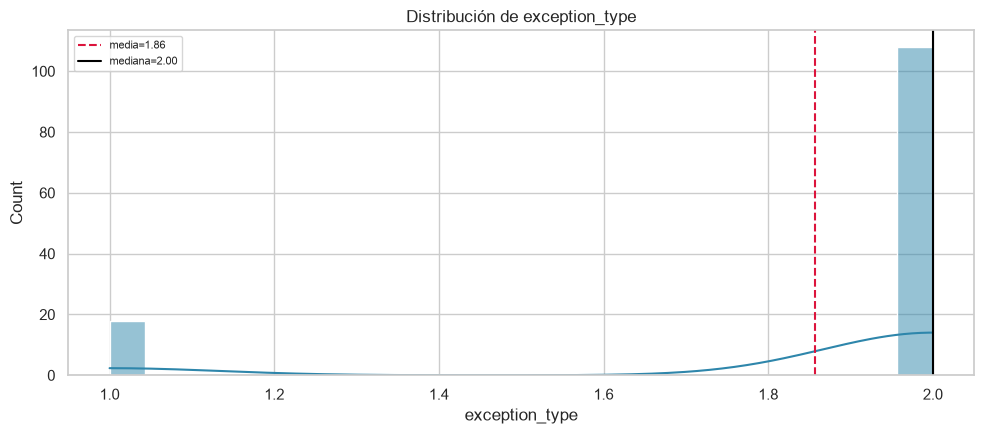

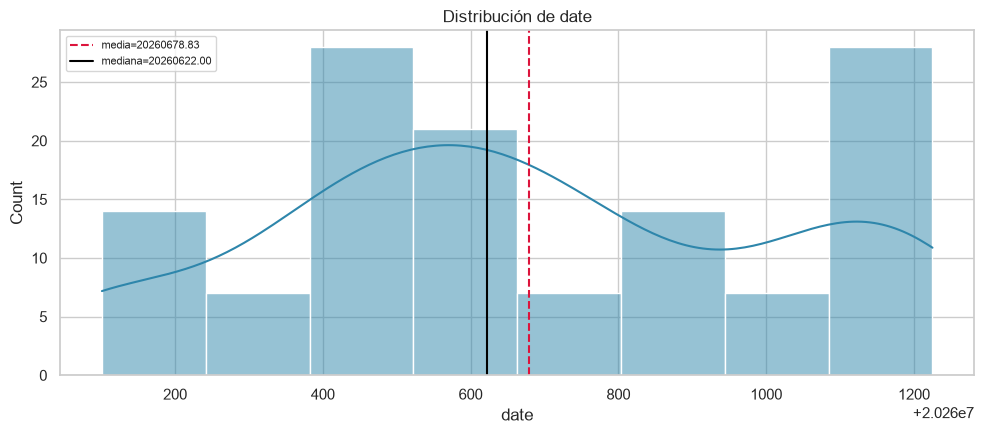

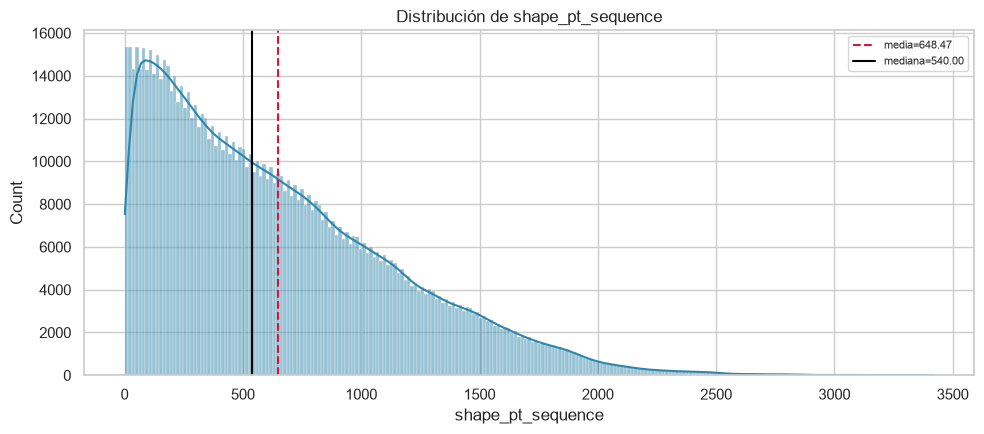

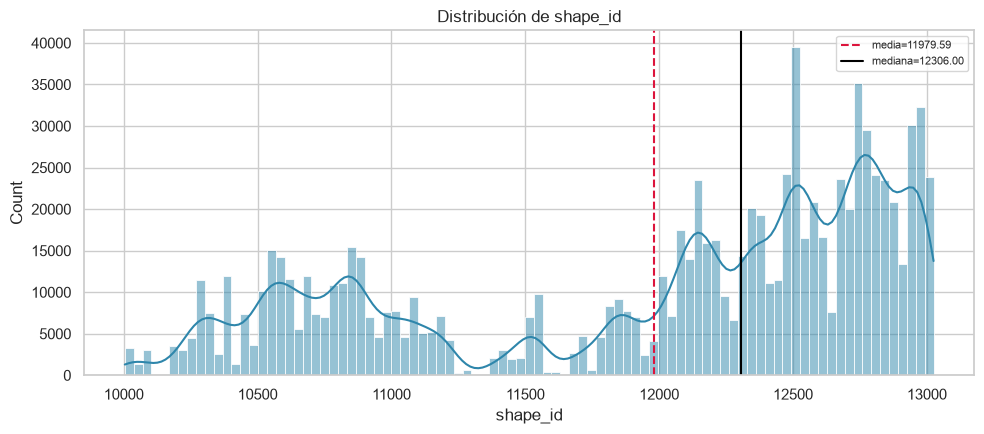

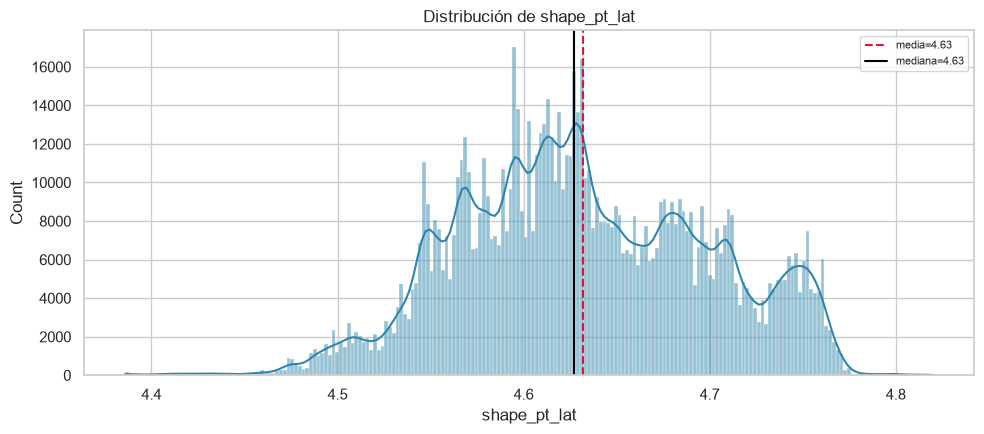

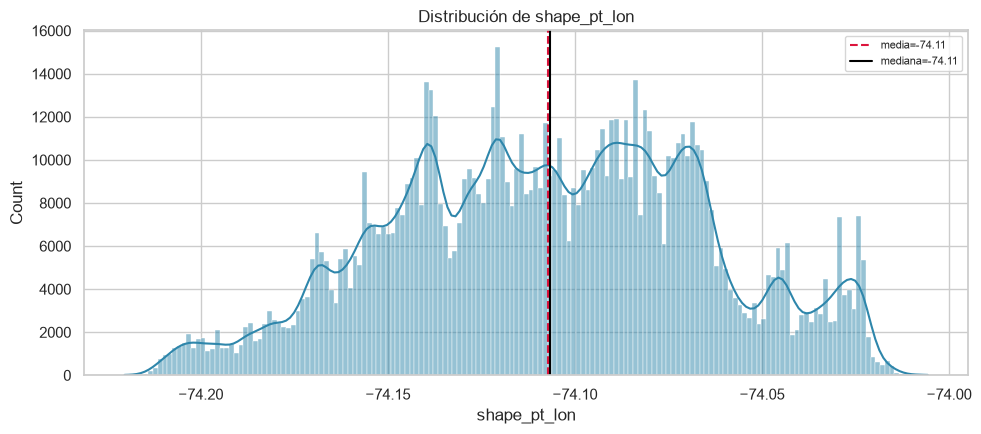

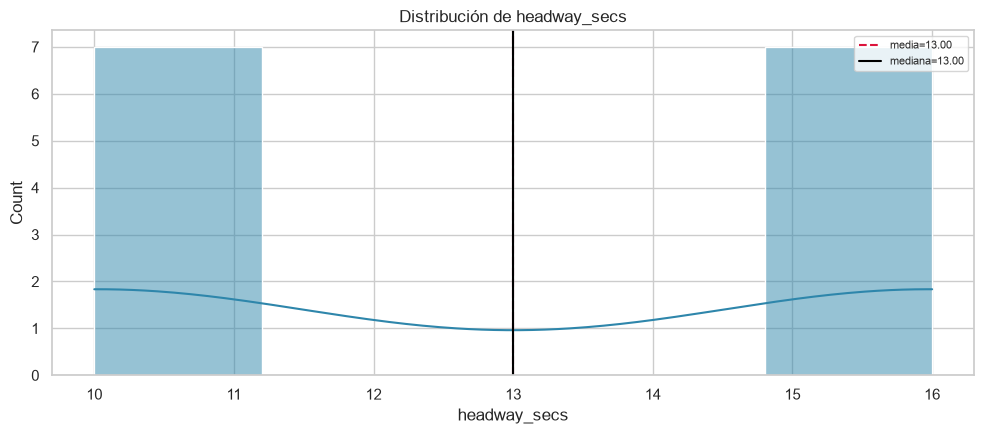

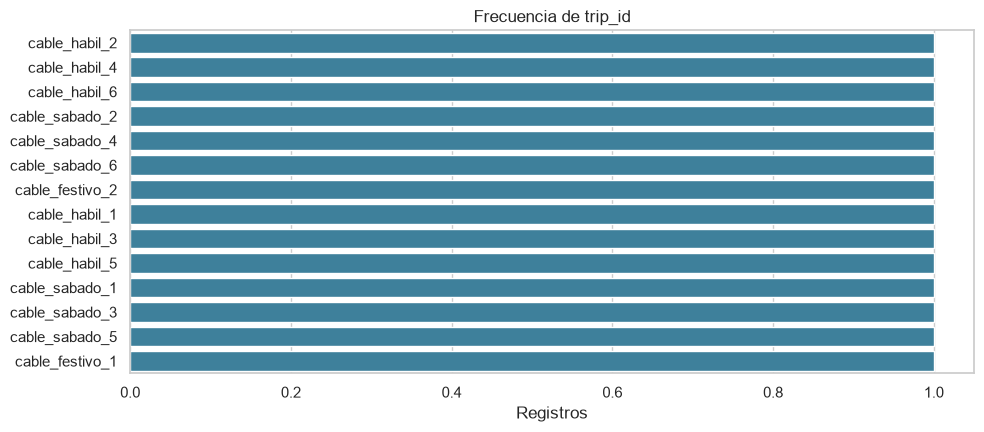

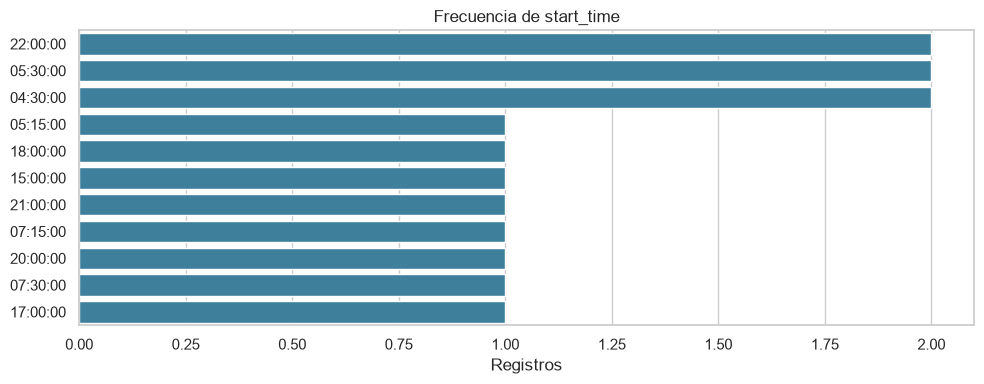

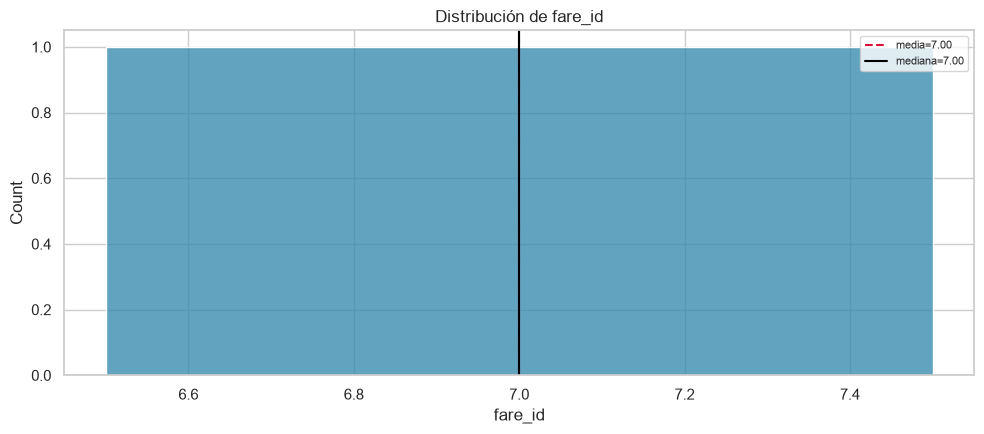

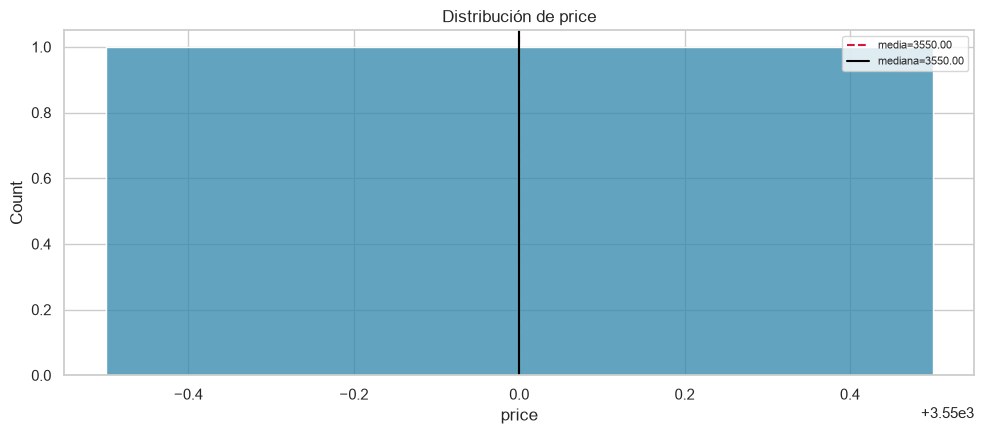

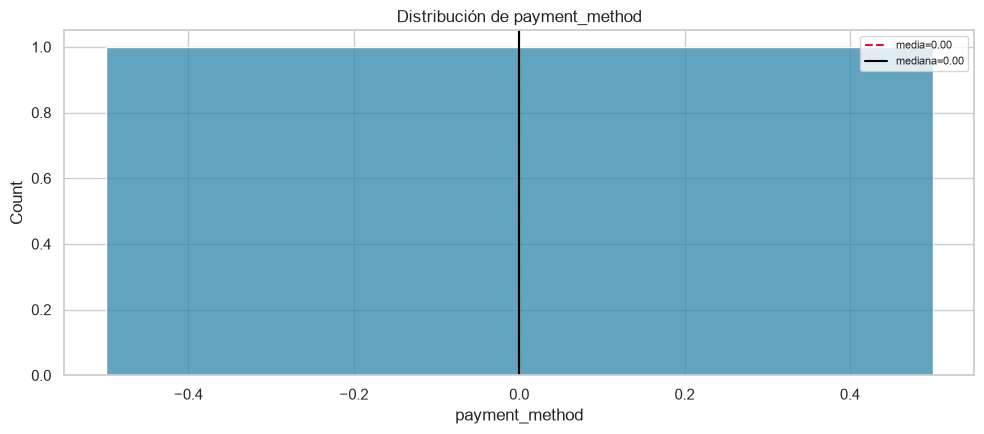

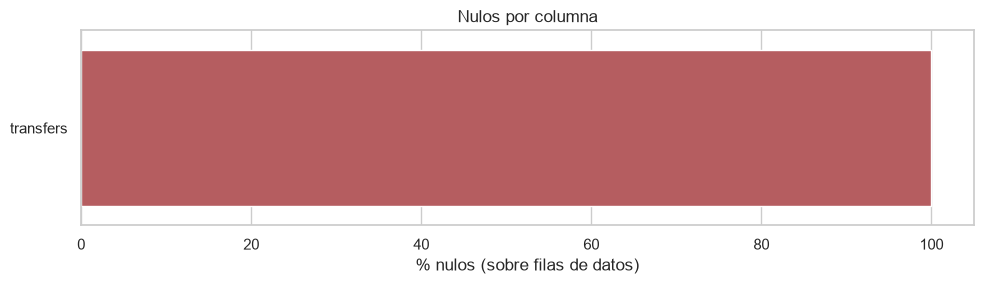

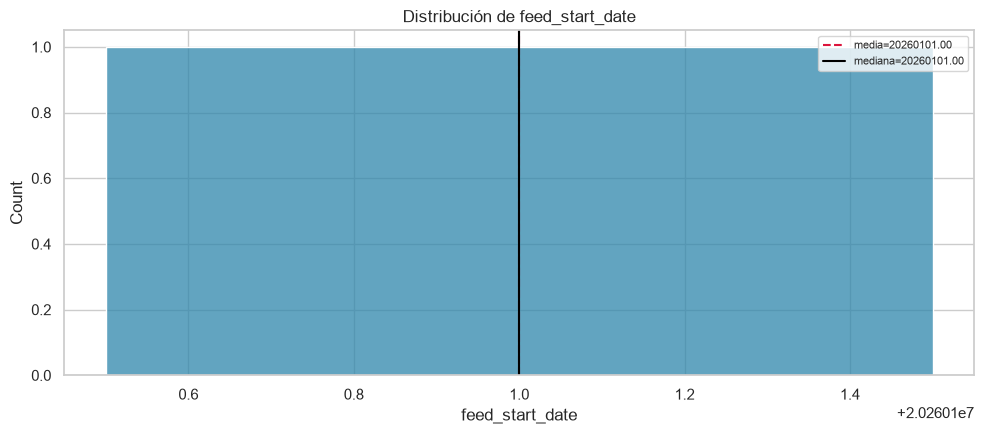

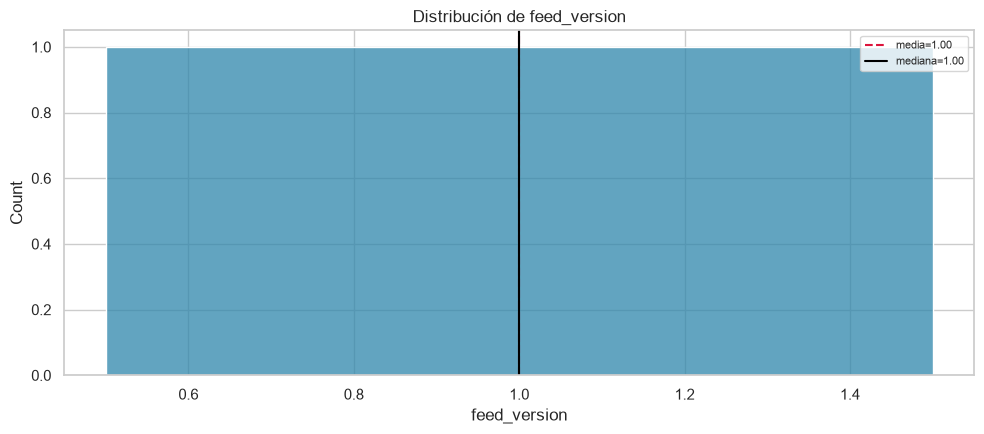

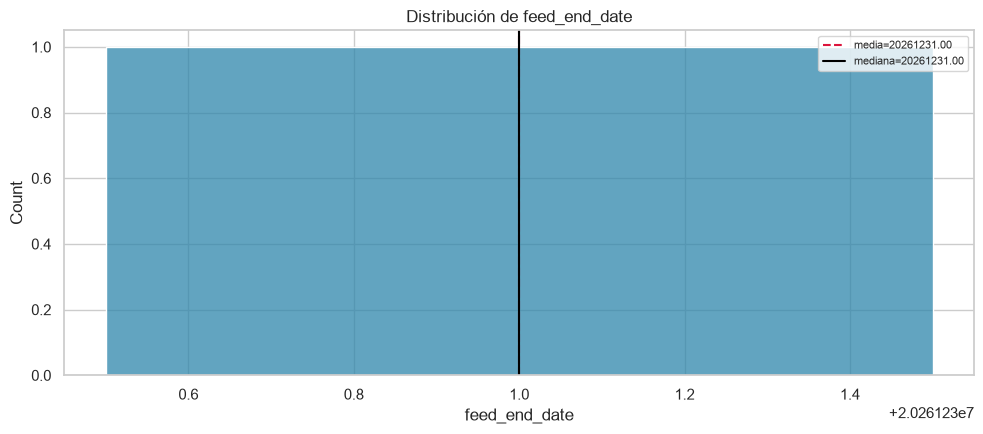

In [14]:
t0('gtfs')
SPEC = {
    'id': 'gtfs_sitp_2026_04',
    'titulo': 'GTFS SITP (11 tablas)',
    'path': 'data/raw/MOVILIDAD/gtfs_sitp_2026-04-29.zip',
    'tipo': 'gtfs',
    'origen': 'TransMilenio S.A. -- GTFS de datos abiertos',
    'corte': '29 abr 2026',
    'valor_publico': 'Operación completa: paradas, rutas, frecuencias, tiempos y shapes',
    'indicadores': 'MOV-01..04 (insumo detallado)',
    'notas': '11 tablas: agency, routes, trips, stop_times, calendar, shapes, frequencies, fare_attributes, stops, calendar_dates, feed_info.',
}
RES = explorar_dataset(SPEC, RAW_DIR, PERFILES, smoke=SMOKE)
t1('gtfs')


## 6. Análisis de la red

### 6.1 Paraderos por localidad

In [ ]:
par = gpd.read_file(str(RAW_DIR / "MOVILIDAD" / "paraderos_zonales_sitp.gpkg"), layer="Paraderos")
tcols = eda.detect_territorial_columns(par)
pcol = tcols[0] if tcols else None
print("columna territorial:", pcol)
pc = par.groupby(pcol).size().sort_values(ascending=False)
pc.to_csv(REPORTS / "movilidad_paraderos_por_localidad.csv", index=False)
display(pc.rename("paraderos"))
print("Total paraderos:", len(par), "| localidades:", pc.notna().sum())
pc.plot(kind="bar", figsize=(11, 4), title="Paraderos SITP por localidad", color="#4c72b0")
plt.ylabel("paraderos")
plt.show()


### 6.2 Mapa de la red SITP

In [ ]:
tr = gpd.read_file(str(RAW_DIR / "MOVILIDAD" / "estaciones_troncales.geojson"))
l1 = gpd.read_file(str(RAW_DIR / "MOVILIDAD" / "estaciones_linea1.geojson"))
l2 = gpd.read_file(str(RAW_DIR / "MOVILIDAD" / "estaciones_linea2.gpkg"), layer="estacionessegundalinea")
zats = gpd.read_file(str(RAW_DIR / "MOVILIDAD" / "zonas_zat.geojson"))
par_muestra = par.sample(min(500, len(par)), random_state=1) if len(par) > 0 else par

fig, ax = plt.subplots(figsize=(10, 10))
try:
    zats.to_crs(4326).plot(ax=ax, color="#f5edd6", edgecolor="#c9b989", alpha=0.6, aspect="auto")
except Exception:
    try:
        zats.plot(ax=ax, color="#f5edd6", edgecolor="#c9b989", alpha=0.6)
    except Exception:
        pass

try:
    if not par_muestra.empty:
        par_muestra.to_crs(4326).plot(ax=ax, color="#9aa5ad", markersize=2, alpha=0.6, label=f"Paraderos (muestra {len(par_muestra)})", aspect="auto")
except Exception:
    pass

try:
    tr.to_crs(4326).plot(ax=ax, color="#d62728", markersize=14, label="Troncales", aspect="auto")
except Exception:
    pass

try:
    l1.to_crs(4326).plot(ax=ax, color="#1f77b4", marker="s", markersize=10, label="Línea 1", aspect="auto")
except Exception:
    pass

try:
    l2.to_crs(4326).plot(ax=ax, color="#2ca02c", marker="D", markersize=10, label="Línea 2", aspect="auto")
except Exception:
    pass

ax.set_title("Red SITP: ZAT, paraderos (muestra), estaciones troncales y líneas 1-2")
try:
    ax.legend(fontsize=8)
except Exception:
    pass
ax.set_axis_off()
plt.close(fig)

### 6.3 Flota SITP

In [ ]:
flota = eda.read_csv_robust(str(RAW_DIR / "MOVILIDAD" / "flota_vinculada_sitp_2024-12.csv"))[0]
flota["edad"] = pd.to_numeric(flota["edad"], errors="coerce")
print("Filas:", len(flota))
flota.groupby("descripcion_tipo").size().sort_values(ascending=False).plot(kind="bar", figsize=(8, 4), title="Flota por tipo de bus", color="#4c72b0")
plt.xticks(rotation=15, ha="right")
plt.ylabel("buses")
plt.show()
flota.groupby("componente").size().plot(kind="bar", figsize=(6, 3), title="Flota por componente", color="#55a868")
plt.show()
flota.groupby("descripcion_nivel_emision").size().sort_values(ascending=False).plot(kind="bar", figsize=(8, 4), title="Flota por nivel de emisión", color="#c44e52")
plt.show()
print("Edad de la flota (años):", flota["edad"].describe().round(1).to_dict())
print("Accesible:", flota["accesible"].value_counts().to_dict())


### 6.4 Servicios y rutas

In [ ]:
rut = eda.read_csv_robust(str(RAW_DIR / "MOVILIDAD" / "servicios_rutas_troncales_zonales.csv"))[0]
rut["long_ruta"] = pd.to_numeric(rut["long_ruta"], errors="coerce")
print("Rutas:", rut["cod_linea"].nunique() if "cod_linea" in rut.columns else rut.shape[0])
rut.groupby("tip_serv").size().sort_values(ascending=False).plot(kind="bar", figsize=(7, 4), title="Rutas por tipo de servicio", color="#4c72b0")
plt.ylabel("rutas")
plt.show()
print("Longitud de ruta (m):", rut["long_ruta"].describe().round(1).to_dict())
if "loc_orig" in rut.columns:
    rut.groupby("loc_orig").size().sort_values(ascending=False).head(10).plot(kind="barh", figsize=(8, 5), title="Top 10 localidades de origen de rutas")
    plt.show()


### 6.5 Validaciones TransMilenio (serie temporal)

In [ ]:
from openpyxl import load_workbook
xlsx_files = sorted((RAW_DIR / "MOVILIDAD" / "Validaciones").glob("*.xlsx"))
print("archivos de validaciones:", len(xlsx_files))
troncal = [p for p in xlsx_files if "Troncal" in p.name]
muestra = troncal[:3] if SMOKE else troncal

partes = []
filas_resumen = []
for p in muestra:
    try:
        wb = load_workbook(p, read_only=True, data_only=True)
        sheet = next((s for s in wb.sheetnames if "tullave" in s.lower()), wb.sheetnames[0])
        df, meta = eda.read_xlsx_sheet(p, sheet, nrows=None if not SMOKE else 300)
        dcols = {c: pd.to_datetime(str(c)).normalize() for c in df.columns if re.match(r"\d{4}-\d{2}-\d{2}", str(c))}
        filas_resumen.append({
            "archivo": p.name,
            "hoja": sheet,
            "filas_datos": len(df),
            "col_fecha": len(dcols),
            "filas_titulo_omitidas": meta.get("filas_titulo_omitidas", 0),
            "cols_unnamed": meta.get("n_unnamed", 0),
        })
        if dcols:
            tmp = df[list(dcols)].apply(pd.to_numeric, errors="coerce").rename(columns=dcols)
            partes.append(tmp)
    except Exception as ex:
        filas_resumen.append({"archivo": p.name, "error": str(ex)[:120]})

resumen_val = pd.DataFrame(filas_resumen)
resumen_val.to_csv(CACHE / "validaciones_resumen.csv", index=False)
display(resumen_val)

if partes:
    serie_diaria = pd.concat(partes).sum().sort_index()
    serie_diaria = serie_diaria[~serie_diaria.index.duplicated()].sort_index()
    serie_diaria.plot(figsize=(12, 4), title="Validaciones TM diarias (troncales, por mes de archivo)")
    plt.ylabel("validaciones")
    plt.show()
    serie_mensual = serie_diaria.resample("ME").sum()
    serie_mensual.plot(marker="o", figsize=(12, 4), title="Validaciones TM mensuales")
    plt.show()
    print("Total validaciones:", f"{serie_diaria.sum():,.0f}")
    print("Pico diario:", serie_diaria.idxmax().date(), f"{serie_diaria.max():,.0f}")


## 7. Indicadores del sector

In [ ]:
sts = eda.indicator_status()
sts_sec = sts[sts["indicador"].str.startswith("MOV", na=False)]
display(sts_sec[["indicador", "dimension", "estado", "que_falta"]])
sts_sec.to_csv(REPORTS / "indicadores_movilidad.csv", index=False)
guardar_tiempos("04_eda_movilidad.csv")
print("Secciones del notebook:", list(_SECTION_T.keys()))
